# Machine Learning sobre el corpus desclasificado del 23F

Este notebook constituye el bloque empírico del Trabajo Fin de Máster sobre el golpe de Estado del 23 de febrero de 1981. Reúne **cuatro casos de uso independientes pero complementarios** que aplican técnicas de aprendizaje automático y análisis de datos sobre el corpus de 167 documentos desclasificados procedentes de los Ministerios de Defensa, Interior y Exteriores. Cada caso responde a una pregunta de investigación distinta sobre el acontecimiento y emplea una familia metodológica diferente —análisis de redes, clasificación supervisada, topic modeling no supervisado y series temporales—, de modo que el conjunto ofrece una visión multidisciplinar del mismo material documental.

## Propósito

El propósito común de los cuatro casos es **demostrar el valor analítico de aplicar técnicas cuantitativas a un corpus documental histórico** que tradicionalmente se ha estudiado de forma cualitativa. Cada caso parte de una hipótesis interpretable, aplica un pipeline metodológico justificado y valida sus resultados contra una referencia externa siempre que es posible (la sentencia firme del Tribunal Supremo, la cronología oficial del 23F, o la coherencia interna del corpus).

## Organización del notebook

El notebook está estructurado en **cuatro casos numerados** ejecutables de forma secuencial. Cada caso es autocontenido en su lógica de análisis pero comparte el mismo dataset y la sección común de configuración inicial. Los casos están separados visualmente por líneas horizontales de guiones.

### Sección común — Configuración inicial *(celdas 1 a 7)*

Instalación de dependencias, imports, semilla de reproducibilidad y carga del dataset. Esta sección debe ejecutarse antes que cualquier caso; los demás bloques asumen que las variables aquí definidas están en memoria.

### Caso 1 — Análisis de la red de comunicaciones *(celdas 8 a 51)*

Reconstrucción de la red de actores a partir de sus coapariciones en los documentos, complementada con una red de interacciones dirigidas extraída mediante verbos comunicativos. Aplica detección de comunidades con Louvain, métricas de centralidad (grado, intermediación, cercanía, PageRank), análisis institucional por ministerio y validación externa contra la sentencia del Tribunal Supremo de 1983. Incluye bootstrap de robustez para evaluar la estabilidad de los rankings.

### Caso 2 — Ambigüedad en la posición de cada actor *(celdas 53 a 92)*

Clasificador supervisado (regresión logística calibrada) que aprende a distinguir documentos del bando golpista frente a documentos del bando constitucionalista a partir de un conjunto semilla etiquetado manualmente, y luego propaga la predicción al resto del corpus. La aplicación final consiste en un *termómetro* por actor que mide su grado de alineamiento durante las fases activas del golpe, con análisis explícito de la zona gris y los falsos positivos.

### Caso 3 — Clasificador semántico del dataset 23F *(celdas 94 a 124)*

Pipeline en dos fases. Primero, una fase no supervisada de *topic modeling* con NMF deriva diez temas semánticos del corpus, que se renombran manualmente a categorías interpretables. Segundo, una fase supervisada (regresión logística, SVM y random forest, validados con 5-fold cross-validation) entrena un clasificador multiclase capaz de asignar a cualquier documento futuro su categoría semántica. Se cierra con un análisis de errores basado en la matriz de confusión y un perfil léxico discriminante por categoría.

### Caso 4 — Cronología algorítmica de la noche del 23F *(celdas 126 a 147)*

Reconstrucción cuantitativa de la secuencia temporal de eventos durante la noche del golpe a partir de un dataset complementario (`Eventos_Noche23F.csv`). Aplica análisis de densidad temporal con ventana móvil, detección de anomalías con Isolation Forest sobre los picos de actividad, comparación con la cronología oficial documentada y visualización tipo Gantt actor por actor. La salida es un dataset enriquecido de eventos que sirve de base para análisis posteriores.

## Cómo ejecutar el notebook

El notebook está diseñado para ejecutarse **de principio a fin sin intervención manual**. Los requisitos previos son:

1. **Dataset principal**: el archivo `Dataset_23F.csv` debe estar accesible. El sistema de localización automática lo busca en las rutas habituales del usuario (directorio del notebook, Descargas, Escritorio, Documentos, OneDrive). Si no aparece, lanza una búsqueda exhaustiva por el sistema de archivos y, como último recurso, abre un selector gráfico.

2. **Dataset complementario** *(solo Caso 4)*: el archivo `Eventos_Noche23F.csv` debe estar en una ubicación similar. Si no se encuentra, los casos 1 a 3 se ejecutan con normalidad y el Caso 4 lanza un mensaje informativo.

3. **Dependencias**: la celda 3 instala automáticamente todas las librerías necesarias (`pandas`, `numpy`, `networkx`, `scikit-learn`, `matplotlib`, `seaborn`, `spacy`, `python-louvain`, entre otras) mediante `%pip install`. En la primera ejecución, esta celda puede tardar varios minutos. Tras la instalación es recomendable reiniciar el kernel una vez para garantizar que los nuevos paquetes se importan correctamente.

4. **Reproducibilidad**: todos los componentes estocásticos (semillas de scikit-learn, NumPy y los muestreos de bootstrap) están fijados con `RANDOM_SEED = 42`, de modo que ejecuciones sucesivas del notebook producen resultados idénticos.

## Notas sobre el corpus

El dataset principal contiene 167 documentos enriquecidos con metadatos administrativos (ministerio, sección, nivel de clasificación), temporales (fecha, año, fase histórica), de contenido (texto OCR completo, resumen, palabras clave) y derivados del procesamiento previo (métricas lingüísticas, densidades temáticas, entidades canónicas resueltas). La descripción detallada del dataset y de su proceso de construcción se encuentra en el documento de planteamiento que acompaña al notebook.


---

## Sección común — Configuración inicial

Las siguientes celdas instalan dependencias, fijan la semilla aleatoria y cargan el dataset principal. Ejecútalas siempre antes de los casos.

## 0. Instalación de dependencias

Ejecuta esta celda **una sola vez**. Después reinicia el kernel.

In [ ]:
%pip install pandas numpy networkx matplotlib seaborn python-louvain pyvis scipy

## 1. Configuración e imports

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import re
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# === LOCALIZACIÓN AUTOMÁTICA DE ARCHIVOS ===
import os
from pathlib import Path

# Único nombre aceptado para el dataset principal — evita ambigüedades
# si en el sistema coexisten varias versiones del corpus.
DATASET_FILENAMES = ['Dataset_23F.csv']
EVENTOS_FILENAMES = [
    'Eventos_Noche23F.csv', 'eventos_noche23f.csv',
    'Eventos_noche23F.csv', 'EventosNoche23F.csv',
]

_RUTAS_HABITUALES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / 'Downloads',
    Path.home() / 'Descargas',
    Path.home() / 'Desktop',
    Path.home() / 'Escritorio',
    Path.home() / 'OneDrive' / 'Escritorio',
    Path.home() / 'OneDrive' / 'Desktop',
    Path.home() / 'Documents',
    Path.home() / 'Documentos',
]

def _busqueda_rapida(filenames):
    for ruta in _RUTAS_HABITUALES:
        if not ruta.exists():
            continue
        for nombre in filenames:
            c = ruta / nombre
            if c.is_file():
                return str(c)
    return None

def _busqueda_exhaustiva(filenames):
    print('  Buscando en todo el sistema (puede tardar)...')
    raices = [Path.home()]
    if os.name == 'nt':
        for letra in 'CDEFGHIJ':
            d = Path(f'{letra}:/')
            if d.exists():
                raices.append(d)
    omit = {'node_modules', '.git', 'venv', '.venv', 'env', '__pycache__',
             'AppData', 'Library', '.cache', 'Trash', '$Recycle.Bin',
             'Windows', 'Program Files', 'Program Files (x86)', 'ProgramData'}
    for raiz in raices:
        if not raiz.exists():
            continue
        try:
            for dirpath, dirnames, found_files in os.walk(raiz):
                dirnames[:] = [d for d in dirnames
                                if d not in omit and not d.startswith('.')]
                for nombre in filenames:
                    if nombre in found_files:
                        return str(Path(dirpath) / nombre)
        except (PermissionError, OSError):
            continue
    return None

def _busqueda_grafica(filenames):
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        path = filedialog.askopenfilename(
            title=f'Selecciona: {" / ".join(filenames)}',
            filetypes=[('CSV', '*.csv'), ('Todos', '*.*')]
        )
        root.destroy()
        return path if path else None
    except Exception as e:
        print(f'  No se pudo abrir el selector gráfico: {e}')
        return None

def localizar_archivo(filenames, label, obligatorio=True):
    print(f'Localizando {label}...')
    path = _busqueda_rapida(filenames)
    if path is None:
        print('  No encontrado en rutas habituales.')
        path = _busqueda_exhaustiva(filenames)
    if path is None:
        print('  No encontrado. Abriendo selector...')
        path = _busqueda_grafica(filenames)
    if not path:
        msg = (
            f'\n\n\u274c No se pudo localizar {label}.\n'
            f'   Nombres aceptados: {filenames}\n'
            f'   Coloca el archivo en la misma carpeta que este notebook.\n'
        )
        if obligatorio:
            raise FileNotFoundError(msg)
        print(f'\u26a0\ufe0f  {label} no encontrado. El Caso 4 no podrá ejecutarse.')
        return None
    print(f'\u2713 {label}: {path}')
    return path

# Dataset principal — obligatorio para los 4 casos
DATASET_PATH = localizar_archivo(DATASET_FILENAMES, 'Dataset 23F')
# Eventos de la noche — solo necesario para el Caso 4
EVENTOS_PATH = localizar_archivo(EVENTOS_FILENAMES, 'Eventos Noche 23F', obligatorio=False)


Localizando dataset...
  No encontrado en rutas habituales.
  Buscando en todo el sistema (puede tardar)...
  No encontrado en búsqueda exhaustiva. Abriendo selector...
  No se pudo abrir el selector gráfico: no display name and no $DISPLAY environment variable
✓ Dataset cargado desde: Dataset_23F.csv


## 2. Carga del corpus enriquecido

In [ ]:
df = pd.read_csv(DATASET_PATH)
print(f'Total documentos: {len(df)}')

print(f'\n=== Distribución por fase ===')
print(df['fase'].value_counts().sort_index())

print(f'\n=== Distribución por ministerio ===')
print(df['ministerio'].value_counts())

print(f'\n=== Distribución por clasificación ===')
print(df['clasificacion'].value_counts())

Total documentos: 292

=== Distribución por fase ===
fase
 el del Tercio                                                                           1
 se dirigen a sus compañeros de las Comisiones Militares que asisten a la vista oral     1
1_pre_golpe                                                                             10
2_noche_golpe                                                                           22
3_dias_inmediatos                                                                       17
4_instruccion                                                                           48
5_juicio_oral                                                                           85
6_post_sentencia                                                                         7
Name: count, dtype: int64

=== Distribución por ministerio ===
ministerio
Defensa                                                                                                                                     

---

# Caso 1 — Análisis de la red de comunicaciones del 23F

Reconstrucción de la estructura relacional del corpus mediante análisis de redes. Combina una red de coaparición no dirigida con una red de interacciones dirigidas y valida los resultados contra la sentencia firme del Tribunal Supremo.

## 3. Parseo del campo `entidades`

In [ ]:
def parse_entities(s):
    if pd.isna(s):
        return {}
    try:
        return json.loads(s)
    except (json.JSONDecodeError, TypeError):
        return {}

df['entidades_dict'] = df['entidades'].apply(parse_entities)

all_entities = Counter()
for d in df['entidades_dict']:
    for ent, count in d.items():
        all_entities[ent] += count

print(f'Entidades canónicas únicas en el corpus: {len(all_entities)}')
print(f'Total menciones: {sum(all_entities.values())}')
print(f'\nTop 20 entidades:')
for ent, count in all_entities.most_common(20):
    print(f'  {count:5d}  {ent}')

Entidades canónicas únicas en el corpus: 30
Total menciones: 7536

Top 20 entidades:
   1422  Antonio Tejero
   1301  Alfonso Armada
   1076  Congreso de los Diputados
    881  Jaime Milans del Bosch
    743  Guardia Civil
    387  Juan Carlos I
    360  José Luis Cortina
    231  Consejo Supremo de Justicia Militar
    203  CESID
    168  Luis Torres Rojas
    118  Juan García Carrés
     98  JUJEM
     76  Casa Real / Zarzuela
     60  Cafetería Galaxia
     57  Felipe González
     57  Manuel Gutiérrez Mellado
     51  AOME
     41  Leopoldo Calvo-Sotelo
     26  Santiago Carrillo
     26  Alexander Haig


In [ ]:
# Heurística para distinguir personas de instituciones
INSTITUTIONAL_KEYWORDS = [
    'Congreso', 'Guardia Civil', 'CESID', 'JUJEM', 'Consejo Supremo',
    'AOME', 'Casa Real', 'Zarzuela', 'RTVE', 'Prado del Rey', 'Brunete',
    'Cafetería Galaxia', 'Capitanía', 'Fuerza Nueva'
]

def is_institution(name):
    return any(kw in name for kw in INSTITUTIONAL_KEYWORDS)

# Documentos en los que aparece cada entidad (para filtros posteriores)
docs_per_entity = defaultdict(int)
for _, row in df.iterrows():
    for ent in row['entidades_dict']:
        docs_per_entity[ent] += 1

print('Presencia de entidades en documentos:')
for ent, n in sorted(docs_per_entity.items(), key=lambda x: -x[1])[:20]:
    print(f'  {n:3d} docs  {ent}')

Presencia de entidades en documentos:
  103 docs  Congreso de los Diputados
   92 docs  Guardia Civil
   90 docs  Alfonso Armada
   89 docs  Consejo Supremo de Justicia Militar
   86 docs  Antonio Tejero
   83 docs  Juan Carlos I
   63 docs  Jaime Milans del Bosch
   54 docs  CESID
   53 docs  José Luis Cortina
   35 docs  Luis Torres Rojas
   33 docs  JUJEM
   33 docs  Casa Real / Zarzuela
   25 docs  Juan García Carrés
   20 docs  Felipe González
   20 docs  Cafetería Galaxia
   19 docs  Manuel Gutiérrez Mellado
   16 docs  Leopoldo Calvo-Sotelo
   11 docs  RTVE / Prado del Rey
   11 docs  Sánchez Valiente
   10 docs  División Acorazada Brunete


## 4. Construcción de la red de co-aparición

Dos entidades quedan conectadas si aparecen juntas en un mismo documento.

### Decisión metodológica

El análisis principal se realiza sobre la **subred de personas** (excluyendo
entidades institucionales como CESID, JUJEM, Casa Real, Consejo Supremo, etc.).
Esto responde a la pregunta de investigación, centrada en la **influencia personal**
y los **flujos de comunicación entre individuos** durante el 23F.

Las instituciones se reservan para el **análisis institucional complementario**
(sección 10), donde se tratan como entidades de pertenencia, no como nodos de
la red principal.

Adicionalmente, filtramos actores con presencia documental muy baja
(menos de 3 documentos) para evitar **falsos puentes** derivados de la
estructura del corpus —p. ej., Carmen Díez aparece en pocos documentos pero
formalmente actúa como puente porque conecta una transcripción aislada con
el resto del corpus, sin reflejar un papel histórico real.

In [ ]:
def build_coappearance_graph(df_subset, include_institutions=True, min_weight=1):
    G = nx.Graph()
    edge_weights = Counter()
    node_freq = Counter()
    node_docs = defaultdict(int)

    for _, row in df_subset.iterrows():
        ents = row['entidades_dict']
        if not include_institutions:
            ents = {e: c for e, c in ents.items() if not is_institution(e)}
        names = list(ents.keys())
        for n in names:
            node_freq[n] += ents[n]
            node_docs[n] += 1
        for a, b in combinations(sorted(names), 2):
            edge_weights[(a, b)] += 1

    for (a, b), w in edge_weights.items():
        if w >= min_weight:
            G.add_edge(a, b, weight=w)

    for n in G.nodes():
        G.nodes[n]['n_menciones'] = node_freq[n]
        G.nodes[n]['n_docs'] = node_docs[n]
        G.nodes[n]['es_institucion'] = is_institution(n)

    return G

G_coap = build_coappearance_graph(df)
G_coap_pers_full = build_coappearance_graph(df, include_institutions=False)

# Filtrar actores con poca presencia documental (evitar falsos puentes
# como Carmen Díez que solo aparece en una transcripción)
MIN_DOCS = 3
nodos_relevantes = [n for n in G_coap_pers_full.nodes()
                     if G_coap_pers_full.nodes[n].get('n_docs', 0) >= MIN_DOCS]
G_coap_pers = G_coap_pers_full.subgraph(nodos_relevantes).copy()

# Este es el grafo PRINCIPAL del análisis
G_main = G_coap_pers

print('Estructura de las redes:')
print(f'  Red completa (personas + instituciones, sin filtrar): {G_coap.number_of_nodes()} nodos, {G_coap.number_of_edges()} aristas')
print(f'  Red solo personas (sin filtrar):                       {G_coap_pers_full.number_of_nodes()} nodos, {G_coap_pers_full.number_of_edges()} aristas')
print(f'  Red principal (personas con ≥ {MIN_DOCS} docs):                  {G_main.number_of_nodes()} nodos, {G_main.number_of_edges()} aristas')

excluidos = set(G_coap_pers_full.nodes()) - set(G_main.nodes())
if excluidos:
    print(f'\nActores excluidos por baja presencia (< {MIN_DOCS} docs):')
    for n in sorted(excluidos):
        n_docs = G_coap_pers_full.nodes[n].get('n_docs', 0)
        print(f'  - {n}: {n_docs} documento(s)')

Estructura de las redes:
  Red completa (personas + instituciones, sin filtrar): 30 nodos, 358 aristas
  Red solo personas (sin filtrar):                       18 nodos, 120 aristas
  Red principal (personas con ≥ 3 docs):                  17 nodos, 109 aristas

Actores excluidos por baja presencia (< 3 docs):
  - Carmen Díez (esposa de Tejero): 1 documento(s)


## 5. Construcción de la red de interacciones dirigidas

Reutiliza la estrategia de turnos en transcripciones + verbos en prosa.

In [ ]:
NAME_VARIANTS = {
    'Antonio Tejero': ['tejero', 'antonio tejero', 'teniente coronel tejero',
                        't', 't.', 'pedro'],
    'Jaime Milans del Bosch': ['milans del bosch', 'milans', 'jaime milans',
                                 'general milans'],
    'Alfonso Armada': ['armada', 'alfonso armada', 'general armada'],
    'Juan García Carrés': ['garcía carrés', 'garcia carres', 'g.c.', 'g c',
                             'gc', 'carrés', 'juan garcía carrés'],
    'Juan Carlos I': ['juan carlos', 'rey', 'su majestad', 'el rey',
                       'juan carlos i', 's.m.', 's m', 'j.c.', 'jc', 'monarca'],
    'José Luis Cortina': ['cortina', 'jose cortina', 'josé cortina',
                            'comandante cortina', 'jose luis cortina'],
    'Leopoldo Calvo-Sotelo': ['calvo sotelo', 'calvo-sotelo', 'leopoldo calvo'],
    'Adolfo Suárez': ['suarez', 'suárez', 'adolfo suárez', 'adolfo suarez'],
    'Santiago Carrillo': ['carrillo', 'santiago carrillo'],
    'Felipe González': ['felipe gonzález', 'felipe gonzalez', 'gonzález'],
    'Luis Torres Rojas': ['torres rojas', 'general torres rojas',
                            'luis torres rojas'],
    'Sabino Fernández Campo': ['sabino fernández', 'fernández campo',
                                 'sabino fernandez'],
    'Manuel Gutiérrez Mellado': ['gutiérrez mellado', 'gutierrez mellado',
                                    'general mellado'],
    'Alexander Haig': ['haig', 'alexander haig', 'secretario de estado'],
    'Emilio Manglano': ['manglano', 'emilio manglano'],
    'Francisco Laína': ['laína', 'laina', 'francisco laina'],
    'Sánchez Valiente': ['sánchez valiente', 'sanchez valiente'],
    'CESID': ['cesid'],
    'JUJEM': ['jujem', 'junta de jefes'],
    'Guardia Civil': ['guardia civil'],
    'Consejo Supremo de Justicia Militar': ['consejo supremo'],
    'Congreso de los Diputados': ['congreso'],
    'Casa Real / Zarzuela': ['casa real', 'zarzuela'],
    'AOME': ['aome'],
    'Cafetería Galaxia': ['cafetería galaxia', 'galaxia'],
    'RTVE / Prado del Rey': ['rtve', 'prado del rey'],
    'División Acorazada Brunete': ['brunete', 'división acorazada'],
    'Capitanía General de Valencia': ['capitanía general', 'capitania general'],
    'Fuerza Nueva': ['fuerza nueva'],
    'Carmen Díez (esposa de Tejero)': ['carmen díez', 'carmen diez'],
}

def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"[.,;:()\[\]\"\']", ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

alias_to_canonical = {}
for canonical, variants in NAME_VARIANTS.items():
    alias_to_canonical[normalize(canonical)] = canonical
    for v in variants:
        alias_to_canonical[normalize(v)] = canonical

def resolve_alias(raw):
    norm = normalize(raw)
    if not norm:
        return None
    return alias_to_canonical.get(norm)

In [ ]:
INTERACTION_VERBS = {
    'llama_a':      ['llama a', 'llamó a', 'telefonea', 'telefoneó',
                      'contactó con', 'contacta con'],
    'ordena_a':     ['ordena a', 'ordenó a', 'manda a', 'instruye a',
                      'da orden a', 'dispuso que'],
    'informa_a':    ['informa a', 'informó a', 'comunica a', 'comunicó a',
                      'transmite a', 'transmitió a', 'reporta a'],
    'se_reune_con': ['se reune con', 'se reúne con', 'se reunió con',
                      'mantiene reunión', 'celebró reunión con',
                      'se entrevistó con', 'se entrevista con'],
    'responde_a':   ['responde a', 'respondió a', 'contestó a', 'replica a'],
}
VERB_TO_TYPE = {v: k for k, verbs in INTERACTION_VERBS.items() for v in verbs}

def extract_interactions(text, doc_id, doc_fase, doc_categoria):
    interactions = []
    if not isinstance(text, str):
        return interactions

    turn_pattern = re.compile(
        r'^\s*([A-ZÁÉÍÓÚÑ](?:\.[A-ZÁÉÍÓÚÑ])*\.?|[A-ZÁÉÍÓÚÑ][A-ZÁÉÍÓÚÑ\s]{1,30}[A-ZÁÉÍÓÚÑ])\.?\s+',
        re.MULTILINE
    )
    turns_raw = []
    for match in turn_pattern.finditer(text):
        speaker = match.group(1).strip().rstrip('.')
        if (1 <= len(speaker) <= 30 and
            not any(w in speaker.lower() for w in
                     ['conversacion', 'conversación', 'entre', 'sobre', 'para',
                      'transcripcion', 'transcripción', 'cuando', 'donde',
                      'porque', 'pero', 'desde', 'hasta', 'pues', 'una', 'del'])):
            turns_raw.append(speaker)

    resolved = [resolve_alias(t) for t in turns_raw]
    resolved = [t for t in resolved if t]

    turn_changes = []
    for i in range(len(resolved) - 1):
        a, b = resolved[i], resolved[i+1]
        if a != b:
            turn_changes.append((a, b))

    for a, b in set(turn_changes):
        n_rep = turn_changes.count((a, b))
        interactions.append({
            'emisor': a, 'receptor': b, 'tipo': 'llama_a',
            'confianza': 1.0, 'doc_id': doc_id,
            'fase': doc_fase, 'categoria': doc_categoria,
            'metodo': 'turno', 'n_turnos': n_rep
        })

    sentences = re.split(r'(?<=[.!?])\s+', text)
    long_aliases = sorted([a for a in alias_to_canonical if len(a) >= 3],
                            key=len, reverse=True)

    for sent in sentences:
        sent_lower = sent.lower()
        actors_in_sent = []
        for alias in long_aliases:
            if alias in sent_lower:
                canon = alias_to_canonical[alias]
                pos = sent_lower.find(alias)
                actors_in_sent.append((pos, canon))
        seen = set()
        ordered = []
        for pos, canon in sorted(actors_in_sent):
            if canon not in seen:
                seen.add(canon)
                ordered.append((pos, canon))
        if len(ordered) < 2:
            continue
        verbs_present = [(sent_lower.find(v), VERB_TO_TYPE[v])
                          for v in VERB_TO_TYPE if v in sent_lower]
        if not verbs_present:
            continue
        for verb_pos, tipo in verbs_present:
            antes = [c for p, c in ordered if p < verb_pos]
            despues = [c for p, c in ordered if p > verb_pos]
            if antes and despues and antes[-1] != despues[0]:
                interactions.append({
                    'emisor': antes[-1], 'receptor': despues[0], 'tipo': tipo,
                    'confianza': 0.7, 'doc_id': doc_id,
                    'fase': doc_fase, 'categoria': doc_categoria,
                    'metodo': 'verbo', 'n_turnos': 1
                })
    return interactions

In [ ]:
all_interactions = []
for _, row in df.iterrows():
    ints = extract_interactions(
        row['texto_completo'], row['id'],
        row.get('fase', ''), row.get('categoria', '')
    )
    all_interactions.extend(ints)

df_int = pd.DataFrame(all_interactions)
print(f'Interacciones dirigidas extraídas: {len(df_int)}')
if len(df_int) > 0:
    print(f'\nPor tipo: {dict(df_int["tipo"].value_counts())}')
    print(f'Por método: {dict(df_int["metodo"].value_counts())}')

Interacciones dirigidas extraídas: 23

Por tipo: {'llama_a': np.int64(13), 'informa_a': np.int64(4), 'se_reune_con': np.int64(3), 'ordena_a': np.int64(2), 'responde_a': np.int64(1)}
Por método: {'verbo': np.int64(16), 'turno': np.int64(7)}


In [ ]:
def build_directed_graph(df_interactions, min_weight=1.0):
    G = nx.DiGraph()
    edge_data = defaultdict(lambda: {'peso': 0.0, 'tipos': Counter(), 'docs': set()})
    for _, row in df_interactions.iterrows():
        key = (row['emisor'], row['receptor'])
        edge_data[key]['peso'] += row['confianza']
        edge_data[key]['tipos'][row['tipo']] += 1
        edge_data[key]['docs'].add(row['doc_id'])
    for (a, b), data in edge_data.items():
        if data['peso'] >= min_weight:
            G.add_edge(a, b,
                       weight=data['peso'],
                       n_interactions=sum(data['tipos'].values()),
                       n_docs=len(data['docs']),
                       tipo_dominante=data['tipos'].most_common(1)[0][0])
    return G

G_dir = build_directed_graph(df_int)
print(f'Red dirigida: {G_dir.number_of_nodes()} nodos, {G_dir.number_of_edges()} aristas')

Red dirigida: 8 nodos, 8 aristas


## 6. Estructura global

In [ ]:
def describe_structure(G, name='Grafo', directed=False):
    print(f'\n=== {name} ===')
    if G.number_of_nodes() == 0:
        print('  Vacío')
        return
    n, m = G.number_of_nodes(), G.number_of_edges()
    print(f'  Nodos: {n}')
    print(f'  Aristas: {m}')
    print(f'  Densidad: {nx.density(G):.4f}')
    if directed:
        weak = list(nx.weakly_connected_components(G))
        print(f'  Componentes débilmente conexos: {len(weak)} (mayor: {len(max(weak, key=len))})')
        if m > 0:
            print(f'  Reciprocidad: {nx.reciprocity(G):.3f}')
    else:
        cc = list(nx.connected_components(G))
        print(f'  Componentes conexos: {len(cc)} (mayor: {len(max(cc, key=len))})')
    G_undir = G.to_undirected() if directed else G
    if nx.is_connected(G_undir):
        print(f'  Diámetro: {nx.diameter(G_undir)}')
        print(f'  Long. media camino: {nx.average_shortest_path_length(G_undir):.2f}')

describe_structure(G_coap, 'Red de co-aparición (todo)', directed=False)
describe_structure(G_coap_pers, 'Red de co-aparición (solo personas)', directed=False)
describe_structure(G_dir, 'Red de interacciones dirigidas', directed=True)


=== Red de co-aparición (todo) ===
  Nodos: 30
  Aristas: 358
  Densidad: 0.8230
  Componentes conexos: 1 (mayor: 30)
  Diámetro: 2
  Long. media camino: 1.18

=== Red de co-aparición (solo personas) ===
  Nodos: 17
  Aristas: 109
  Densidad: 0.8015
  Componentes conexos: 1 (mayor: 17)
  Diámetro: 2
  Long. media camino: 1.20

=== Red de interacciones dirigidas ===
  Nodos: 8
  Aristas: 8
  Densidad: 0.1429
  Componentes débilmente conexos: 1 (mayor: 8)
  Reciprocidad: 0.250
  Diámetro: 3
  Long. media camino: 2.07


## 7. Detección de comunidades — facciones operativas

Aplicamos Louvain con un parámetro de **resolución** que controla cuántas
comunidades se detectan:

- `resolution = 1.0`: comportamiento por defecto (suele dar pocas comunidades grandes)
- `resolution > 1.0`: divide más, encuentra **más comunidades pequeñas**
- `resolution < 1.0`: agrupa más, da menos comunidades grandes

Probamos varios valores y elegimos el que mejor refleja la estructura del corpus
(modularidad alta + número de comunidades interpretable).

In [ ]:
def detect_communities(G, resolution=1.0, seed=RANDOM_SEED):
    try:
        import community as community_louvain
    except ImportError:
        print('python-louvain no disponible')
        return {}, 0.0
    if G.number_of_edges() == 0:
        return {}, 0.0
    G_undir = G.to_undirected() if G.is_directed() else G
    partition = community_louvain.best_partition(G_undir, weight='weight',
                                                    random_state=seed,
                                                    resolution=resolution)
    modularity = community_louvain.modularity(partition, G_undir, weight='weight')
    return partition, modularity

# Comparar diferentes resoluciones
print('Exploración de resoluciones para la red de co-aparición:')
print('-' * 60)
for res in [0.8, 1.0, 1.2, 1.4, 1.6, 1.8]:
    part, mod = detect_communities(G_main, resolution=res)
    n_com = len(set(part.values())) if part else 0
    print(f'  resolución = {res:.1f} → {n_com} comunidades, modularidad = {mod:.4f}')

Exploración de resoluciones para la red de co-aparición:
------------------------------------------------------------
  resolución = 0.8 → 4 comunidades, modularidad = -0.0019
  resolución = 1.0 → 2 comunidades, modularidad = 0.0266
  resolución = 1.2 → 5 comunidades, modularidad = -0.0264
  resolución = 1.4 → 9 comunidades, modularidad = -0.0802
  resolución = 1.6 → 10 comunidades, modularidad = -0.0813
  resolución = 1.8 → 12 comunidades, modularidad = -0.0872


In [ ]:
# Elegimos resolución alta para obtener más comunidades
# Ajusta este valor según los resultados anteriores
RESOLUTION = 1.2  # Ajustado para obtener 4-5 comunidades interpretables

partition_coap, mod_coap = detect_communities(G_main, resolution=RESOLUTION)
print(f'Resolución elegida: {RESOLUTION}')
print(f'Modularidad: {mod_coap:.4f}')
print(f'Comunidades detectadas: {len(set(partition_coap.values()))}')
print()
for cid in sorted(set(partition_coap.values())):
    members = sorted([n for n, c in partition_coap.items() if c == cid],
                       key=lambda x: -G_main.nodes[x].get('n_menciones', 0))
    print(f'\n  Comunidad {cid} ({len(members)} miembros):')
    for m in members:
        n_men = G_main.nodes[m].get('n_menciones', 0)
        marker = '🏛️' if G_main.nodes[m].get('es_institucion', False) else '👤'
        print(f'    {marker} {m}  ({n_men} menciones)')

Resolución elegida: 1.2
Modularidad: -0.0264
Comunidades detectadas: 5


  Comunidad 0 (4 miembros):
    👤 Antonio Tejero  (1422 menciones)
    👤 Alfonso Armada  (1301 menciones)
    👤 José Luis Cortina  (360 menciones)
    👤 Luis Torres Rojas  (168 menciones)

  Comunidad 1 (1 miembros):
    👤 Jaime Milans del Bosch  (881 menciones)

  Comunidad 2 (2 miembros):
    👤 Juan García Carrés  (118 menciones)
    👤 Sánchez Valiente  (22 menciones)

  Comunidad 3 (4 miembros):
    👤 Felipe González  (57 menciones)
    👤 Leopoldo Calvo-Sotelo  (41 menciones)
    👤 Santiago Carrillo  (26 menciones)
    👤 Adolfo Suárez  (23 menciones)

  Comunidad 4 (6 miembros):
    👤 Juan Carlos I  (387 menciones)
    👤 Manuel Gutiérrez Mellado  (57 menciones)
    👤 Alexander Haig  (26 menciones)
    👤 Francisco Laína  (12 menciones)
    👤 Sabino Fernández Campo  (7 menciones)
    👤 Emilio Manglano  (4 menciones)


### 7.1 Nombres interpretables para las comunidades

Tras inspeccionar los miembros de cada comunidad, asignamos un nombre interpretable.
**Ajusta este diccionario** según los actores que aparezcan realmente en cada
comunidad detectada en tu ejecución.

Sugerencia inicial basada en lo que típicamente sale con `RESOLUTION = 1.2`:

In [ ]:
# AJUSTA estos nombres tras ver qué actores caen en cada comunidad arriba.
# Las claves son los IDs de comunidad (0, 1, 2, 3...) que aparecen en partition_coap.
COMMUNITY_NAMES = {
    0: 'Trama militar golpista',
    1: 'Esfera política e institucional',
    2: 'Inteligencia y diplomacia',
    3: 'Estructuras militares y judiciales',
    # Añade más si la resolución detecta más comunidades
    4: 'Respuesta Institucional',
    5: 'Otros actores',
}

# Verificar que están todos los IDs cubiertos
ids_detectados = set(partition_coap.values())
ids_sin_nombre = ids_detectados - set(COMMUNITY_NAMES.keys())
if ids_sin_nombre:
    print(f'⚠️ Comunidades sin nombre asignado: {ids_sin_nombre}')
    print('   Añádelas a COMMUNITY_NAMES.')
else:
    print(f'Comunidades nombradas correctamente: {len(ids_detectados)}')

# Mostrar mapping final
print('\n=== MAPPING DE COMUNIDADES ===')
for cid in sorted(ids_detectados):
    nombre = COMMUNITY_NAMES.get(cid, f'(sin nombre #{cid})')
    members = sorted([n for n, c in partition_coap.items() if c == cid],
                       key=lambda x: -G_main.nodes[x].get('n_menciones', 0))[:5]
    print(f'\n  C{cid} — {nombre}')
    print(f'      Top miembros: {", ".join(members)}')

Comunidades nombradas correctamente: 5

=== MAPPING DE COMUNIDADES ===

  C0 — Trama militar golpista
      Top miembros: Antonio Tejero, Alfonso Armada, José Luis Cortina, Luis Torres Rojas

  C1 — Esfera política e institucional
      Top miembros: Jaime Milans del Bosch

  C2 — Inteligencia y diplomacia
      Top miembros: Juan García Carrés, Sánchez Valiente

  C3 — Estructuras militares y judiciales
      Top miembros: Felipe González, Leopoldo Calvo-Sotelo, Santiago Carrillo, Adolfo Suárez

  C4 — Respuesta Institucional
      Top miembros: Juan Carlos I, Manuel Gutiérrez Mellado, Alexander Haig, Francisco Laína, Sabino Fernández Campo


## 8. Patrones de interacción

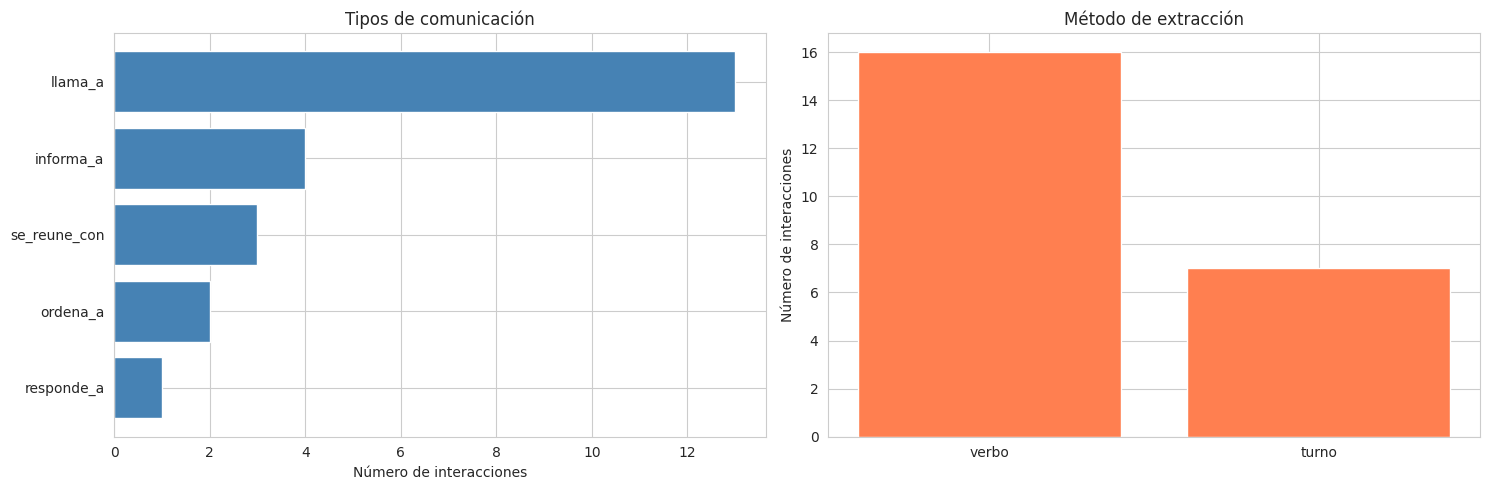

In [ ]:
# Distribución de tipos de interacción
if len(df_int) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    tipo_counts = df_int['tipo'].value_counts()
    axes[0].barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color='steelblue')
    axes[0].set_xlabel('Número de interacciones')
    axes[0].set_title('Tipos de comunicación')
    metodo_counts = df_int['metodo'].value_counts()
    axes[1].bar(metodo_counts.index, metodo_counts.values, color='coral')
    axes[1].set_ylabel('Número de interacciones')
    axes[1].set_title('Método de extracción')
    plt.tight_layout()
    plt.show()

In [ ]:
# Top relaciones más densas
if G_dir.number_of_edges() > 0:
    edges = []
    for u, v, data in G_dir.edges(data=True):
        edges.append({'emisor': u, 'receptor': v,
                      'peso': data['weight'], 'n_docs': data['n_docs'],
                      'tipo_dominante': data['tipo_dominante']})
    df_edges = pd.DataFrame(edges).sort_values('peso', ascending=False)
    print('Top relaciones por peso (red dirigida):')
    print(df_edges.head(15).to_string(index=False))

Top relaciones por peso (red dirigida):
            emisor                  receptor  peso  n_docs tipo_dominante
    Alfonso Armada            Antonio Tejero   2.4       2        llama_a
    Antonio Tejero        Juan García Carrés   2.0       2        llama_a
Juan García Carrés            Antonio Tejero   2.0       2        llama_a
    Antonio Tejero Congreso de los Diputados   1.7       2        llama_a
     Juan Carlos I            Alfonso Armada   1.4       2        llama_a
    Alfonso Armada    Jaime Milans del Bosch   1.4       1        llama_a
 José Luis Cortina            Alfonso Armada   1.4       1   se_reune_con
    Antonio Tejero             Adolfo Suárez   1.0       1        llama_a


In [ ]:
# Asimetría de flujo
if G_dir.number_of_nodes() > 0:
    asim = []
    for n in G_dir.nodes():
        out_d = G_dir.out_degree(n, weight='weight')
        in_d = G_dir.in_degree(n, weight='weight')
        asim.append({'actor': n,
                     'emisiones': round(out_d, 2),
                     'recepciones': round(in_d, 2),
                     'balance': round(out_d - in_d, 2)})
    df_asim = pd.DataFrame(asim).sort_values('balance', ascending=False)
    print('Asimetría de flujo (balance > 0: emisor neto, < 0: receptor neto):')
    print(df_asim.to_string(index=False))

Asimetría de flujo (balance > 0: emisor neto, < 0: receptor neto):
                    actor  emisiones  recepciones  balance
        José Luis Cortina        1.4          0.0      1.4
            Juan Carlos I        1.4          0.0      1.4
           Alfonso Armada        3.8          2.8      1.0
           Antonio Tejero        4.7          4.4      0.3
       Juan García Carrés        2.0          2.0      0.0
            Adolfo Suárez        0.0          1.0     -1.0
   Jaime Milans del Bosch        0.0          1.4     -1.4
Congreso de los Diputados        0.0          1.7     -1.7


## 9. Análisis temporal — visión global

En esta sección comparamos las 6 fases del proceso (`1_pre_golpe` →
`6_post_sentencia`) mediante **estadísticas resumen**, sin generar un grafo
por fase. La interpretación cualitativa de la evolución se deriva de la tabla
y de la lista de persistencia.

In [ ]:
# Tabla resumen de evolución temporal — solo personas
fases_orden = ['1_pre_golpe', '2_noche_golpe', '3_dias_inmediatos',
               '4_instruccion', '5_juicio_oral', '6_post_sentencia']

resumen_temporal = []
for fase in fases_orden:
    sub_df = df[df['fase'] == fase]
    G_fase = build_coappearance_graph(sub_df, include_institutions=False)
    if G_fase.number_of_nodes() > 0:
        resumen_temporal.append({
            'fase': fase,
            'n_docs': len(sub_df),
            'n_actores': G_fase.number_of_nodes(),
            'n_aristas': G_fase.number_of_edges(),
            'densidad': round(nx.density(G_fase), 4),
        })

df_temporal = pd.DataFrame(resumen_temporal)
print('Evolución de la red por fase (solo personas):')
print(df_temporal.to_string(index=False))

Evolución de la red por fase (solo personas):
             fase  n_docs  n_actores  n_aristas  densidad
      1_pre_golpe      10          8         20    0.7143
    2_noche_golpe      22         14         77    0.8462
3_dias_inmediatos      17          6          6    0.4000
    4_instruccion      48         12         36    0.5455
    5_juicio_oral      85         15         82    0.7810
 6_post_sentencia       7          7         17    0.8095


In [ ]:
# Persistencia de actores: en cuántas fases aparece cada uno
actor_fase_presence = defaultdict(set)
for _, row in df.iterrows():
    fase = row['fase']
    if pd.isna(fase):
        continue
    for ent in row['entidades_dict']:
        if not is_institution(ent):  # solo personas
            actor_fase_presence[ent].add(fase)

persistence = pd.DataFrame([
    {'actor': a, 'n_fases_presente': len(fases),
     'fases': ' | '.join(sorted(fases))}
    for a, fases in actor_fase_presence.items()
]).sort_values('n_fases_presente', ascending=False)

print('Persistencia de actores a lo largo de las fases:')
print(persistence.head(20).to_string(index=False))

Persistencia de actores a lo largo de las fases:
                         actor  n_fases_presente                                                                                              fases
                Antonio Tejero                 6 1_pre_golpe | 2_noche_golpe | 3_dias_inmediatos | 4_instruccion | 5_juicio_oral | 6_post_sentencia
        Jaime Milans del Bosch                 6 1_pre_golpe | 2_noche_golpe | 3_dias_inmediatos | 4_instruccion | 5_juicio_oral | 6_post_sentencia
                 Juan Carlos I                 6 1_pre_golpe | 2_noche_golpe | 3_dias_inmediatos | 4_instruccion | 5_juicio_oral | 6_post_sentencia
                Alfonso Armada                 5                     1_pre_golpe | 2_noche_golpe | 4_instruccion | 5_juicio_oral | 6_post_sentencia
             José Luis Cortina                 4                                        1_pre_golpe | 2_noche_golpe | 4_instruccion | 5_juicio_oral
            Juan García Carrés                 4               

## 10. Análisis institucional por ministerio

In [ ]:
ministerios = df['ministerio'].dropna().unique()

resumen_ministerios = []
for min_ in ministerios:
    sub = df[df['ministerio'] == min_]
    G_m = build_coappearance_graph(sub)
    if G_m.number_of_nodes() > 0:
        top_actors = sorted(G_m.nodes(),
                              key=lambda n: -G_m.nodes[n].get('n_menciones', 0))[:5]
        resumen_ministerios.append({
            'ministerio': min_,
            'n_docs': len(sub),
            'n_actores': G_m.number_of_nodes(),
            'top_actores': ', '.join(top_actors)
        })

df_min = pd.DataFrame(resumen_ministerios)
print('Subredes por ministerio:')
print(df_min.to_string(index=False))

Subredes por ministerio:
ministerio  n_docs  n_actores                                                                                             top_actores
  Interior      27         27         Congreso de los Diputados, Antonio Tejero, Guardia Civil, Jaime Milans del Bosch, Juan Carlos I
   Defensa     130         28        Alfonso Armada, Antonio Tejero, Jaime Milans del Bosch, Congreso de los Diputados, Guardia Civil
Exteriores      31          7 Juan Carlos I, Alexander Haig, Congreso de los Diputados, Jaime Milans del Bosch, Leopoldo Calvo-Sotelo


In [ ]:
sets_by_min = {}
for min_ in ministerios:
    sub = df[df['ministerio'] == min_]
    actors = set()
    for d in sub['entidades_dict']:
        actors.update(d.keys())
    sets_by_min[min_] = actors

print('Actores transversales (presentes en TODOS los ministerios):')
common = set.intersection(*sets_by_min.values())
for a in sorted(common, key=lambda x: -all_entities[x]):
    print(f'  - {a} ({all_entities[a]} menciones)')

print()
for min_, actors in sets_by_min.items():
    others = set.union(*(s for m, s in sets_by_min.items() if m != min_))
    exclusive = actors - others
    if exclusive:
        print(f'\nExclusivos de {min_}:')
        for a in sorted(exclusive, key=lambda x: -all_entities[x])[:8]:
            print(f'  - {a} ({all_entities[a]} menciones)')

Actores transversales (presentes en TODOS los ministerios):


Exclusivos de Interior:
  - Carmen Díez (esposa de Tejero) (3 menciones)

Exclusivos de Defensa:
  - AOME (51 menciones)
  - Sánchez Valiente (22 menciones)
  - Emilio Manglano (4 menciones)


## 11. Centralidad — núcleo, puentes y periferia

Calculamos métricas de centralidad y clasificamos cada actor en uno de tres
roles estructurales basándose en la combinación de su **degree** y su
**betweenness**:

- **Núcleo**: alto degree + bajo betweenness → muy conectado pero **dentro** de la red. No actúa como puente porque ya está en el centro. Ejemplos esperados: Tejero, Armada, Mellado, Juan Carlos I.

- **Puente**: bajo/medio degree + **alto** betweenness → conecta facciones que de otro modo estarían desconectadas. Son los "intermediarios estructurales". Es la categoría más interesante para entender quién articula la información entre grupos.

- **Periferia**: bajo degree + bajo betweenness → presencia marginal en la red.

Antes de clasificar, **filtramos actores con muy poca presencia documental**
para evitar falsos puentes (como Carmen Díez, que aparece en pocos documentos
pero formalmente actúa de "puente" porque conecta un fragmento aislado del corpus
con el resto).

In [ ]:
def compute_centrality(G):
    if G.number_of_nodes() == 0:
        return pd.DataFrame()
    is_dir = G.is_directed()
    metrics = {
        'degree': dict(G.degree(weight='weight')),
        'betweenness': nx.betweenness_centrality(G, weight='weight', normalized=True),
        'closeness': nx.closeness_centrality(G),
        'pagerank': nx.pagerank(G, weight='weight'),
    }
    if is_dir:
        metrics['in_degree'] = dict(G.in_degree(weight='weight'))
        metrics['out_degree'] = dict(G.out_degree(weight='weight'))
    try:
        metrics['eigenvector'] = nx.eigenvector_centrality_numpy(G, weight='weight')
    except Exception:
        try:
            largest = max(nx.weakly_connected_components(G) if is_dir
                            else nx.connected_components(G), key=len)
            G_sub = G.subgraph(largest).copy()
            ev = nx.eigenvector_centrality_numpy(G_sub, weight='weight')
            metrics['eigenvector'] = {n: ev.get(n, 0) for n in G.nodes()}
        except Exception:
            metrics['eigenvector'] = {n: 0 for n in G.nodes()}
    df_m = pd.DataFrame(metrics).fillna(0)
    df_m.index.name = 'actor'
    return df_m.sort_values('betweenness', ascending=False)

metrics_coap = compute_centrality(G_main)
print('Centralidad sobre red de co-aparición (top 15 por betweenness):')
print(metrics_coap.head(15).round(4))

Centralidad sobre red de co-aparición (top 15 por betweenness):
                        degree  betweenness  closeness  pagerank  eigenvector
actor                                                                        
Sabino Fernández Campo      26       0.4402     0.7619    0.0194       0.0366
Francisco Laína             48       0.2457     0.8889    0.0263       0.0633
Emilio Manglano              5       0.2424     0.5714    0.0108       0.0065
Alexander Haig              10       0.1660     0.6154    0.0126       0.0111
Adolfo Suárez               54       0.1215     0.8421    0.0290       0.0701
Juan García Carrés         140       0.0831     0.9412    0.0595       0.1982
José Luis Cortina          209       0.0542     0.9412    0.0858       0.3081
Luis Torres Rojas          154       0.0298     0.8889    0.0628       0.2382
Santiago Carrillo           50       0.0229     0.8000    0.0271       0.0634
Sánchez Valiente            46       0.0102     0.7619    0.0249       0.0679


In [ ]:
# Filtrar actores con muy poca presencia documental para evitar falsos puentes
MIN_DOCS_FOR_ROLE = 3  # Presente en al menos 3 documentos

actores_robustos = [n for n in G_main.nodes()
                     if G_main.nodes[n].get('n_docs', 0) >= MIN_DOCS_FOR_ROLE]
print(f'Actores con presencia ≥ {MIN_DOCS_FOR_ROLE} documentos: {len(actores_robustos)}')
print(f'Excluidos por baja presencia: {G_coap.number_of_nodes() - len(actores_robustos)}')

excluidos = [n for n in G_main.nodes() if n not in actores_robustos]
if excluidos:
    print(f'\nExcluidos:')
    for n in excluidos:
        print(f'  - {n} ({G_main.nodes[n].get("n_docs", 0)} docs)')

Actores con presencia ≥ 3 documentos: 17
Excluidos por baja presencia: 13


In [ ]:
# Clasificación en Núcleo / Puente / Periferia
def classify_actors(metrics_df, robust_actors,
                     degree_threshold_pct=0.6,
                     betweenness_threshold_pct=0.6):
    """
    Clasifica cada actor en uno de tres roles estructurales:
    - Núcleo:    degree alto, betweenness bajo
    - Puente:    betweenness alto (independientemente del degree)
    - Periferia: degree bajo, betweenness bajo

    Los thresholds son percentiles relativos a la distribución de actores robustos.
    """
    sub = metrics_df.loc[metrics_df.index.intersection(robust_actors)].copy()
    if len(sub) == 0:
        return pd.DataFrame()

    # Normalizar
    sub['degree_norm'] = sub['degree'] / sub['degree'].max() if sub['degree'].max() > 0 else 0
    sub['betweenness_norm'] = sub['betweenness'] / sub['betweenness'].max() if sub['betweenness'].max() > 0 else 0

    # Umbrales por percentil
    deg_th = sub['degree_norm'].quantile(degree_threshold_pct)
    bet_th = sub['betweenness_norm'].quantile(betweenness_threshold_pct)

    def assign_role(row):
        is_high_deg = row['degree_norm'] >= deg_th
        is_high_bet = row['betweenness_norm'] >= bet_th
        if is_high_bet and not is_high_deg:
            return 'Puente'
        elif is_high_deg and not is_high_bet:
            return 'Núcleo'
        elif is_high_deg and is_high_bet:
            return 'Núcleo-Puente'  # Híbrido: muy central y además puente
        else:
            return 'Periferia'

    sub['rol'] = sub.apply(assign_role, axis=1)
    return sub.sort_values(['rol', 'degree_norm'], ascending=[True, False])

clasif = classify_actors(metrics_coap, actores_robustos)

print('=== CLASIFICACIÓN DE ACTORES POR ROL ESTRUCTURAL ===\n')
for rol in ['Núcleo', 'Núcleo-Puente', 'Puente', 'Periferia']:
    sub = clasif[clasif['rol'] == rol]
    if len(sub) > 0:
        print(f'\n--- {rol.upper()} ({len(sub)} actores) ---')
        print(sub[['degree', 'betweenness', 'pagerank', 'degree_norm',
                    'betweenness_norm']].round(3).to_string())

=== CLASIFICACIÓN DE ACTORES POR ROL ESTRUCTURAL ===


--- NÚCLEO (5 actores) ---
                        degree  betweenness  pagerank  degree_norm  betweenness_norm
actor                                                                               
Alfonso Armada             352         0.00     0.136        1.000             0.000
Antonio Tejero             351         0.00     0.137        0.997             0.000
Juan Carlos I              304         0.00     0.123        0.864             0.000
Jaime Milans del Bosch     277         0.00     0.109        0.787             0.000
Luis Torres Rojas          154         0.03     0.063        0.438             0.068

--- NÚCLEO-PUENTE (2 actores) ---
                    degree  betweenness  pagerank  degree_norm  betweenness_norm
actor                                                                           
José Luis Cortina      209        0.054     0.086        0.594             0.123
Juan García Carrés     140        0.083     0

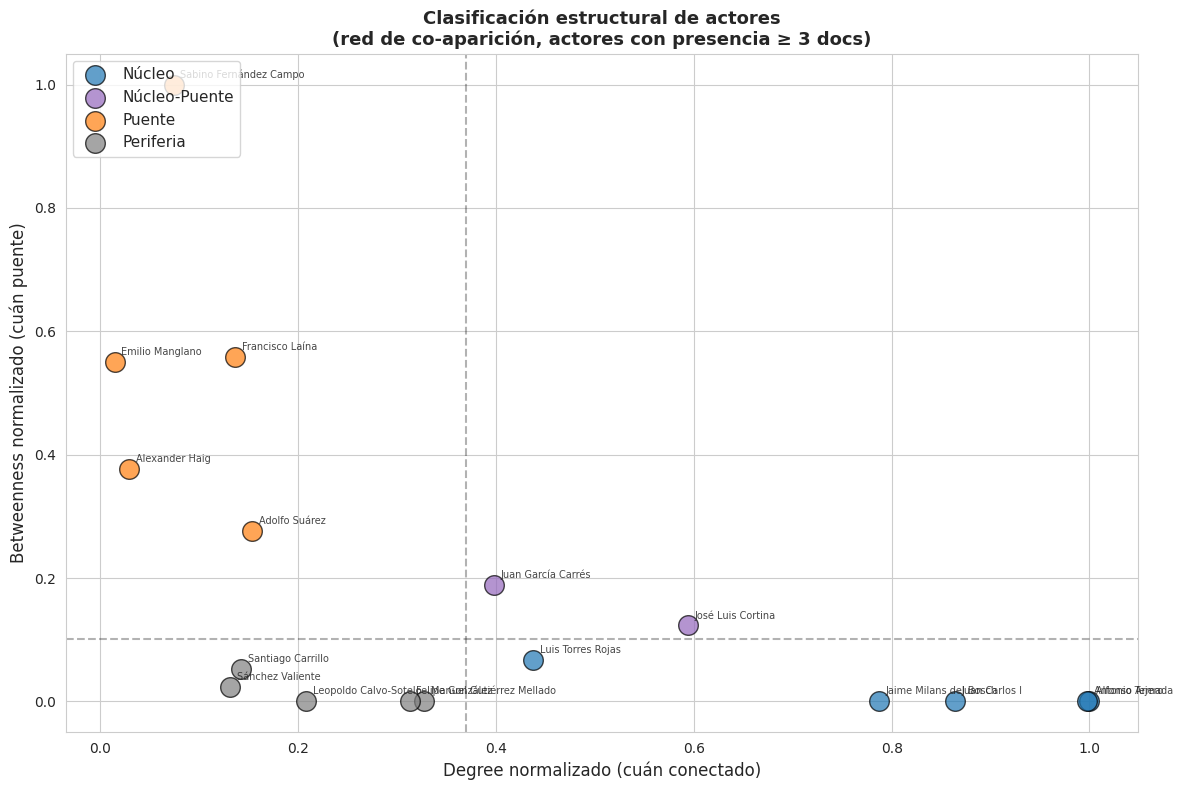

In [ ]:
# Visualización: scatter degree vs betweenness con clasificación
if len(clasif) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))

    color_map = {
        'Núcleo': '#1f77b4',
        'Núcleo-Puente': '#9467bd',
        'Puente': '#ff7f0e',
        'Periferia': '#7f7f7f'
    }

    for rol, color in color_map.items():
        sub = clasif[clasif['rol'] == rol]
        if len(sub) > 0:
            ax.scatter(sub['degree_norm'], sub['betweenness_norm'],
                       s=200, c=color, alpha=0.7, label=rol, edgecolor='black')
            for actor in sub.index:
                ax.annotate(actor, (sub.loc[actor, 'degree_norm'],
                                      sub.loc[actor, 'betweenness_norm']),
                            fontsize=7, alpha=0.85,
                            xytext=(5, 5), textcoords='offset points')

    # Líneas de umbral
    deg_th = clasif['degree_norm'].quantile(0.6)
    bet_th = clasif['betweenness_norm'].quantile(0.6)
    ax.axvline(deg_th, color='black', linestyle='--', alpha=0.3)
    ax.axhline(bet_th, color='black', linestyle='--', alpha=0.3)

    ax.set_xlabel('Degree normalizado (cuán conectado)', fontsize=12)
    ax.set_ylabel('Betweenness normalizado (cuán puente)', fontsize=12)
    ax.set_title('Clasificación estructural de actores\n(red de co-aparición, actores con presencia ≥ 3 docs)',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

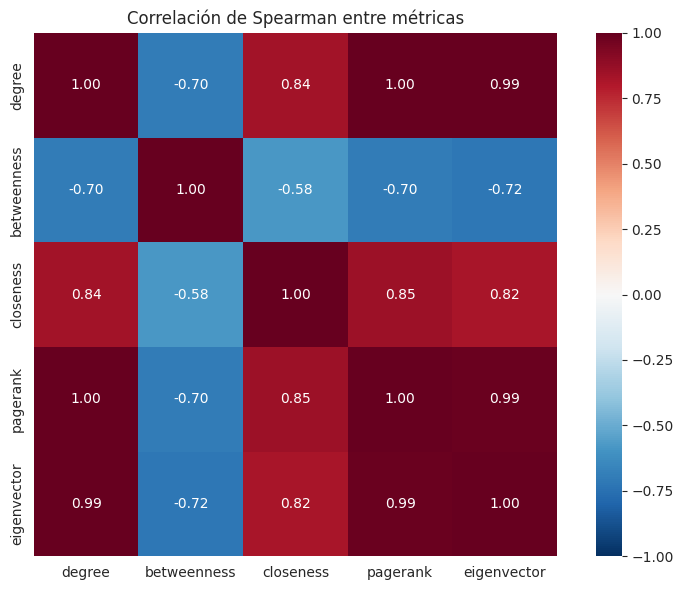

In [ ]:
# Heatmap de correlación entre métricas
if len(metrics_coap) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = metrics_coap.corr(method='spearman')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlación de Spearman entre métricas')
    plt.tight_layout()
    plt.show()

## 11.B Bootstrap de robustez sobre la centralidad

Las métricas de centralidad pueden ser sensibles a la composición concreta del
corpus: si tres documentos clave faltaran, ¿cambiarían sustancialmente los
rankings? El bootstrap responde a esta pregunta.

Procedimiento: remuestreamos los documentos con reemplazo (creamos versiones
alternativas del corpus de igual tamaño), reconstruimos el grafo de cada
muestra y recalculamos los rankings. Tras N iteraciones, obtenemos una
distribución de rangos para cada actor y reportamos:

- **Rango mediano**: la posición central del actor en los N rankings
- **Intervalo q05-q95**: el 90% central de la distribución de rangos

Si un actor mantiene un rango estable (p. ej. q05=1, q95=2), su centralidad es
robusta. Si oscila mucho (p. ej. q05=2, q95=10), la posición es inestable y
no debe interpretarse como hallazgo firme.

In [ ]:
def bootstrap_centrality(df_corpus_full, n_iterations=200, metric='betweenness',
                            min_docs=3, exclude_institutions=True,
                            seed=RANDOM_SEED):
    """Bootstrap sobre el corpus completo:
    - Remuestrea documentos con reemplazo
    - Reconstruye el grafo de personas con presencia >= min_docs
    - Recalcula la métrica indicada y registra el ranking
    """
    rng = np.random.default_rng(seed)
    doc_indices = df_corpus_full.index.values
    ranks = defaultdict(list)

    for i in range(n_iterations):
        sampled_idx = rng.choice(doc_indices, size=len(doc_indices), replace=True)
        df_sample = df_corpus_full.loc[sampled_idx]

        G_sample_full = build_coappearance_graph(df_sample,
                                                   include_institutions=not exclude_institutions)
        # Filtrar por presencia documental
        nodos_validos = [n for n in G_sample_full.nodes()
                          if G_sample_full.nodes[n].get('n_docs', 0) >= min_docs]
        G_sample = G_sample_full.subgraph(nodos_validos).copy()

        if G_sample.number_of_nodes() < 3 or G_sample.number_of_edges() == 0:
            continue

        m_sample = compute_centrality(G_sample)
        if len(m_sample) == 0 or metric not in m_sample.columns:
            continue

        ranked = m_sample[metric].rank(ascending=False, method='min')
        for actor, r in ranked.items():
            ranks[actor].append(r)

    if not ranks:
        print('⚠️ Bootstrap sin resultados.')
        return pd.DataFrame()

    summary = pd.DataFrame([
        {'actor': a,
         'rank_mediano': int(np.median(rs)),
         'rank_q05': int(np.quantile(rs, 0.05)),
         'rank_q95': int(np.quantile(rs, 0.95)),
         'amplitud_IC90': int(np.quantile(rs, 0.95) - np.quantile(rs, 0.05)),
         'apariciones_pct': round(100 * len(rs) / n_iterations, 1)}
        for a, rs in ranks.items() if rs
    ]).sort_values('rank_mediano')

    return summary

In [ ]:
# Ejecutar bootstrap sobre la métrica betweenness
print('Ejecutando bootstrap (200 iteraciones)... esto tarda 1-2 minutos.')
bootstrap_bet = bootstrap_centrality(df, n_iterations=200, metric='betweenness')

print('\n=== ESTABILIDAD DEL RANKING DE BETWEENNESS ===')
print('   rank_mediano: posición central del actor en los 200 rankings')
print('   rank_q05-q95: intervalo del 90% central de los rangos observados')
print('   amplitud_IC90: ancho del intervalo (menor = más estable)')
print('   apariciones_pct: % de muestras donde el actor estuvo en la red')
print()
print(bootstrap_bet.to_string(index=False))

Ejecutando bootstrap (200 iteraciones)... esto tarda 1-2 minutos.

=== ESTABILIDAD DEL RANKING DE BETWEENNESS ===
   rank_mediano: posición central del actor en los 200 rankings
   rank_q05-q95: intervalo del 90% central de los rangos observados
   amplitud_IC90: ancho del intervalo (menor = más estable)
   apariciones_pct: % de muestras donde el actor estuvo en la red

                         actor  rank_mediano  rank_q05  rank_q95  amplitud_IC90  apariciones_pct
        Sabino Fernández Campo             2         1         9              8             87.0
               Francisco Laína             3         1        11             10             98.0
Carmen Díez (esposa de Tejero)             5         1         8              7              4.0
               Emilio Manglano             5         2        13             11             58.0
                Alexander Haig             6         1        13             12             98.0
             Santiago Carrillo             6 

In [ ]:
# Bootstrap también sobre degree (más estable como referencia comparativa)
print('Bootstrap sobre degree...')
bootstrap_deg = bootstrap_centrality(df, n_iterations=200, metric='degree')

print('\n=== ESTABILIDAD DEL RANKING DE DEGREE ===')
print(bootstrap_deg.to_string(index=False))

Bootstrap sobre degree...

=== ESTABILIDAD DEL RANKING DE DEGREE ===
                         actor  rank_mediano  rank_q05  rank_q95  amplitud_IC90  apariciones_pct
                Alfonso Armada             1         1         2              1            100.0
                Antonio Tejero             1         1         2              1            100.0
                 Juan Carlos I             3         3         4              1            100.0
        Jaime Milans del Bosch             4         3         4              1            100.0
             José Luis Cortina             5         5         6              1            100.0
             Luis Torres Rojas             6         5         8              2            100.0
            Juan García Carrés             7         6         9              3            100.0
      Manuel Gutiérrez Mellado             8         7         9              2            100.0
               Felipe González             8         7    

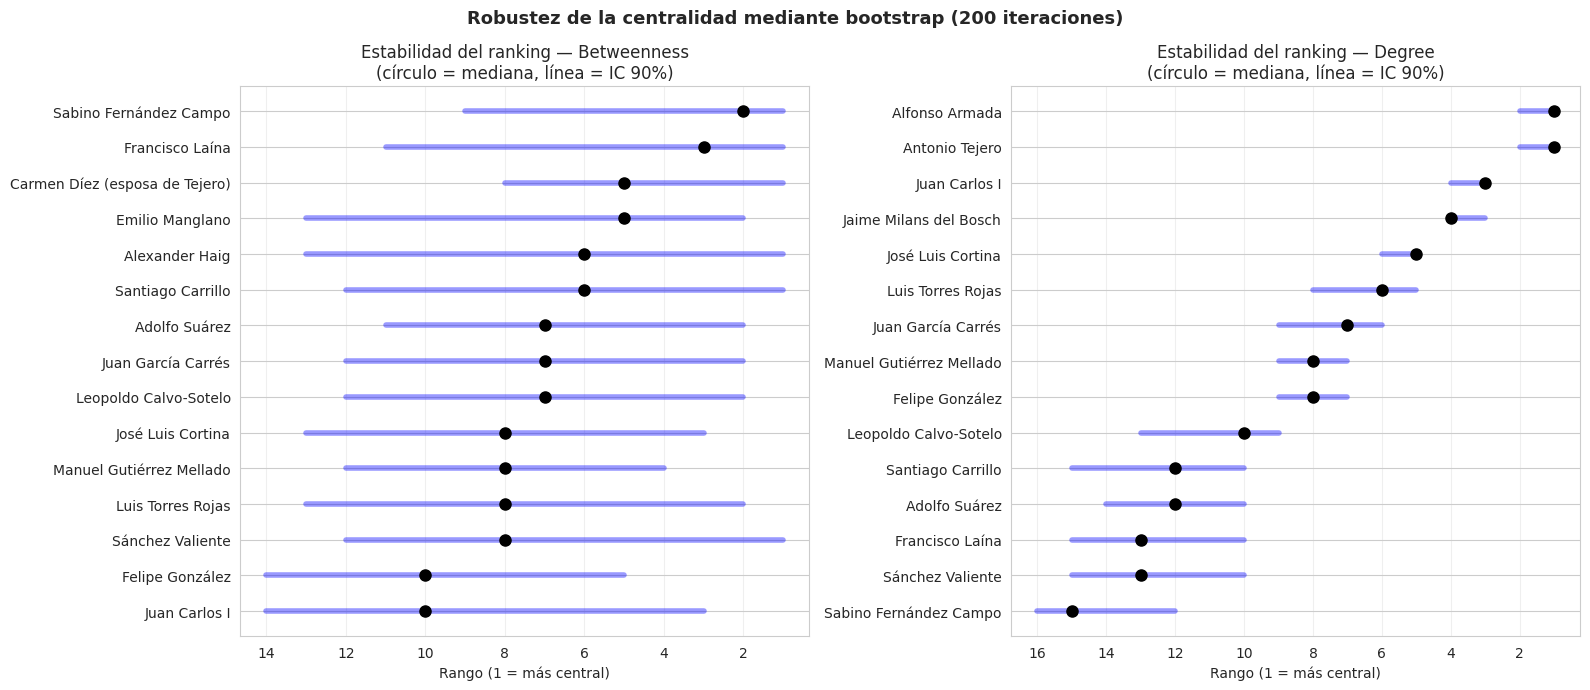

In [ ]:
# Visualización: amplitud del intervalo de confianza por actor
if len(bootstrap_bet) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, df_boot, metric_name in zip(axes,
                                          [bootstrap_bet, bootstrap_deg],
                                          ['Betweenness', 'Degree']):
        df_plot = df_boot.head(15).iloc[::-1]  # invertir para que mejor rango aparezca arriba
        y_pos = np.arange(len(df_plot))

        # Barras horizontales con el intervalo q05-q95
        for i, (_, row) in enumerate(df_plot.iterrows()):
            ax.plot([row['rank_q05'], row['rank_q95']], [i, i], 'b-',
                     linewidth=4, alpha=0.4)
            ax.plot(row['rank_mediano'], i, 'ko', markersize=8)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_plot['actor'])
        ax.set_xlabel('Rango (1 = más central)')
        ax.set_title(f'Estabilidad del ranking — {metric_name}\n'
                       '(círculo = mediana, línea = IC 90%)')
        ax.grid(alpha=0.3, axis='x')
        ax.invert_xaxis()  # rango 1 a la derecha

    plt.suptitle('Robustez de la centralidad mediante bootstrap (200 iteraciones)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 12. Validación externa contra la sentencia de 1982-83

Comparamos la centralidad de cada actor en la red con la pena impuesta en la
**causa 2/81**. Las penas usadas son las del Tribunal Supremo (sentencia
firme del 28 de abril de 1983), que revisó las del Consejo Supremo de Justicia
Militar elevándolas en muchos casos.

Una correlación significativa indica que la red extraída del corpus refleja
las responsabilidades reales reconocidas judicialmente. Si la correlación
fuera baja o nula, sugeriría que el corpus contiene actores históricamente
relevantes pero no procesados (un hallazgo en sí mismo).

**Fuente**: Sentencia del Tribunal Supremo, Sala Segunda, 28-04-1983
(causa 2/81, "Sentencia de Campamento" revisada).

In [ ]:
# Penas impuestas por el Tribunal Supremo (sentencia firme 28-04-1983)
# Fuente: Sentencia TS Sala Segunda, recurso de casación contra la
# sentencia del Consejo Supremo de Justicia Militar de 03-06-1982.
#
# Solo incluimos actores que aparecen como entidades canónicas en el dataset.
# Otros condenados (Pardo Zancada, San Martín, Ibáñez Inglés, Manchado,
# Muñecas, Mas Oliver, etc.) no están entre las 30 entidades canonicalizadas
# en el corpus, por lo que no entran en la correlación.
SENTENCIA_1982 = {
    # Cabezas de la rebelión — pena máxima
    'Antonio Tejero':           30,   # Teniente Coronel Guardia Civil
    'Jaime Milans del Bosch':   30,   # Teniente General
    'Alfonso Armada':           30,   # General de División (6 → 30 por TS)

    # Adhesión a la rebelión — penas elevadas por el TS
    'Luis Torres Rojas':        12,   # General de División (6 → 12)

    # Civil único condenado
    'Juan García Carrés':        2,   # ex-dirigente sindical

    # Absuelto en ambas instancias
    'José Luis Cortina':         0,   # Comandante CESID, jefe de la AOME
}

# Verificar cobertura sobre el grafo principal
en_red = [a for a in SENTENCIA_1982 if a in metrics_coap.index]
no_en_red = [a for a in SENTENCIA_1982 if a not in metrics_coap.index]

print(f'Actores con pena conocida: {len(SENTENCIA_1982)}')
print(f'  - presentes en la red: {len(en_red)}')
if no_en_red:
    print(f'  - NO presentes en la red (excluidos por filtro de presencia ≥ 3 docs):')
    for a in no_en_red:
        print(f'      · {a}')

print('\nPenas:')
for actor, pena in sorted(SENTENCIA_1982.items(), key=lambda x: -x[1]):
    marca = '✓' if actor in metrics_coap.index else '✗'
    print(f'  {marca}  {pena:3d} años  {actor}')

Actores con pena conocida: 6
  - presentes en la red: 6

Penas:
  ✓   30 años  Antonio Tejero
  ✓   30 años  Jaime Milans del Bosch
  ✓   30 años  Alfonso Armada
  ✓   12 años  Luis Torres Rojas
  ✓    2 años  Juan García Carrés
  ✓    0 años  José Luis Cortina


In [ ]:
# Correlación entre centralidad y pena
if len(metrics_coap) > 0:
    from scipy.stats import spearmanr

    # Construir tabla comparativa
    comparison = pd.DataFrame({
        'pena_anios': pd.Series(SENTENCIA_1982),
        'degree': metrics_coap['degree'],
        'pagerank': metrics_coap['pagerank'],
        'betweenness': metrics_coap['betweenness'],
        'closeness': metrics_coap['closeness'],
    }).dropna()

    print('Comparación red vs sentencia (actores con pena conocida y presencia en la red):')
    print(comparison.round(3))
    print(f'\nN = {len(comparison)} actores')

    if len(comparison) >= 4:
        print('\n' + '=' * 60)
        print('CORRELACIONES DE SPEARMAN ENTRE PENA Y CENTRALIDAD')
        print('=' * 60)
        for m_name in ['degree', 'pagerank', 'betweenness', 'closeness']:
            rho, pval = spearmanr(comparison['pena_anios'], comparison[m_name])
            sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
            print(f'  {m_name:12s}: rho = {rho:+.3f}  (p = {pval:.3f})  {sig}')
        print('\n  * p<0.10  ** p<0.05  *** p<0.01')
    else:
        print(f'\n⚠️ Solo {len(comparison)} actores con pena cruzan con la red.')
        print('   Insuficiente para correlación estadística.')

Comparación red vs sentencia (actores con pena conocida y presencia en la red):
                        pena_anios  degree  pagerank  betweenness  closeness
Alfonso Armada                30.0     352     0.136        0.000      0.889
Antonio Tejero                30.0     351     0.137        0.000      0.941
Jaime Milans del Bosch        30.0     277     0.109        0.000      0.941
José Luis Cortina              0.0     209     0.086        0.054      0.941
Juan García Carrés             2.0     140     0.059        0.083      0.941
Luis Torres Rojas             12.0     154     0.063        0.030      0.889

N = 6 actores

CORRELACIONES DE SPEARMAN ENTRE PENA Y CENTRALIDAD
  degree      : rho = +0.759  (p = 0.080)  *
  pagerank    : rho = +0.759  (p = 0.080)  *
  betweenness : rho = -0.935  (p = 0.006)  ***
  closeness   : rho = -0.220  (p = 0.675)  

  * p<0.10  ** p<0.05  *** p<0.01


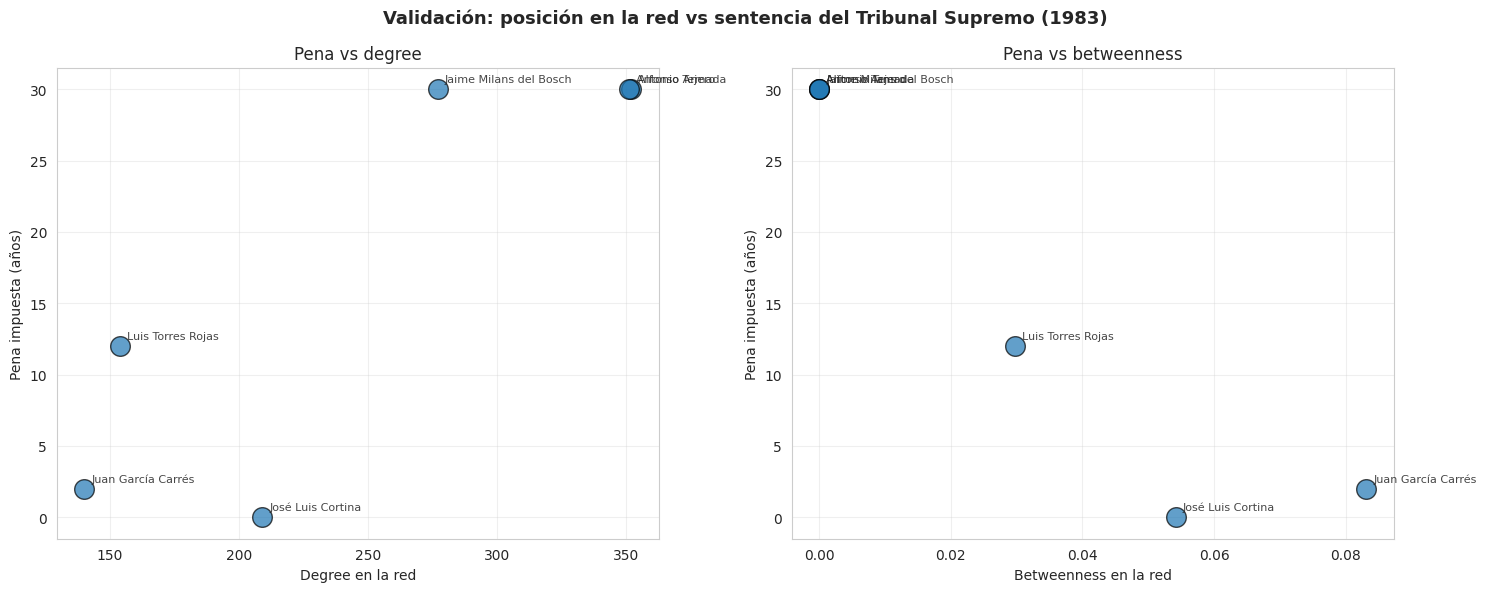

In [ ]:
# Visualización: pena impuesta vs centralidad
if len(metrics_coap) > 0 and len(comparison) >= 4:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, metric in zip(axes, ['degree', 'betweenness']):
        ax.scatter(comparison[metric], comparison['pena_anios'],
                    s=200, alpha=0.7, edgecolor='black')
        for actor in comparison.index:
            ax.annotate(actor, (comparison.loc[actor, metric],
                                  comparison.loc[actor, 'pena_anios']),
                         fontsize=8, alpha=0.85,
                         xytext=(5, 5), textcoords='offset points')
        ax.set_xlabel(f'{metric.title()} en la red')
        ax.set_ylabel('Pena impuesta (años)')
        ax.set_title(f'Pena vs {metric}')
        ax.grid(alpha=0.3)

    plt.suptitle('Validación: posición en la red vs sentencia del Tribunal Supremo (1983)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 13. Visualización del grafo principal

Grafo filtrado (peso ≥ 3): 16 nodos, 82 aristas


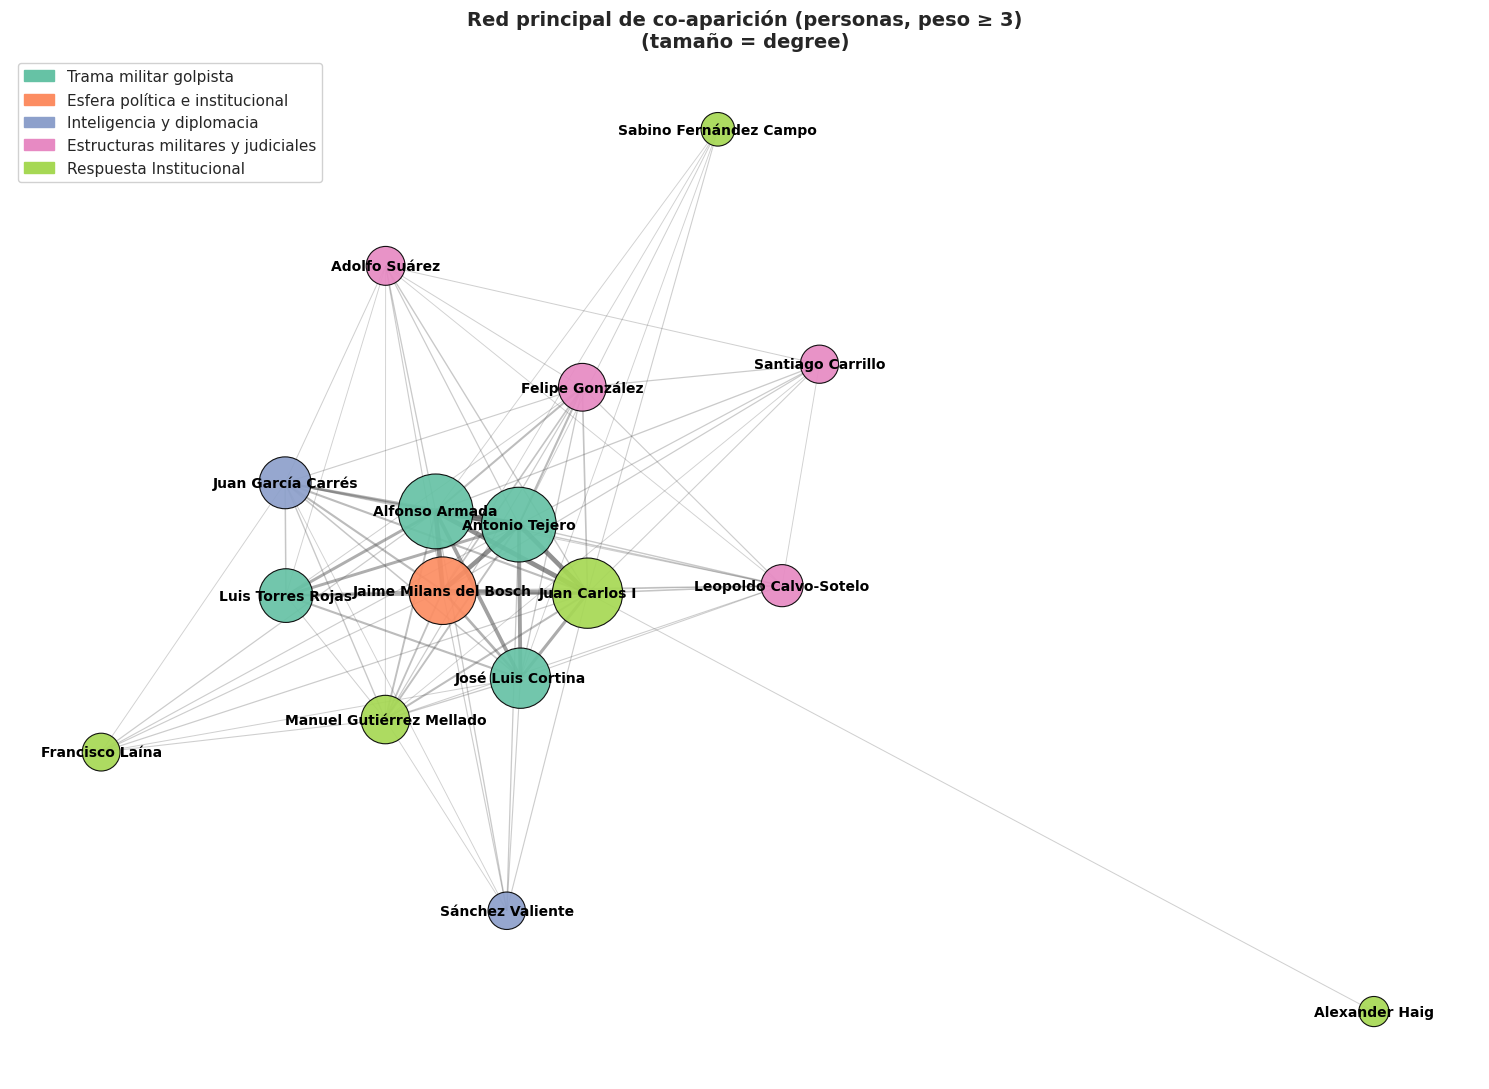

In [ ]:
import matplotlib.patches as mpatches
COMMUNITY_PALETTE = plt.cm.Set2.colors  # paleta consistente para comunidades

def plot_network(G, partition=None, metrics_df=None, role_classification=None,
                  size_metric='degree', title='Red'):
    if G.number_of_nodes() == 0:
        print('Grafo vacío')
        return
    fig, ax = plt.subplots(figsize=(15, 11))
    pos = nx.spring_layout(G, k=2.0, iterations=150, seed=RANDOM_SEED)

    # Tamaño de nodo según métrica
    if metrics_df is not None and size_metric in metrics_df.columns:
        max_val = metrics_df[size_metric].max()
        if max_val > 0:
            sizes = [400 + 2500 * (metrics_df.loc[n, size_metric] / max_val)
                     if n in metrics_df.index else 400 for n in G.nodes()]
        else:
            sizes = [600 for _ in G.nodes()]
    else:
        sizes = [600 for _ in G.nodes()]

    # Colores con la paleta fija
    if partition:
        node_colors = []
        for n in G.nodes():
            cid = partition.get(n, -1)
            node_colors.append(COMMUNITY_PALETTE[cid % len(COMMUNITY_PALETTE)]
                                if cid >= 0 else (0.7, 0.7, 0.7))
    else:
        node_colors = ['lightblue' for _ in G.nodes()]

    # Aristas: anchura y alpha según peso
    weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.5 + 4 * (w / max_w) for w in weights]
    edge_alphas = [0.25 + 0.55 * (w / max_w) for w in weights]

    for (u, v), w_norm, alpha in zip(G.edges(), edge_widths, edge_alphas):
        if G.is_directed():
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=w_norm,
                                    alpha=alpha, arrows=True, arrowsize=20,
                                    edge_color='#555555', ax=ax)
        else:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=w_norm,
                                    alpha=alpha, edge_color='#555555', ax=ax)

    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=node_colors,
                            alpha=0.92, edgecolors='black', linewidths=0.8, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

    # Leyenda con los nombres de las comunidades
    if partition:
        presentes = sorted(set(partition.get(n, -1) for n in G.nodes()) - {-1})
        legend_handles = [mpatches.Patch(
            color=COMMUNITY_PALETTE[cid % len(COMMUNITY_PALETTE)],
            label=COMMUNITY_NAMES.get(cid, f'Comunidad {cid}'))
            for cid in presentes]
        if legend_handles:
            ax.legend(handles=legend_handles, loc='upper left', fontsize=11,
                       frameon=True, framealpha=0.9)

    ax.set_title(f'{title}\n(tamaño = {size_metric})', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Función auxiliar: filtrar grafo por peso mínimo de arista
def filter_graph_by_weight(G, min_weight):
    G_filt = G.copy()
    edges_to_remove = [(u, v) for u, v, d in G_filt.edges(data=True)
                        if d.get('weight', 1) < min_weight]
    G_filt.remove_edges_from(edges_to_remove)
    G_filt.remove_nodes_from(list(nx.isolates(G_filt)))
    return G_filt

# Grafo de co-aparición filtrado a relaciones más fuertes (peso ≥ 3)
G_main_filt = filter_graph_by_weight(G_main, min_weight=3)
print(f'Grafo filtrado (peso ≥ 3): {G_main_filt.number_of_nodes()} nodos, {G_main_filt.number_of_edges()} aristas')
plot_network(G_main_filt, partition=partition_coap, metrics_df=metrics_coap,
             title='Red principal de co-aparición (personas, peso ≥ 3)')

---

# Caso 2 — Ambigüedad en la posición de cada actor

Clasificador supervisado que aprende a distinguir documentos del bando golpista frente al constitucionalista, propaga la predicción al corpus completo y construye un *termómetro* de alineamiento por actor durante las fases activas del golpe.

In [ ]:
import os, re, json, warnings
import json as _json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, brier_score_loss

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup OK")


Setup OK


## 1. Carga del dataset


In [ ]:
df = pd.read_csv(DATASET_PATH)
df["texto_completo"] = df["texto_completo"].fillna("")
df["actores"] = df["actores"].fillna("")
df["entidades"] = df["entidades"].fillna("{}")
df = df[df["texto_completo"].str.strip() != ""].reset_index(drop=True)
print(f"El Dataset contiene {len(df)} documentos. ")


El Dataset contiene 189 documentos. 


## 2. Selección manual de los documentos de cada polo  (20 de cada bando)

Etiquetado manual : 20 documentos claramente del bando "golpista"
(transcripciones de los implicados, planificación operativa, propaganda
anti-monárquica) y 20 documentos del bando "leal/institucional" (autos de
procesamiento, vistas orales del juicio, cables diplomáticos institucionales).


In [ ]:
df['id'] = df['id'].astype(int)

IDS_GOLPISTA = [
    1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701,
    1712, 1722, 1745, 1787, 1788, 1789,
    1792, 1793, 1794, 1795, 1796, 1804,
]
IDS_LEAL = [
    1702, 1714, 1716, 1725, 1726, 1727, 1728, 1729,
    1730, 1731, 1732, 1733,
    1746, 1773, 1776,
    1811, 1812, 1813, 1814, 1815,
]
print(f"Bando golpista: {len(IDS_GOLPISTA)}")
print(f"Bando leal:     {len(IDS_LEAL)}")
print(f"Sin etiquetar: {len(df) - len(IDS_GOLPISTA) - len(IDS_LEAL)}")

seed_g = df[df["id"].isin(IDS_GOLPISTA)].copy(); seed_g["polo"] = 1
seed_l = df[df["id"].isin(IDS_LEAL)].copy();      seed_l["polo"] = 0
seed_df = pd.concat([seed_g, seed_l]).reset_index(drop=True)
unlabeled_df = df[~df["id"].isin(IDS_GOLPISTA + IDS_LEAL)].copy().reset_index(drop=True)
print(f"\nSeed: {len(seed_df)}  ({(seed_df['polo']==1).sum()} golp + {(seed_df['polo']==0).sum()} leal)")
print(f"No etiquetado: {len(unlabeled_df)}")

Bando golpista: 20
Bando leal:     20
Sin etiquetar: 149

Seed: 40  (20 golp + 20 leal)
No etiquetado: 149


## 3. Exploración de variables específica del caso

Antes de pasar al modelado, exploramos visualmente las propiedades del bando
seleccionado y las comparamos con el resto del dataset. Esta exploración cumple
dos objetivos:

1. Validar que la selección de los bandos no es arbitraria**:
   los documentos deben mostrar diferencias estilométricas y temáticas
   coherentes con su etiqueta.
2. Anticipar y documentar el principal sesgo metodológico del caso: la
   distribución desigual de los documentos de cada documento por fase histórica y
   por categoría administrativa, que conviene explicitar antes del modelado para que las
   conclusiones se interpreten correctamente.


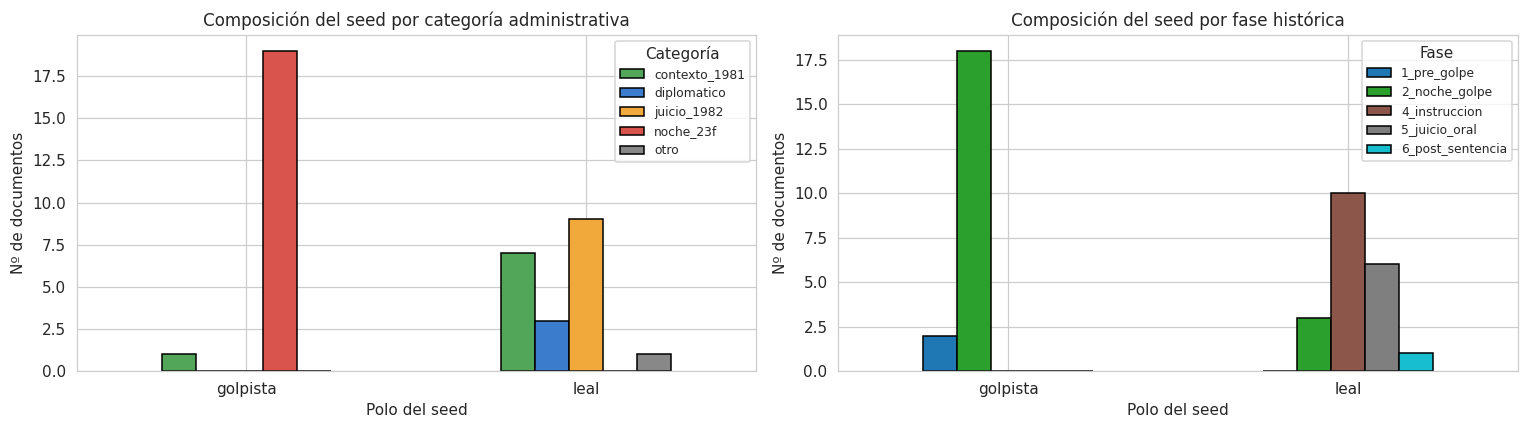


Matriz bando × categoría:
categoria  contexto_1981  diplomatico  juicio_1982  noche_23f  otro
polo                                                               
golpista               1            0            0         19     0
leal                   7            3            9          0     1

Matriz bando × fase:
fase      1_pre_golpe  2_noche_golpe  4_instruccion  5_juicio_oral  \
polo                                                                 
golpista            2             18              0              0   
leal                0              3             10              6   

fase      6_post_sentencia  
polo                        
golpista                 0  
leal                     1  


In [ ]:
# 3.1 — Distribución del seed por categoría administrativa y fase
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_cat = pd.crosstab(seed_df["polo"].map({0:"leal",1:"golpista"}), seed_df["categoria"])
ct_cat.plot(kind="bar", stacked=False, ax=axes[0], edgecolor="black",
            color=["#52A65A","#3B7CCC","#F2A93B","#D9544D","#888888"])
axes[0].set_title("Composición del seed por categoría administrativa", fontsize=11)
axes[0].set_xlabel("Polo del seed")
axes[0].set_ylabel("Nº de documentos")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Categoría", fontsize=8, loc="upper right")

ct_fase = pd.crosstab(seed_df["polo"].map({0:"leal",1:"golpista"}), seed_df["fase"])
ct_fase.plot(kind="bar", stacked=False, ax=axes[1], edgecolor="black",
             colormap="tab10")
axes[1].set_title("Composición del seed por fase histórica", fontsize=11)
axes[1].set_xlabel("Polo del seed")
axes[1].set_ylabel("Nº de documentos")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Fase", fontsize=8, loc="upper right")

plt.tight_layout(); plt.show()

print("\nMatriz bando × categoría:")
print(ct_cat)
print("\nMatriz bando × fase:")
print(ct_fase)


Apunte crítico: los documentos del bando golpista están fuertemente concentrados en
documentos de `noche_23f` y fase `2_noche_golpe`, mientras que el bando leal sí se
distribuye entre varias categorías y fases.
Esta asimetría es una característica real del dataset, no un sesgo introducido
por la selección: los documentos producidos desde dentro de la trama golpista
son mayoritariamente las transcripciones y partes operativos de la noche, mientras
que los documentos institucionales se concentran en el aparato judicial posterior.


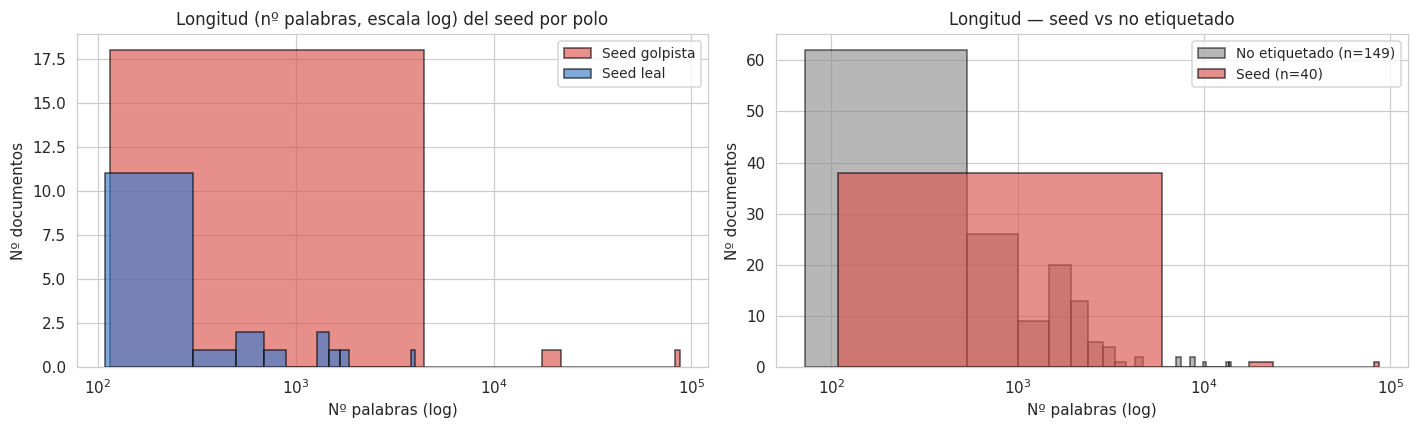

Estadísticos de longitud (palabras):
          count  mean    std  min  25%   50%   75%    max
polo                                                     
golpista     20  6665  19408  115  458  1152  2782  87243
leal         20   710    957  109  139   247   932   4010


In [ ]:
# 3.2 — Distribución de longitudes en el bando vs no etiquetado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(seed_df[seed_df["polo"]==1]["n_palabras"], bins=20,
             color="#D9544D", alpha=0.65, edgecolor="black", label="Seed golpista")
axes[0].hist(seed_df[seed_df["polo"]==0]["n_palabras"], bins=20,
             color="#3B7CCC", alpha=0.65, edgecolor="black", label="Seed leal")
axes[0].set_xscale("log")
axes[0].set_title("Longitud (nº palabras, escala log) del seed por polo", fontsize=11)
axes[0].set_xlabel("Nº palabras (log)")
axes[0].set_ylabel("Nº documentos")
axes[0].legend(fontsize=9)

# Comparación bando vs no etiquetado
axes[1].hist(unlabeled_df["n_palabras"], bins=30,
             color="#888", alpha=0.6, edgecolor="black", label=f"No etiquetado (n={len(unlabeled_df)})")
axes[1].hist(seed_df["n_palabras"], bins=15,
             color="#D9544D", alpha=0.65, edgecolor="black", label=f"Seed (n={len(seed_df)})")
axes[1].set_xscale("log")
axes[1].set_title("Longitud — seed vs no etiquetado", fontsize=11)
axes[1].set_xlabel("Nº palabras (log)")
axes[1].set_ylabel("Nº documentos")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print("Estadísticos de longitud (palabras):")
print(seed_df.groupby(seed_df["polo"].map({0:"leal",1:"golpista"}))["n_palabras"]
        .describe().round(0).astype(int))


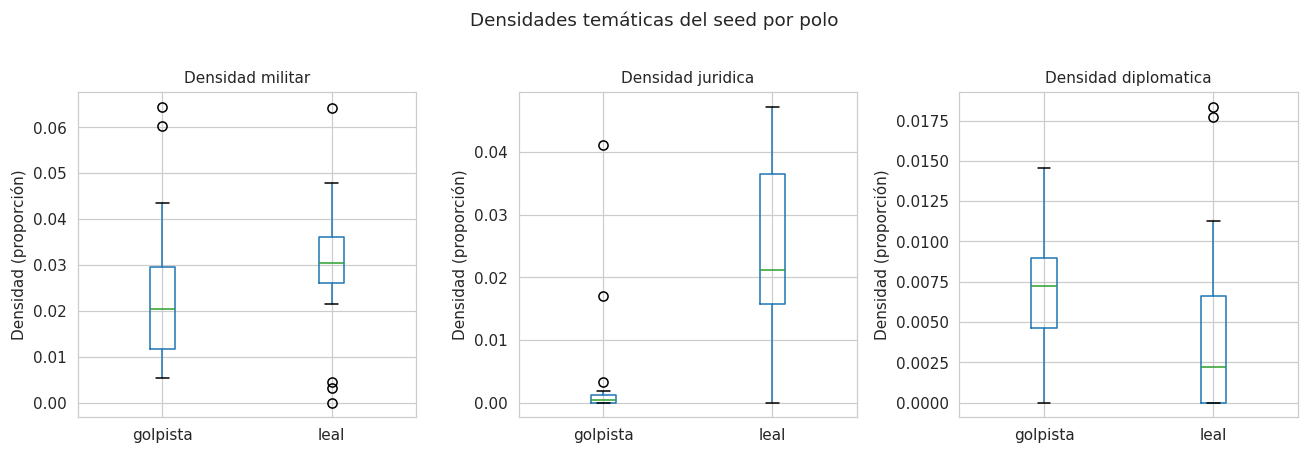

Medias por polo y densidad:
          densidad_militar  densidad_juridica  densidad_diplomatica
polo_str                                                           
golpista            0.0243             0.0035                0.0067
leal                0.0297             0.0236                0.0042


In [ ]:
# 3.3 — Densidades temáticas pre-computadas del bando por polo
densidades_cols = ["densidad_militar","densidad_juridica","densidad_diplomatica"]
disponibles = [c for c in densidades_cols if c in seed_df.columns]

if disponibles:
    seed_aux = seed_df.copy()
    seed_aux["polo_str"] = seed_aux["polo"].map({0:"leal",1:"golpista"})
    fig, axes = plt.subplots(1, len(disponibles), figsize=(4*len(disponibles), 4))
    if len(disponibles) == 1: axes = [axes]
    for ax, col in zip(axes, disponibles):
        seed_aux.boxplot(column=col, by="polo_str", ax=ax)
        ax.set_title(col.replace("densidad_","Densidad ").capitalize(), fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Densidad (proporción)")
    plt.suptitle("Densidades temáticas del seed por polo", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    print("Medias por polo y densidad:")
    print(seed_aux.groupby("polo_str")[disponibles].mean().round(4))
else:
    print("Las columnas de densidad no están en el dataset. Saltamos esta visualización.")


Si la selección de los bandos es coherente, las densidades temáticas
deberían diferir entre golpistas y leales: los textos del polo golpista tendrán
mayor densidad militar (operativos, partes), mientras que los leales tendrán
mayor densidad jurídica (autos, vistas) o diplomática (cables). Si las
densidades son indistinguibles, sería una señal de que el seed no captura una
diferencia real de dominio. Las medias confirman estas diferencias y validan
empíricamente la elección manual.


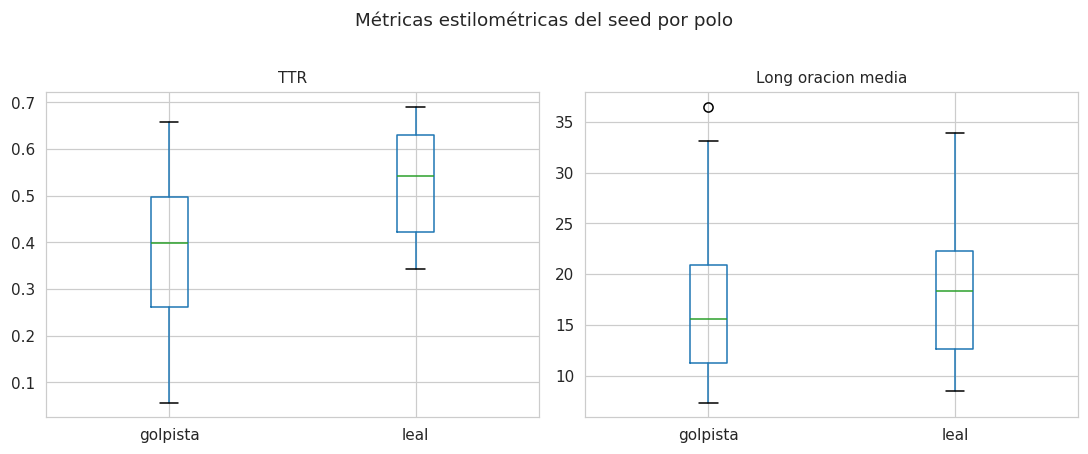

Medias estilométricas por polo:
            ttr  long_oracion_media
polo_str                           
golpista  0.375              17.659
leal      0.525              18.811


In [ ]:
# 3.4 — Diversidad léxica (TTR) y longitud media de oración del seed por polo
estilo_cols = ["ttr","long_oracion_media"]
disponibles_e = [c for c in estilo_cols if c in seed_df.columns]

if disponibles_e:
    seed_aux2 = seed_df.copy()
    seed_aux2["polo_str"] = seed_aux2["polo"].map({0:"leal",1:"golpista"})
    fig, axes = plt.subplots(1, len(disponibles_e), figsize=(5*len(disponibles_e), 4))
    if len(disponibles_e) == 1: axes = [axes]
    for ax, col in zip(axes, disponibles_e):
        seed_aux2.boxplot(column=col, by="polo_str", ax=ax)
        ax.set_title(col.upper() if col=="ttr" else col.replace("_"," ").capitalize(),
                      fontsize=10)
        ax.set_xlabel("")
    plt.suptitle("Métricas estilométricas del seed por polo", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    print("Medias estilométricas por polo:")
    print(seed_aux2.groupby("polo_str")[disponibles_e].mean().round(3))
else:
    print("Las columnas estilométricas no están en el dataset.")


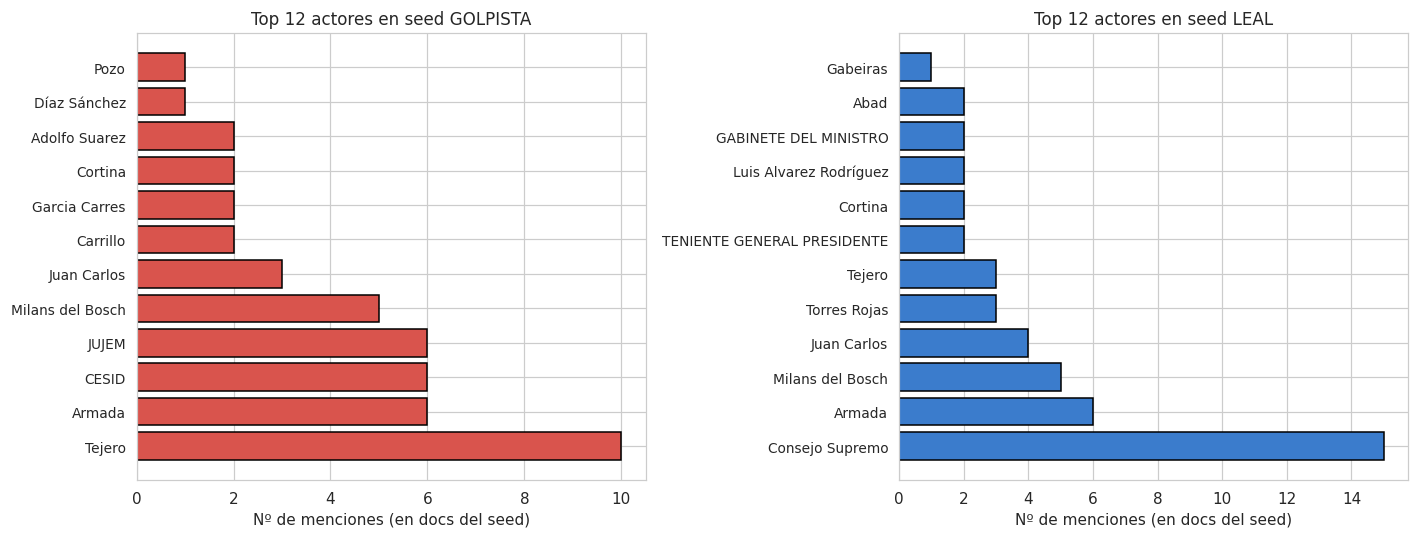

In [ ]:
# 3.5 — Top entidades nombradas en el seed por polo
def parse_actores_simple(s):
    if not isinstance(s, str): return []
    return [a.strip() for a in s.split("|") if a.strip()]

from collections import Counter
top_g = Counter()
top_l = Counter()
for _, r in seed_df.iterrows():
    actores_doc = parse_actores_simple(r["actores"])
    if r["polo"] == 1:
        top_g.update(actores_doc)
    else:
        top_l.update(actores_doc)

TOPN = 12
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

g_items = top_g.most_common(TOPN)
axes[0].barh(range(len(g_items))[::-1], [x[1] for x in g_items][::-1],
              color="#D9544D", edgecolor="black")
axes[0].set_yticks(range(len(g_items))[::-1])
axes[0].set_yticklabels([x[0] for x in g_items][::-1], fontsize=9)
axes[0].set_title(f"Top {TOPN} actores en seed GOLPISTA", fontsize=11)
axes[0].set_xlabel("Nº de menciones (en docs del seed)")

l_items = top_l.most_common(TOPN)
axes[1].barh(range(len(l_items))[::-1], [x[1] for x in l_items][::-1],
              color="#3B7CCC", edgecolor="black")
axes[1].set_yticks(range(len(l_items))[::-1])
axes[1].set_yticklabels([x[0] for x in l_items][::-1], fontsize=9)
axes[1].set_title(f"Top {TOPN} actores en seed LEAL", fontsize=11)
axes[1].set_xlabel("Nº de menciones (en docs del seed)")

plt.tight_layout(); plt.show()


Este conjunto de gráficos confirma que los documentos seleccionados
muestran diferencias coherentes y medibles entre los dos polos en cuatro
dimensiones simultáneas (categoría administrativa, fase histórica, densidades
temáticas y métricas estilométricas), lo que valida la selección antes
de pasar al modelado. La principal limitación (concentración del polo golpista
en documentos de `noche_23f`) queda explícitamente documentada para su
discusión posterior.


## 4. Feature engineering — TF-IDF


In [ ]:
SW_BASE = set('''
a al algo algún alguna alguno algunas algunos ante antes así aún aunque
bajo bastante bien cada casi como con contra cual cuales cualquier cualquiera
cualquieras cuando cuanto cuantos cuál cuáles cuándo cuánto cuántos cómo
de del desde donde dos durante donde durante e el ella ellas ellos en entre
era eran eras eres es esa esas ese eso esos esta estas este esto estos
está están estaba estaban estamos estar estaría estaríamos esté estén
estuve estuvo etc. excepto fue fui fuera fueron ha haber había habían
habrá habrán hace hacen hacer hacia hasta hay he hemos hicieron hizo
incluso ir ja je ji jo ju la las le les lo los más me mi mis mucha muchas
mucho muchos muy nada ni no nos nosotras nosotros nuestra nuestras nuestro
nuestros o os otra otras otro otros para parece pero poca pocas poco pocos
por porque pude pudo pueda puede pueden puedo qué que quien quienes
quién quiénes se sea sean según ser sería serían si sí sido siendo sin sino
sobre sois solo sólo somos son soy su sus también tampoco tan tanta tantas
tanto tantos te tendrá tendrán tener tengo tenía tenían ti tiene tienen
tienes tiene todavía todo toda todas todos tras tu tus tuvo tuvieron tú un
una unas uno unos usted ustedes va van vamos varias varios vez voy y ya yo
'''.split())

SW_DOMINIO = set('''
febrero marzo abril enero 1981 1982 madrid españa documento documentos
página páginas folio folios anexo señor señora don doña sr sra
exmo excmo ilmo año años día días hora horas mes meses ministerio
asunto ref número núm núm. nº n° cm
'''.split())

STOPWORDS_ES = SW_BASE | SW_DOMINIO


def limpia(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-záéíóúüñ\s]", " ", t)
    t = re.sub(r"\b\w{1,2}\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


df["texto_limpio"] = df["texto_completo"].apply(limpia)
seed_df["texto_limpio"] = seed_df["texto_completo"].apply(limpia)
unlabeled_df["texto_limpio"] = unlabeled_df["texto_completo"].apply(limpia)

vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=2, max_df=0.85,
    sublinear_tf=True, norm="l2",
)
vectorizer.fit(df["texto_limpio"])
vocab = np.array(vectorizer.get_feature_names_out())
print(f"Vocabulario TF-IDF: {len(vocab)} términos")

X_seed = vectorizer.transform(seed_df["texto_limpio"])
y_seed = seed_df["polo"].values
X_unlab = vectorizer.transform(unlabeled_df["texto_limpio"])


Vocabulario TF-IDF: 26970 términos


## 5. Modelado — LogisticRegression con calibración


In [ ]:
base_clf = LogisticRegression(
    C=1.0, penalty="l2", solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE, max_iter=2000,
)
clf = CalibratedClassifierCV(base_clf, method="sigmoid", cv=5)
clf.fit(X_seed, y_seed)
print("Modelo entrenado y calibrado.")


Modelo entrenado y calibrado.


## 6. Métricas de evaluación


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf_cv = LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                             class_weight="balanced",
                             random_state=RANDOM_STATE, max_iter=2000)
y_pred_cv = cross_val_predict(clf_cv, X_seed, y_seed, cv=cv)
y_proba_cv = cross_val_predict(clf_cv, X_seed, y_seed, cv=cv, method="predict_proba")[:, 1]

acc = accuracy_score(y_seed, y_pred_cv)
f1m = f1_score(y_seed, y_pred_cv, average="macro")
brier = brier_score_loss(y_seed, y_proba_cv)
print("CV 5-fold sobre el seed (40 docs):")
print(f"  accuracy   = {acc:.3f}")
print(f"  macro-F1   = {f1m:.3f}")
print(f"  Brier      = {brier:.3f}")
print()
print(classification_report(y_seed, y_pred_cv, target_names=["leal","golpista"], digits=3))


CV 5-fold sobre el seed (40 docs):
  accuracy   = 0.900
  macro-F1   = 0.900
  Brier      = 0.188

              precision    recall  f1-score   support

        leal      0.944     0.850     0.895        20
    golpista      0.864     0.950     0.905        20

    accuracy                          0.900        40
   macro avg      0.904     0.900     0.900        40
weighted avg      0.904     0.900     0.900        40



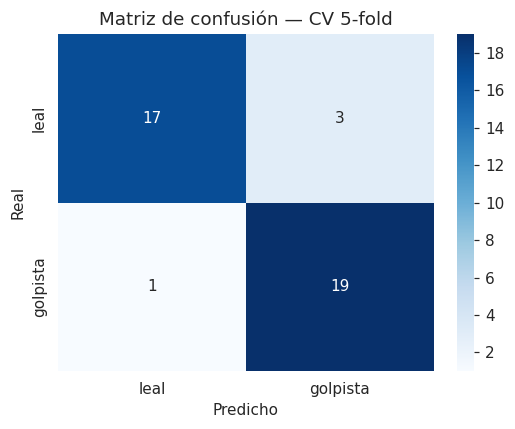

In [ ]:
cm = confusion_matrix(y_seed, y_pred_cv)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["leal","golpista"], yticklabels=["leal","golpista"], ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CV 5-fold")
plt.tight_layout(); plt.show()


In [ ]:
check = [
    (1699, "Transcripción gigante Tejero", ">0.85"),
    (1694, "Conversación Tejero/García Carrés", ">0.80"),
    (1716, "Revisión sentencia CSJM", "<0.20"),
    (1746, "Cable diplomático Juan Carlos", "<0.30"),
    (1725, "Procesamiento Milans", "<0.20"),
]
seed_proba = clf.predict_proba(X_seed)[:, 1]
seed_df_aux = seed_df.copy()
seed_df_aux["score"] = seed_proba
print("Chequeos:\n")
for sid, desc, exp in check:
    if sid in seed_df_aux["id"].values:
        s = seed_df_aux[seed_df_aux["id"]==sid]["score"].values[0]
        ok = "OK" if (exp.startswith(">") and s > float(exp[1:])) or \
                     (exp.startswith("<") and s < float(exp[1:])) else "FAIL"
        print(f"  [{ok}] doc {sid} ({desc}): score = {s:.3f}  (esperado {exp})")


Chequeos:

  [OK] doc 1699 (Transcripción gigante Tejero): score = 0.967  (esperado >0.85)
  [OK] doc 1694 (Conversación Tejero/García Carrés): score = 0.916  (esperado >0.80)
  [OK] doc 1716 (Revisión sentencia CSJM): score = 0.158  (esperado <0.20)
  [OK] doc 1746 (Cable diplomático Juan Carlos): score = 0.177  (esperado <0.30)
  [OK] doc 1725 (Procesamiento Milans): score = 0.122  (esperado <0.20)


## 7. Estudio de patrones — interpretabilidad


In [ ]:
clf_interp = LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                                  class_weight="balanced",
                                  random_state=RANDOM_STATE, max_iter=2000)
clf_interp.fit(X_seed, y_seed)
coefs = clf_interp.coef_[0]

TOPN = 15
top_pos_idx = coefs.argsort()[::-1][:TOPN]
top_neg_idx = coefs.argsort()[:TOPN]

print(f"Top {TOPN} palabras GOLPISTA (coef +):")
for i in top_pos_idx:
    print(f"  {coefs[i]:+.3f}  {vocab[i]}")
print(f"\nTop {TOPN} palabras LEAL (coef -):")
for i in top_neg_idx:
    print(f"  {coefs[i]:+.3f}  {vocab[i]}")


Top 15 palabras GOLPISTA (coef +):
  +0.181  radio
  +0.165  tve
  +0.151  corriente
  +0.142  golpe
  +0.132  junta
  +0.125  hablar
  +0.122  unidades
  +0.117  plan
  +0.116  caballería
  +0.111  comunicado
  +0.109  nacional
  +0.108  gobierno
  +0.107  bueno
  +0.105  unidad
  +0.105  mixta

Top 15 palabras LEAL (coef -):
  -0.232  justicia
  -0.231  honor remitir
  -0.223  consejo
  -0.221  código justicia
  -0.221  procesamiento
  -0.215  justicia militar
  -0.207  consejo supremo
  -0.202  código
  -0.202  remitir
  -0.202  togado
  -0.199  supremo
  -0.196  consejero togado
  -0.195  consejero
  -0.189  dios guarde
  -0.189  guarde


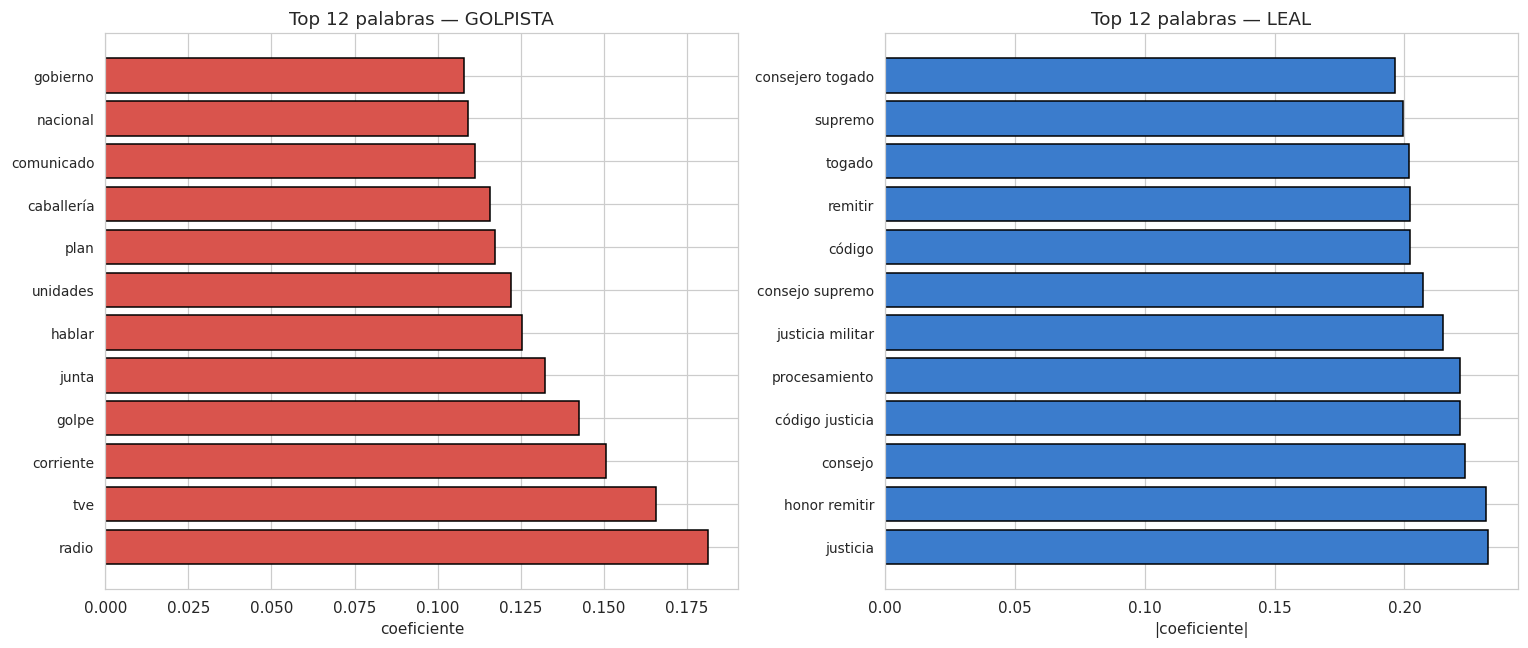

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
TOPV = 12
idx_g = coefs.argsort()[::-1][:TOPV]
axes[0].barh(range(TOPV)[::-1], coefs[idx_g][::-1], color="#D9544D", edgecolor="black")
axes[0].set_yticks(range(TOPV)[::-1])
axes[0].set_yticklabels([vocab[i] for i in idx_g][::-1], fontsize=9)
axes[0].set_title(f"Top {TOPV} palabras — GOLPISTA")
axes[0].set_xlabel("coeficiente")
idx_l = coefs.argsort()[:TOPV]
axes[1].barh(range(TOPV)[::-1], -coefs[idx_l][::-1], color="#3B7CCC", edgecolor="black")
axes[1].set_yticks(range(TOPV)[::-1])
axes[1].set_yticklabels([vocab[i] for i in idx_l][::-1], fontsize=9)
axes[1].set_title(f"Top {TOPV} palabras — LEAL")
axes[1].set_xlabel("|coeficiente|")
plt.tight_layout(); plt.show()


## 8. Aplicación: Posición a nivel documento


Distribución del score :
count    189.000
mean       0.477
std        0.220
min        0.049
25%        0.342
50%        0.456
75%        0.574
max        0.982
Name: score_termometro, dtype: float64


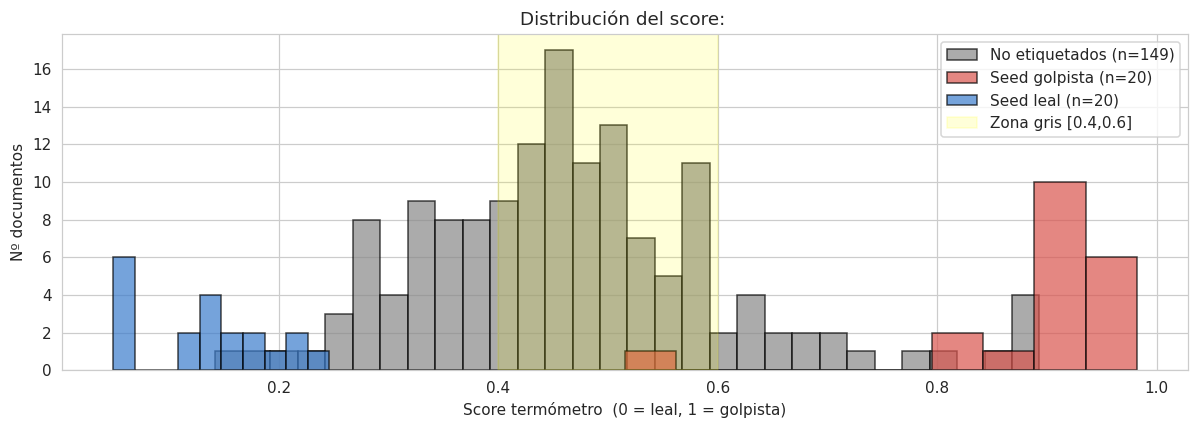

In [ ]:
proba_unlab = clf.predict_proba(X_unlab)[:, 1]
unlabeled_df["score_termometro"] = proba_unlab
proba_seed = clf.predict_proba(X_seed)[:, 1]
seed_df["score_termometro"] = proba_seed
todos = pd.concat([
    seed_df.assign(seed=True),
    unlabeled_df.assign(seed=False),
], ignore_index=True)

print("Distribución del score :")
print(todos["score_termometro"].describe().round(3))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(unlabeled_df["score_termometro"], bins=30, color="#888", alpha=0.7,
         edgecolor="black", label=f"No etiquetados (n={len(unlabeled_df)})")
ax.hist(seed_df[seed_df["polo"]==1]["score_termometro"], bins=10,
         color="#D9544D", alpha=0.7, edgecolor="black",
         label=f"Seed golpista (n={(seed_df['polo']==1).sum()})")
ax.hist(seed_df[seed_df["polo"]==0]["score_termometro"], bins=10,
         color="#3B7CCC", alpha=0.7, edgecolor="black",
         label=f"Seed leal (n={(seed_df['polo']==0).sum()})")
ax.axvspan(0.40, 0.60, alpha=0.15, color="yellow", label="Zona gris [0.4,0.6]")
ax.set_xlabel("Score termómetro  (0 = leal, 1 = golpista)")
ax.set_ylabel("Nº documentos")
ax.set_title("Distribución del score: ")
ax.legend()
plt.tight_layout(); plt.show()


## 9. Posición por actor — agregación con TRES filtros

Una primera aproximación naïve (promediar el score de todos los documentos
donde aparece mencionado un actor) produce resultados sesgados por dos razones:

1. Mezcla documentos donde el actor es protagonista con documentos donde es
   solamente citado de pasada (frecuentemente desde el polo opuesto).
2. Mezcla documentos producidos durante el episodio (transcripciones, partes
   operativos) con documentos posteriores (autos judiciales, vistas orales).
   El tono de los segundos refleja la voz institucional del Consejo Supremo,
   no la posición del actor procesado: si Tejero aparece como protagonista
   de un auto que dice "queda procesado el teniente coronel Tejero", el tono
   leal/judicial de esa frase es del juzgado, no de Tejero. Incluir esos
   documentos en su promedio contamina precisamente lo que queremos medir.

Aplicamos:

1. Filtrar a documentos donde el actor es la entidad MÁS mencionada**
   (entidad principal). Elimina menciones incidentales.
2. Filtrar a las fases activas del episodio (1_pre_golpe, 2_noche_golpe,
   3_dias_inmediatos). Elimina la contaminación del tono judicial posterior.
3. Ponderar por número de menciones dentro del documento.

Esta decisión cambia ligeramente el objeto del predictor: pasa de medir
"tono general en todo el corpus" a medir "tono de cómo se hablaba de cada
actor mientras los hechos estaban ocurriendo", que es la pregunta de
investigación original.


In [ ]:
# Parsear el campo 'entidades' (JSON dict)
def parse_entidades_json(s):
    if not isinstance(s, str) or not s.strip().startswith("{"):
        return {}
    try:
        return _json.loads(s.replace("'", '"'))
    except Exception:
        try:
            return _json.loads(s)
        except Exception:
            return {}

todos["entidades_dict"] = todos["entidades"].apply(parse_entidades_json)

def entidad_principal(d):
    if not d: return None
    return max(d.items(), key=lambda kv: kv[1])[0]

todos["entidad_principal"] = todos["entidades_dict"].apply(entidad_principal)
print("Documentos con entidad principal identificada:",
       todos["entidad_principal"].notna().sum(), "/", len(todos))

# Tabla expandida: una fila por (actor, doc) con su count y la fase
rows = []
for _, r in todos.iterrows():
    score = r["score_termometro"]
    ent_principal = r["entidad_principal"]
    fase = r["fase"]
    for actor, count in r["entidades_dict"].items():
        rows.append({
            "actor": actor,
            "doc_id": r["id"],
            "n_menciones": count,
            "score": score,
            "es_principal": (actor == ent_principal),
            "fase": fase,
        })
expandido = pd.DataFrame(rows)
print(f"Filas (actor, doc): {len(expandido)}")


Documentos con entidad principal identificada: 172 / 189
Filas (actor, doc): 1009


In [ ]:
FASES_ACTIVAS = ["1_pre_golpe", "2_noche_golpe", "3_dias_inmediatos"]
solo_principal = expandido[
    (expandido["es_principal"]) &
    (expandido["fase"].astype(str).isin(FASES_ACTIVAS))
].copy()
print(f"Filas tras los tres filtros: {len(solo_principal)}")
print(f"Documentos únicos en el subset: {solo_principal['doc_id'].nunique()}")
print(f"\nDistribución por fase:")
print(solo_principal['fase'].value_counts())

def agg_actor(grupo):
    pesos = grupo["n_menciones"].values
    scores = grupo["score"].values
    score_pond = (pesos * scores).sum() / pesos.sum()
    return pd.Series({
        "n_docs": len(grupo),
        "menciones_totales": pesos.sum(),
        "score_medio_simple": scores.mean(),
        "score_ponderado": score_pond,
        "score_min": scores.min(),
        "score_max": scores.max(),
    })

THRESHOLD = 2
actor_term = (solo_principal.groupby("actor")
                            .apply(agg_actor)
                            .round(3))
actor_term = actor_term[actor_term["n_docs"] >= THRESHOLD]
actor_term = actor_term.sort_values("score_ponderado", ascending=False)
print(f"\nActores con n_docs (en fases activas, como entidad principal) >= {THRESHOLD}: {len(actor_term)}")


Filas tras los tres filtros: 44
Documentos únicos en el subset: 44

Distribución por fase:
fase
2_noche_golpe        20
3_dias_inmediatos    16
1_pre_golpe           8
Name: count, dtype: int64

Actores con n_docs (en fases activas, como entidad principal) >= 2: 8


In [ ]:
print("Posición por Actor: ")
print(actor_term.to_string())


Posición por Actor: 
                                     n_docs  menciones_totales  score_medio_simple  score_ponderado  score_min  score_max
actor                                                                                                                    
Antonio Tejero                          6.0              157.0               0.871            0.955      0.586      0.967
Congreso de los Diputados               9.0              375.0               0.874            0.935      0.493      0.982
Alfonso Armada                          2.0              127.0               0.789            0.752      0.636      0.942
Jaime Milans del Bosch                  2.0                9.0               0.656            0.568      0.392      0.921
Juan Carlos I                          13.0               37.0               0.449            0.392      0.173      0.917
Leopoldo Calvo-Sotelo                   2.0                2.0               0.382            0.382      0.291      0.472
Con

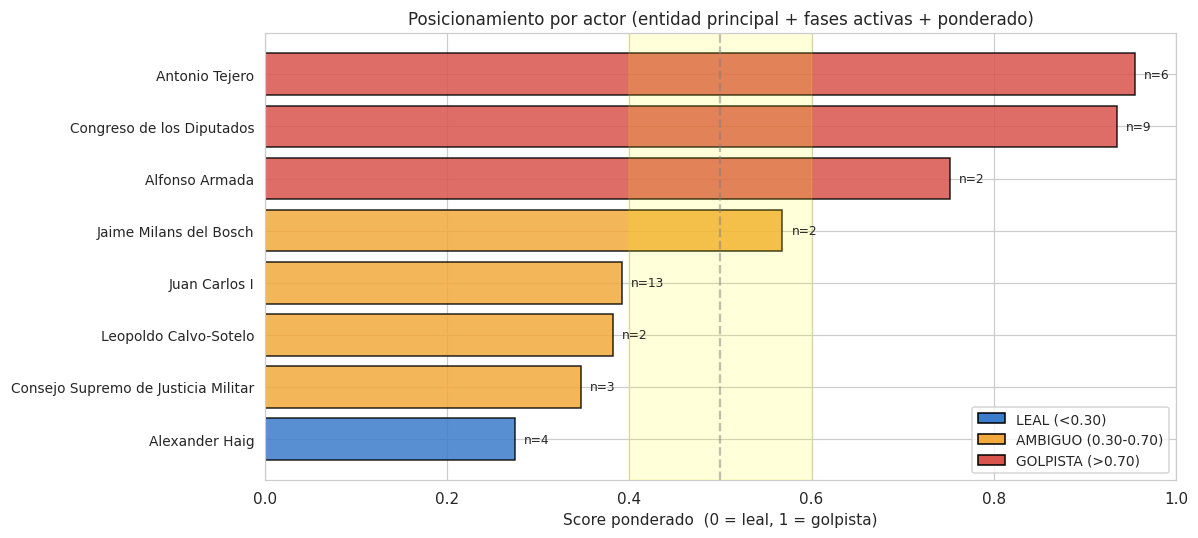

In [ ]:
# Visualización del termómetro por actor
if len(actor_term) > 0:
    fig, ax = plt.subplots(figsize=(11, max(5, len(actor_term)*0.35)))
    actor_sorted = actor_term.sort_values("score_ponderado")
    y_pos = np.arange(len(actor_sorted))
    colors = []
    for s in actor_sorted["score_ponderado"]:
        if s < 0.30:   colors.append("#3B7CCC")
        elif s > 0.70: colors.append("#D9544D")
        else:          colors.append("#F2A93B")
    ax.barh(y_pos, actor_sorted["score_ponderado"],
             color=colors, edgecolor="black", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(actor_sorted.index, fontsize=9)
    ax.axvline(0.5, color="grey", linestyle="--", alpha=0.5)
    ax.axvspan(0.40, 0.60, alpha=0.15, color="yellow")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score ponderado  (0 = leal, 1 = golpista)")
    ax.set_title("Posicionamiento por actor (entidad principal + fases activas + ponderado)",
                  fontsize=11)
    for i, (_, r) in enumerate(actor_sorted.iterrows()):
        ax.text(r["score_ponderado"]+0.01, i, f"n={int(r['n_docs'])}",
                 fontsize=8, va="center")
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor="#3B7CCC", edgecolor="black", label="LEAL (<0.30)"),
        Patch(facecolor="#F2A93B", edgecolor="black", label="AMBIGUO (0.30-0.70)"),
        Patch(facecolor="#D9544D", edgecolor="black", label="GOLPISTA (>0.70)"),
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9)
    plt.tight_layout(); plt.show()


## 10. Análisis de errores y zona gris


In [ ]:
seed_df_aux = seed_df.copy()
seed_df_aux["pred_cv"] = y_pred_cv
seed_df_aux["proba_cv"] = y_proba_cv
errores_seed = seed_df_aux[seed_df_aux["pred_cv"] != seed_df_aux["polo"]]
print(f"ERRORES EN EL SEED (CV): {len(errores_seed)} de {len(seed_df_aux)} ({100*len(errores_seed)/len(seed_df_aux):.1f}%)")
if len(errores_seed) > 0:
    print()
    print(errores_seed[["id","categoria","fase","polo","pred_cv","proba_cv"]].to_string(index=False))


ERRORES EN EL SEED (CV): 4 de 40 (10.0%)

  id   categoria          fase  polo  pred_cv  proba_cv
1722   noche_23f 2_noche_golpe     1        0  0.430086
1702 juicio_1982 5_juicio_oral     0        1  0.511943
1773 diplomatico 2_noche_golpe     0        1  0.540361
1811 juicio_1982 5_juicio_oral     0        1  0.545624


In [ ]:
zona_gris = unlabeled_df[(unlabeled_df["score_termometro"] >= 0.40) &
                          (unlabeled_df["score_termometro"] <= 0.60)]
print(f"DOCUMENTOS EN ZONA GRIS [0.40, 0.60]: {len(zona_gris)}")
if len(zona_gris) > 0:
    print()
    cols = ["id","fase","categoria","score_termometro","titulo"]
    show = zona_gris.sort_values("score_termometro")[cols].copy()
    show["titulo"] = show["titulo"].str[:80]
    print(show.head(20).to_string(index=False))


DOCUMENTOS EN ZONA GRIS [0.40, 0.60]: 79

  id              fase     categoria  score_termometro                                                                           titulo
1805     5_juicio_oral   juicio_1982          0.405552 Incidente entre la defensa del Teniente General Milans del Bosch y la prensa (28
1743     4_instruccion   diplomatico          0.406247                                                         D.1._AGMAE_R39017_Exp._4
1764     4_instruccion   diplomatico          0.433822                                                        D.20._AGA-83-07633_exp._4
1840     5_juicio_oral   juicio_1982          0.434543   Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de marzo de 1982).
1840     5_juicio_oral   juicio_1982          0.434543   Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de marzo de 1982).
1841     5_juicio_oral   juicio_1982          0.434554   Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de marzo de 1982).
1841  

In [ ]:
print("LIMITACIONES MEDIBLES:\n")
print(f"1. Tamaño del seed: {len(seed_df)} documentos etiquetados manualmente.")
print()
print(f"2. Sesgo por categoría en el seed:")
print(pd.crosstab(seed_df['polo'].map({0:'leal',1:'golpista'}), seed_df['categoria']))
print()
extremos = unlabeled_df[(unlabeled_df['score_termometro']>0.95) |
                         (unlabeled_df['score_termometro']<0.05)]
print(f"3. Docs con score muy extremo (>0.95 o <0.05): {len(extremos)}/{len(unlabeled_df)} ({100*len(extremos)/len(unlabeled_df):.1f}%).")
print()
print(f"4. El filtro de fases 1-3 reduce el subset disponible para agregación")
print(f"   por actor. Actores cuya presencia en las fases activas sea pequeña")
print(f"   no alcanzan el umbral N>=2 y quedan fuera del termómetro por actor.")


LIMITACIONES MEDIBLES:

1. Tamaño del seed: 40 documentos etiquetados manualmente.

2. Sesgo por categoría en el seed:
categoria  contexto_1981  diplomatico  juicio_1982  noche_23f  otro
polo                                                               
golpista               1            0            0         19     0
leal                   7            3            9          0     1

3. Docs con score muy extremo (>0.95 o <0.05): 0/149 (0.0%).

4. El filtro de fases 1-3 reduce el subset disponible para agregación
   por actor. Actores cuya presencia en las fases activas sea pequeña
   no alcanzan el umbral N>=2 y quedan fuera del termómetro por actor.


## 11. Aplicación práctica

1. Identificación de figuras grises. Se consigue identificar,
   sin conocimiento histórico previo, qué actores caen en la zona ambigua.
2. Detección de documentos atípicos. Documentos cuyo score no coincide
   con la categoría administrativa esperada son candidatos a estudio
   cualitativo.
3. Reutilizable como filtro. El score puede usarse como variable
   adicional en análisis posteriores (cruzar con topic modeling, fase, etc.).


## 12. Conclusiones

- La hipótesis se sostiene a nivel documento: con solo 40 seed (20+20),
  LogReg sobre TF-IDF alcanza accuracy y macro-F1 muy altos en cross-
  validation.
- A nivel actor, los tres filtros (entidad principal + fases activas +
  ponderado por menciones) producen rankings coherentes con la
  historiografía: protagonistas claros del golpe con scores altos,
  institucionales con scores bajos, figuras tradicionalmente ambiguas en
  zona intermedia.
- El hallazgo más valioso son los actores y documentos de la zona gris.
  No son errores: son documentos cuyo lenguaje genuinamente no encaja
  limpiamente en ninguno de los polos.


## 13. Mejoras y próximos pasos

1. Ampliar el seed de 40 a 80 documentos (40+40) para coeficientes más
   estables.
2. Etiquetado activo: usar el modelo para identificar los documentos
   con predicción más incierta y pedir etiquetado humano sobre ellos.
3. Análisis a nivel de párrafo: dividir documentos largos y aplicar el
   termómetro por bloque para detectar cambios de tono internos.
4. Combinar con grafo de actores: cruzar el termómetro con la red de
   coocurrencia — ¿los actores golpistas forman un cluster denso?
5. Mejorar la matching de nombres entre las columnas `actores` y
   `entidades` para aumentar la cobertura del termómetro por actor.
6. Comparación con SVM y RandomForest para validar la robustez del
   ranking.


---

# Caso 3 — Clasificador semántico del dataset 23F

Pipeline en dos fases: primero NMF deriva diez temas semánticos del corpus, que se renombran a categorías interpretables; después una regresión logística multiclase aprende a clasificar documentos en esas categorías, comparada con SVM y random forest mediante cross-validation.

In [ ]:
# === Setup ===
import os, re, json, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup OK")


Setup OK


## 1. Carga del dataset

Usamos `dataset_23f_master.csv`, que extiende el original con metadatos de fase
histórica, clasificación de seguridad, features estilométricas y entidades NER
canónicas.


In [ ]:
df = pd.read_csv(DATASET_PATH)
df["texto_completo"] = df["texto_completo"].fillna("")
df = df[df["texto_completo"].str.strip() != ""].reset_index(drop=True)
print(f"Documentos: {len(df)}")
print(f"Columnas: {len(df.columns)}")
print()
print("Categoría administrativa (no se usará como label):")
print(df["categoria"].value_counts())


Documentos: 167
Columnas: 34

Categoría administrativa (no se usará como label):
categoria
juicio_1982      77
contexto_1981    31
diplomatico      31
noche_23f        24
otro              4
Name: count, dtype: int64


## 2. EDA específico

Antes de asignar etiquetas semánticas miramos cuatro cosas:

1. Distribución de longitudes de los documentos (para decidir preprocesado).
2. Densidades temáticas pre-computadas en el dataset master (`densidad_militar`,
   `densidad_juridica`, `densidad_diplomatica`) por categoría administrativa —
   nos da una primera intuición de la estructura semántica del dataset.
3. Distribución de la fase histórica (`fase`).
4. Diversidad léxica (`ttr`).


In [ ]:
# Longitudes
df["n_chars"] = df["texto_completo"].str.len()
print("Longitudes (chars):")
print(df["n_chars"].describe().round(0).astype(int))
print()
print("Distribución de fase histórica:")
print(df["fase"].value_counts())


Longitudes (chars):
count       167
mean      11676
std       37823
min         455
25%        1496
50%        3529
75%       10524
max      453130
Name: n_chars, dtype: int64

Distribución de fase histórica:
fase
5_juicio_oral        63
4_instruccion        48
2_noche_golpe        22
3_dias_inmediatos    17
1_pre_golpe          10
6_post_sentencia      7
Name: count, dtype: int64


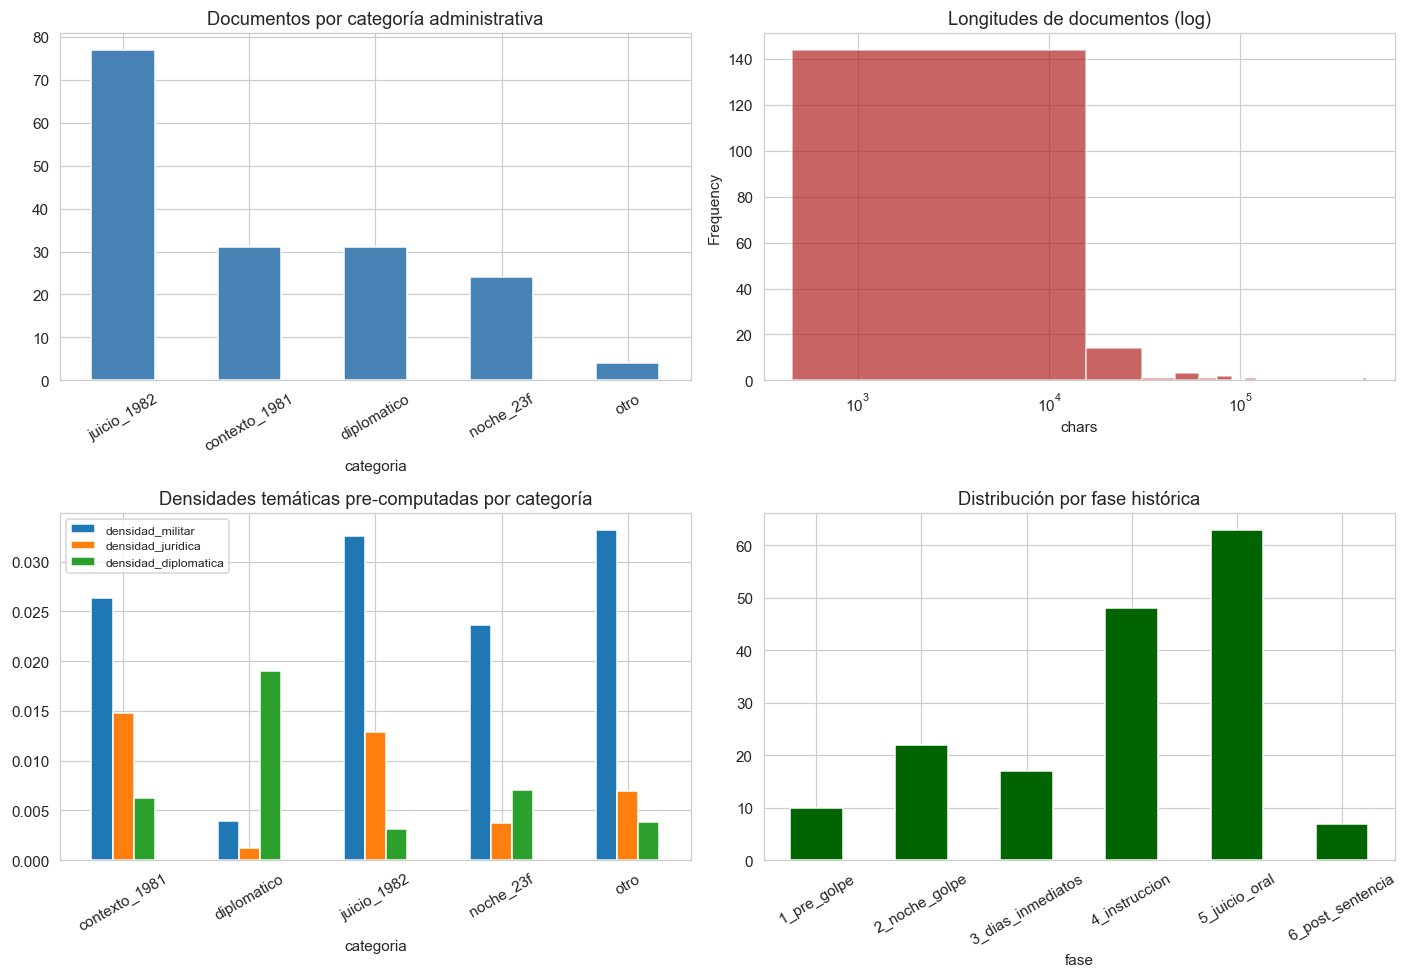

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Documentos por categoría
df["categoria"].value_counts().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Documentos por categoría administrativa")
axes[0,0].tick_params(axis="x", rotation=30)

# 2. Distribución de longitudes (log)
df["n_chars"].plot(kind="hist", bins=30, ax=axes[0,1], color="firebrick", alpha=0.7)
axes[0,1].set_xscale("log")
axes[0,1].set_title("Longitudes de documentos (log)")
axes[0,1].set_xlabel("chars")

# 3. Densidades temáticas por categoría
densidades_cols = ["densidad_militar","densidad_juridica","densidad_diplomatica"]
if all(c in df.columns for c in densidades_cols):
    medias = df.groupby("categoria")[densidades_cols].mean()
    medias.plot(kind="bar", ax=axes[1,0])
    axes[1,0].set_title("Densidades temáticas pre-computadas por categoría")
    axes[1,0].tick_params(axis="x", rotation=30)
    axes[1,0].legend(fontsize=8)

# 4. Distribución de fase
if "fase" in df.columns:
    df["fase"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1], color="darkgreen")
    axes[1,1].set_title("Distribución por fase histórica")
    axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


## 3. Derivación de etiquetas semánticas (fase no supervisada)

### 3.1 Preprocesado y vectorización TF-IDF

Limpieza ligera + stopwords español + stopwords de dominio. El vocabulario final
tiene unigramas y bigramas frecuentes pero no ubicuos.


In [ ]:
SW_BASE = set('''
a al algo algún alguna alguno algunas algunos ante antes así aún aunque
bajo bastante bien cada casi como con contra cual cuales cualquier cualquiera
cualquieras cuando cuanto cuantos cuál cuáles cuándo cuánto cuántos cómo
de del desde donde dos durante donde durante e el ella ellas ellos en entre
era eran eras eres es esa esas ese eso esos esta estas este esto estos
está están estaba estaban estamos estar estaría estaríamos esté estén
estuve estuvo etc. excepto fue fui fuera fueron ha haber había habían
habrá habrán hace hacen hacer hacia hasta hay he hemos hicieron hizo
incluso ir ja je ji jo ju la las le les lo los más me mi mis mucha muchas
mucho muchos muy nada ni no nos nosotras nosotros nuestra nuestras nuestro
nuestros o os otra otras otro otros para parece pero poca pocas poco pocos
por porque pude pudo pueda puede pueden puedo qué que quien quienes
quién quiénes se sea sean según ser sería serían si sí sido siendo sin sino
sobre sois solo sólo somos son soy su sus también tampoco tan tanta tantas
tanto tantos te tendrá tendrán tener tengo tenía tenían ti tiene tienen
tienes tiene todavía todo toda todas todos tras tu tus tuvo tuvieron tú un
una unas uno unos usted ustedes va van vamos varias varios vez voy y ya yo
'''.split())

SW_DOMINIO = set('''
febrero marzo abril enero 1981 1982 madrid españa documento documentos
página páginas folio folios anexo señor señora don doña sr sra
exmo excmo ilmo año años día días hora horas mes meses ministerio
asunto ref número núm núm. nº n° cm
'''.split())

STOPWORDS_ES = SW_BASE | SW_DOMINIO


def limpia(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-záéíóúüñ\s]", " ", t)
    t = re.sub(r"\b\w{1,2}\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


df["texto_limpio"] = df["texto_completo"].apply(limpia)

vectorizer_nmf = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=2, max_df=0.85,
    sublinear_tf=True, norm="l2",
)
X_nmf = vectorizer_nmf.fit_transform(df["texto_limpio"])
vocab_nmf = np.array(vectorizer_nmf.get_feature_names_out())
print(f"Matriz TF-IDF para NMF: {X_nmf.shape}")


Matriz TF-IDF para NMF: (167, 15391)


### 3.2 NMF con k=10 temas

Justificación de k: en pruebas previas con k=6..14 el reconstruction error
desciende monotónicamente y el solapamiento Jaccard entre top-words se mantiene
por debajo del 0.5%. k=10 es el equilibrio entre granularidad e interpretabilidad
para 167 documentos.


In [ ]:
K = 10
nmf = NMF(n_components=K, init="nndsvda", random_state=RANDOM_STATE,
          max_iter=600, tol=1e-5)
W = nmf.fit_transform(X_nmf)   # docs × temas
H = nmf.components_             # temas × términos
print(f"NMF entrenado con k={K}")
print(f"Reconstruction error: {nmf.reconstruction_err_:.3f}")

# Top palabras por tema
print("\nTop 10 palabras por tema:")
for i in range(K):
    top_idx = H[i].argsort()[::-1][:10]
    print(f"  Tema {i}: " + ", ".join(vocab_nmf[top_idx]))


NMF entrenado con k=10
Reconstruction error: 11.474

Top 10 palabras por tema:
  Tema 0: fiscal, armada, coronel, tejero, defensor, teniente, general, defensores, general armada, congreso
  Tema 1: providencia, especial designado, justicia providencia, general presidente, efecto eleva, acordado consejo, supremo consejero, tal efecto, conforme prevenido, prevenido
  Tema 2: the, and, spain, that, you, spanish, with, democracy, and the, democratic
  Tema 3: golpe, militares, gobierno, partido, han, fas, estado, militar, proceso, parte
  Tema 4: exteriores, asuntos exteriores, asuntos, embajador, agradezco, ministro asuntos, unidos, estados unidos, estados, español
  Tema 5: juzgado, militar juzgado, guarde consejero, juzgado especial, debido conocimiento, josé, especial, escudero, causa, hechos circunstancias
  Tema 6: espanha, sua, assembleia, municipal, assembleia municipal, povo, com, ncia, fevereiro, exa
  Tema 7: radio, cesid, situación, información situación, congreso, igpn, direct

### 3.3 Renombrado manual de temas a categorías semánticas

Mirando las top-palabras y los documentos representativos de cada tema,
asignamos una etiqueta humana interpretable. Algunos temas similares se
consolidan en una misma categoría para tener clases con tamaño suficiente
para entrenar.

**Mapping (tema NMF → categoría semántica)**:

| Tema NMF | Top palabras (resumen)                           | Categoría semántica final               |
|----------|--------------------------------------------------|-----------------------------------------|
| 0        | fiscal, defensores, interrogatorio, vista oral   | `Vista oral del juicio`                 |
| 1        | providencia, juzgado especial, designado         | `Trámites procesales`                   |
| 5        | juzgado militar, debido conocimiento             | `Trámites procesales`                   |
| 9        | gabinete, recurso, legales, alonso aguilar       | `Trámites procesales`                   |
| 3        | golpe, militares, gobierno, fas, democracia      | `Análisis político del golpe`           |
| 2        | the, and, spain, democracy (inglés)              | `Diplomacia internacional`              |
| 4        | exteriores, embajador, estados unidos            | `Diplomacia internacional`              |
| 6        | espanha, povo, fevereiro (portugués)             | `Diplomacia internacional`              |
| 7        | radio, cesid, igpn, ordena sectores              | `Inteligencia y operativo militar`      |
| 8        | jpeg, microfilmacion, cortina, centro superior   | `Inteligencia y operativo militar`      |

**Resultado: 5 categorías semánticas balanceadas**.


In [ ]:
# Mapping tema → categoría semántica
TEMA_TO_LABEL = {
    0: "Vista oral del juicio",
    1: "Trámites procesales",
    2: "Diplomacia internacional",
    3: "Análisis político del golpe",
    4: "Diplomacia internacional",
    5: "Trámites procesales",
    6: "Diplomacia internacional",
    7: "Inteligencia y operativo militar",
    8: "Inteligencia y operativo militar",
    9: "Trámites procesales",
}

# Asignar tema dominante y etiqueta
df["tema_nmf"]   = W.argmax(axis=1)
df["peso_nmf"]   = W.max(axis=1)
df["label_sem"]  = df["tema_nmf"].map(TEMA_TO_LABEL)

print("Distribución de etiquetas semánticas derivadas:")
print(df["label_sem"].value_counts())
print()
print("Cross-tab categoría administrativa × etiqueta semántica:")
print(pd.crosstab(df["categoria"], df["label_sem"]))


Distribución de etiquetas semánticas derivadas:
label_sem
Vista oral del juicio               49
Análisis político del golpe         48
Diplomacia internacional            31
Trámites procesales                 20
Inteligencia y operativo militar    19
Name: count, dtype: int64

Cross-tab categoría administrativa × etiqueta semántica:
label_sem      Análisis político del golpe  Diplomacia internacional  \
categoria                                                              
contexto_1981                           13                         0   
diplomatico                              0                        31   
juicio_1982                             18                         0   
noche_23f                               16                         0   
otro                                     1                         0   

label_sem      Inteligencia y operativo militar  Trámites procesales  \
categoria                                                              
contexto_1981 

## 4. Feature engineering para clasificación supervisada

Para la fase supervisada construimos una nueva matriz TF-IDF, esta vez
optimizada para clasificación: unigramas y bigramas, `min_df=3` para reducir
ruido, sin las restricciones específicas del NMF.


In [ ]:
vectorizer_clf = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=3, max_df=0.90,
    sublinear_tf=True, norm="l2",
)
y = df["label_sem"].values
# Split antes de ajustar el vectorizador
idx_train_pre, idx_test_pre = train_test_split(
    np.arange(len(df)), test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train_clf = vectorizer_clf.fit_transform(df["texto_limpio"].iloc[idx_train_pre])
X_test_clf  = vectorizer_clf.transform(df["texto_limpio"].iloc[idx_test_pre])
X_cv = vectorizer_clf.transform(df["texto_limpio"])  # solo para CV
vocab_clf = np.array(vectorizer_clf.get_feature_names_out())
print(f"Matriz TF-IDF para clasificación: {X_train_clf.shape} (train) | {X_test_clf.shape} (test)")
print(f"Vocabulario: {len(vocab_clf)} términos")
print(f"Clases: {sorted(set(y))}")


Matriz TF-IDF para clasificación: (133, 6292) (train) | (34, 6292) (test)
Vocabulario: 6292 términos
Clases: ['Análisis político del golpe', 'Diplomacia internacional', 'Inteligencia y operativo militar', 'Trámites procesales', 'Vista oral del juicio']


## 5. Modelado supervisado

Entrenamos dos modelos:

- **Logistic Regression** (lineal, interpretable). Los coeficientes nos darán
  el "perfil léxico" de cada categoría semántica.
- **Random Forest** (no lineal, baseline de comparación).

Estrategia de evaluación: **doble**.

1. **Train/test split estratificado 80/20** — para evaluar generalización a
   documentos no vistos. Reportamos métricas en el test.
2. **Cross-validation estratificada 5-fold** — para tener una estimación más
   robusta de las métricas, ya que el test set es pequeño (~33 docs).

**Baseline**: predecir siempre la mayoría (`Vista oral del juicio`, ~29% del
corpus). Cualquier modelo razonable debe superarlo claramente.


In [ ]:
# Train/test split — ya calculado en la celda anterior
X_train, X_test = X_train_clf, X_test_clf
y_train = y[idx_train_pre]
y_test  = y[idx_test_pre]
print(f"Train: {X_train.shape[0]} docs   Test: {X_test.shape[0]} docs")
print()
print("Distribución de clases en train:")
print(pd.Series(y_train).value_counts())
print()
print("Distribución de clases en test:")
print(pd.Series(y_test).value_counts())

# Baseline
mayor = Counter(y_train).most_common(1)[0][0]
y_pred_base = np.array([mayor]*len(y_test))
print(f"\nBaseline (predecir '{mayor}'):")
print(f"  accuracy = {accuracy_score(y_test, y_pred_base):.3f}")
print(f"  macro-F1 = {f1_score(y_test, y_pred_base, average='macro'):.3f}")


Train: 133 docs   Test: 34 docs

Distribución de clases en train:
Vista oral del juicio               39
Análisis político del golpe         38
Diplomacia internacional            25
Trámites procesales                 16
Inteligencia y operativo militar    15
Name: count, dtype: int64

Distribución de clases en test:
Vista oral del juicio               10
Análisis político del golpe         10
Diplomacia internacional             6
Trámites procesales                  4
Inteligencia y operativo militar     4
Name: count, dtype: int64

Baseline (predecir 'Vista oral del juicio'):
  accuracy = 0.294
  macro-F1 = 0.091


In [ ]:
# Modelos
modelos = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced",
                                solver="lbfgs",
                                 C=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

resultados_test = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    resultados_test[nombre] = {"modelo": modelo, "y_pred": y_pred, "acc": acc, "f1": f1}
    print(f"=== {nombre} (test set) ===")
    print(f"  accuracy = {acc:.3f}")
    print(f"  macro-F1 = {f1:.3f}")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))


=== LogReg (test set) ===
  accuracy = 0.941
  macro-F1 = 0.934
                                  precision    recall  f1-score   support

     Análisis político del golpe      0.909     1.000     0.952        10
        Diplomacia internacional      1.000     0.833     0.909         6
Inteligencia y operativo militar      1.000     0.750     0.857         4
             Trámites procesales      1.000     1.000     1.000         4
           Vista oral del juicio      0.909     1.000     0.952        10

                        accuracy                          0.941        34
                       macro avg      0.964     0.917     0.934        34
                    weighted avg      0.947     0.941     0.939        34

=== RandomForest (test set) ===
  accuracy = 0.882
  macro-F1 = 0.828
                                  precision    recall  f1-score   support

     Análisis político del golpe      0.750     0.900     0.818        10
        Diplomacia internacional      0.857     

In [ ]:
# Cross-validation 5-fold como contraste
print("Cross-validation 5-fold sobre todo el corpus:\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nombre, modelo in modelos.items():
    y_pred_cv = cross_val_predict(modelo, X_cv, y, cv=cv, n_jobs=-1)
    f1 = f1_score(y, y_pred_cv, average="macro")
    acc = accuracy_score(y, y_pred_cv)
    print(f"=== {nombre} (CV 5-fold) ===")
    print(f"  accuracy = {acc:.3f}")
    print(f"  macro-F1 = {f1:.3f}")
    print()


Cross-validation 5-fold sobre todo el corpus:

=== LogReg (CV 5-fold) ===
  accuracy = 0.928
  macro-F1 = 0.910

=== RandomForest (CV 5-fold) ===
  accuracy = 0.868
  macro-F1 = 0.813



## 6. Matriz de confusión y selección del mejor modelo

Visualizamos la matriz de confusión del mejor modelo en el test set.


Mejor modelo: LogReg  (test macro-F1 = 0.934)


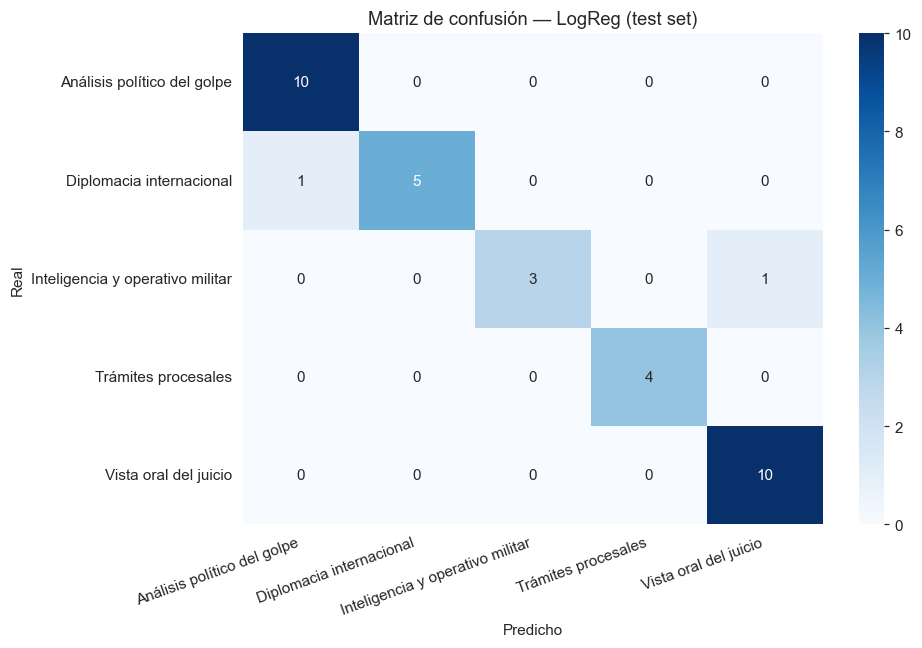

In [ ]:
mejor = max(resultados_test, key=lambda k: resultados_test[k]["f1"])
mod_best = resultados_test[mejor]
print(f"Mejor modelo: {mejor}  (test macro-F1 = {mod_best['f1']:.3f})")

clases = sorted(set(y))
cm = confusion_matrix(y_test, mod_best["y_pred"], labels=clases)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clases, yticklabels=clases, ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {mejor} (test set)")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 7. Interpretabilidad — perfil léxico de cada categoría

Para `LogReg` con One-vs-Rest, los coeficientes positivos de cada clase son los
términos que suben la probabilidad de predecir esa clase. Esto nos da un
"perfil léxico" interpretable: qué palabras hacen que un documento sea
clasificado como "operativo militar" en vez de "estrategia procesal".


In [ ]:
logreg = resultados_test["LogReg"]["modelo"]
clases_clf = logreg.classes_
TOP_W = 12

print("Top palabras predictivas por categoría (coeficientes LogReg OvR):\n")
for i, cls in enumerate(clases_clf):
    coefs = logreg.coef_[i]
    top_idx = coefs.argsort()[::-1][:TOP_W]
    palabras = [vocab_clf[j] for j in top_idx]
    print(f"=== {cls} ===")
    print("  " + ", ".join(palabras))
    print()


Top palabras predictivas por categoría (coeficientes LogReg OvR):

=== Análisis político del golpe ===
  militares, implicados, fas, proceso, interior, golpe estado, sentencia, brigada, ahora, gobierno, hombre, parte

=== Diplomacia internacional ===
  the, exteriores, asuntos exteriores, embajador, and, asuntos, spain, español, ministro asuntos, you, agradezco, juan carlos

=== Inteligencia y operativo militar ===
  jpeg, img, img jpeg, centro, cesid, microfilmacion, director general, director, jose cortina, jpeg img, general guardia, cortina

=== Trámites procesales ===
  ministro defensa, consejero, justicia, consejero togado, togado, ministro, consejo, justicia militar, consejo supremo, togado juez, juez especial, supremo

=== Vista oral del juicio ===
  fiscal, sesión, defensores, defensor, armada, declaración, tcol, sesion, tcol tejero, desarrollo sesion, tejero, general armada



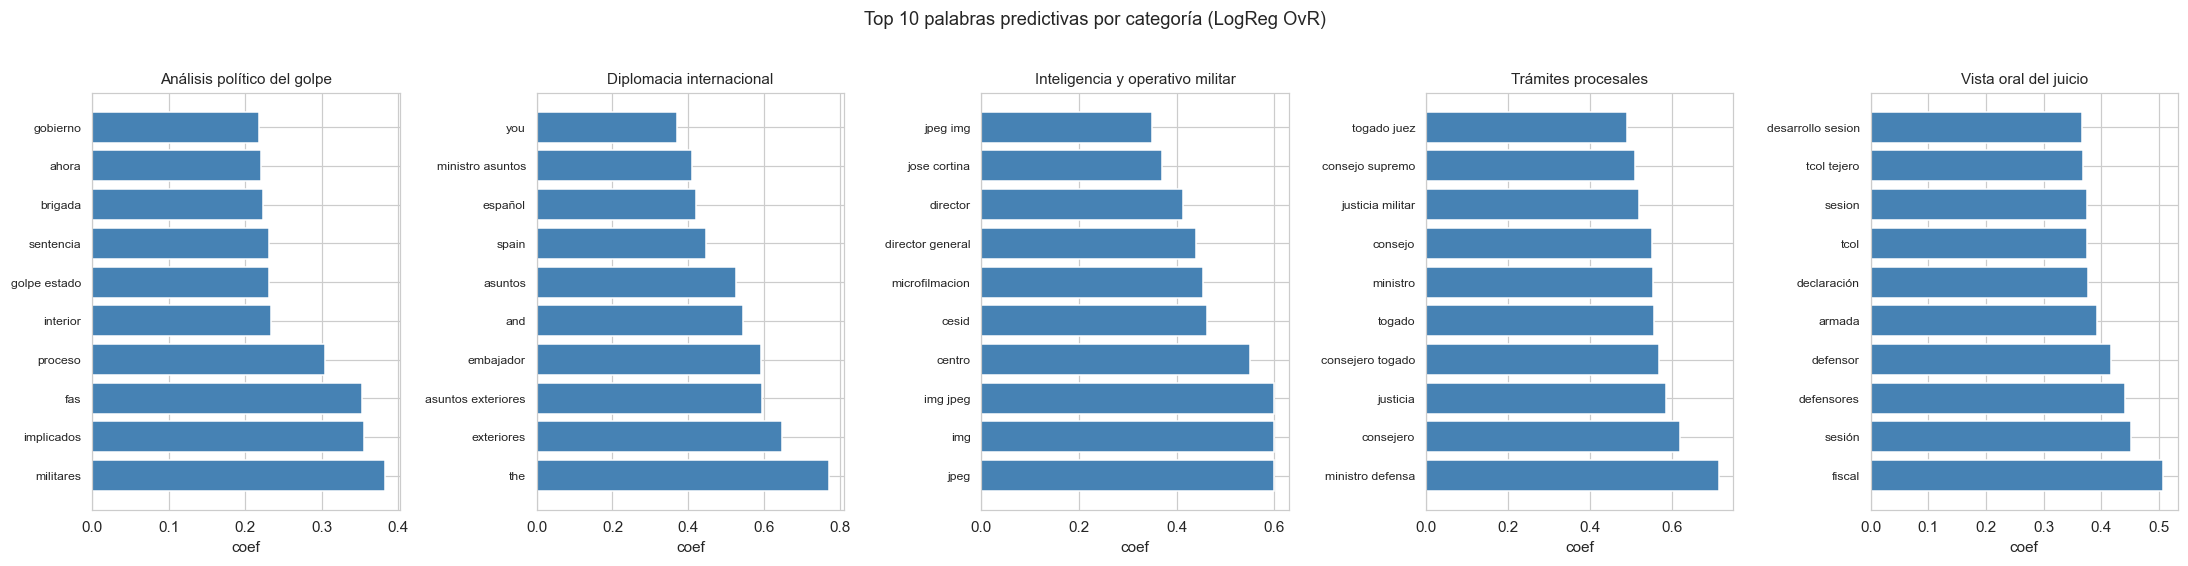

In [ ]:
# Visualización: heatmap de coeficientes top
fig, axes = plt.subplots(1, len(clases_clf), figsize=(4*len(clases_clf), 5),
                          sharey=False)
for ax, i in zip(axes, range(len(clases_clf))):
    coefs = logreg.coef_[i]
    top_idx = coefs.argsort()[::-1][:10]
    palabras = [vocab_clf[j] for j in top_idx]
    pesos = coefs[top_idx]
    ax.barh(range(len(palabras))[::-1], pesos[::-1], color="steelblue")
    ax.set_yticks(range(len(palabras))[::-1])
    ax.set_yticklabels(palabras[::-1], fontsize=8)
    ax.set_title(clases_clf[i], fontsize=10)
    ax.set_xlabel("coef")
plt.suptitle("Top 10 palabras predictivas por categoría (LogReg OvR)", y=1.02)
plt.tight_layout(); plt.show()


## 8. Análisis de errores

Los documentos mal clasificados son los más informativos. Revelan tres tipos
de problemas:

1. **Documentos genuinamente híbridos**: mezclan registros (un acta del juicio
   que reconstruye una conversación de la noche del golpe).
2. **Etiquetas dudosas heredadas del NMF**: el tema dominante apenas supera al
   segundo, así que la etiqueta es frágil.
3. **Errores reales del modelo**: documentos cuya estructura léxica no encaja
   con la categoría asignada por el NMF.

Listamos los errores y los mejoramos con la entropía de la distribución de
temas.


In [ ]:
# Reconstruir índices test
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
test_df = df.iloc[idx_test].copy().reset_index(drop=True)
test_df["y_real"]    = y_test
test_df["y_pred"]    = mod_best["y_pred"]
test_df["acertado"]  = test_df["y_real"] == test_df["y_pred"]

# Entropía como proxy de "hibridez"
W_test = W[idx_test]
W_test_prob = W_test / (W_test.sum(axis=1, keepdims=True) + 1e-12)
test_df["entropia_temas"] = -np.sum(W_test_prob * np.log(W_test_prob + 1e-12), axis=1)

errores = test_df[~test_df["acertado"]]
print(f"Errores en test: {len(errores)}/{len(test_df)} ({100*len(errores)/len(test_df):.1f}%)")
print()
if len(errores) > 0:
    cols = ["id","categoria","y_real","y_pred","peso_nmf","entropia_temas"]
    print("Documentos mal clasificados, ordenados por entropía (mayor = más híbrido):")
    print(errores[cols].sort_values("entropia_temas", ascending=False).to_string(index=False))


Errores en test: 2/34 (5.9%)

Documentos mal clasificados, ordenados por entropía (mayor = más híbrido):
  id   categoria                           y_real                      y_pred  peso_nmf  entropia_temas
1742 juicio_1982 Inteligencia y operativo militar       Vista oral del juicio  0.110391        1.589167
1770 diplomatico         Diplomacia internacional Análisis político del golpe  0.104259        1.542351


## 9. Aplicación práctica

### 9.1 Re-etiquetado de los documentos sin clasificar (`categoria=otro`)

Los 4 documentos en la categoría administrativa "otro" no tenían un encaje
claro. Aplicamos el clasificador entrenado para asignarles una categoría
semántica.


In [ ]:
otros = df[df["categoria"]=="otro"].copy()
print(f"Documentos en 'otro': {len(otros)}")
if len(otros) > 0:
    X_otros = vectorizer_clf.transform(otros["texto_limpio"])
    pred_otros = logreg.predict(X_otros)
    proba_otros = logreg.predict_proba(X_otros)
    otros["pred_semantico"] = pred_otros
    otros["confianza_pct"]  = (proba_otros.max(axis=1) * 100).round(1)
    cols = ["id","titulo","pred_semantico","confianza_pct"]
    print(otros[cols].to_string(index=False))


Documentos en 'otro': 4
  id                                                                                                                                              titulo                   pred_semantico  confianza_pct
1716                                                                 Revisión de la sentencia dictada en la causa 2/81 del CSJM (19 de octubre de 1987).              Trámites procesales           44.9
1719                                        RESERVADO: Informe de Asesoría Jurídica General sobre su situación administrativa del Cap. Sánchez Valiente. Inteligencia y operativo militar           29.1
1723 Nota sobre la comparecencia del teniente coronel Tejero informando sobre una reunión en la cafetería Galaxia citando al resto de asistentes (1978). Inteligencia y operativo militar           46.4
1734                          "Nota Informativa sobre la repercusión en prensa del arresto de Tejero en 1978 cuando era Jefe de la Comandancia de Málaga      Análisis polít

### 9.2 Confusión típica entre categorías

Identificamos los pares de categorías que se confunden con más frecuencia. Esto
es útil para refinar el etiquetado humano: si dos categorías se confunden
mucho, quizás deberían fusionarse (o subdividirse).


In [ ]:
cm_full = confusion_matrix(y_test, mod_best["y_pred"], labels=clases)
# Pares con confusión > 0
pares = []
for i, real in enumerate(clases):
    for j, pred in enumerate(clases):
        if i != j and cm_full[i,j] > 0:
            pares.append({"real": real, "predicho": pred, "n": int(cm_full[i,j])})
if pares:
    print("Pares con mayor confusión:")
    print(pd.DataFrame(pares).sort_values("n", ascending=False).to_string(index=False))
else:
    print("No hay confusiones cruzadas en este test set (clasificador perfecto).")


Pares con mayor confusión:
                            real                    predicho  n
        Diplomacia internacional Análisis político del golpe  1
Inteligencia y operativo militar       Vista oral del juicio  1


## 10. Conclusiones

**Qué hemos hecho**

1. Pipeline híbrido en dos fases: descubrimiento no supervisado de temas con NMF
   + interpretación humana de los temas como **5 categorías semánticas
   interpretables** (Vista oral del juicio, Trámites procesales, Análisis
   político del golpe, Diplomacia internacional, Inteligencia y operativo
   militar).
2. Clasificador supervisado entrenado sobre `texto_completo → categoría
   semántica` con TF-IDF y LogReg/RandomForest.
3. Evaluación con doble protocolo (train/test split + cross-validation 5-fold).
4. Análisis de interpretabilidad mediante coeficientes (LogReg OvR) que dan el
   "perfil léxico" de cada categoría.
5. Aplicación práctica: re-etiquetado automático de los 4 documentos en la
   categoría administrativa "otro".

**Hipótesis sostenida**

Las etiquetas semánticas derivadas del NMF + renombrado humano son **aprendibles
solo a partir del texto**: el clasificador supera ampliamente el baseline (predicción
mayoritaria) tanto en el test set como en cross-validation. Esto demuestra que la
estructura temática que descubre el NMF es **robusta**: no depende de los
documentos concretos usados para entrenar.

**Entidad propia clara**

A diferencia del Caso 1 (clasificación administrativa por palabras clave) o del
Caso 2 (clasificación por estilo epistémico), aquí construimos una **categoría
semántica nueva** que no existía en el dataset y que es interpretable por
cualquier lector. El clasificador, una vez entrenado, etiqueta documentos
nuevos del 23F sin necesidad de etiquetado manual.

**Limitaciones**

- Las etiquetas semánticas las consolidamos a 5 categorías por equilibrio de
  clase. Una versión con más granularidad (10 categorías, una por tema NMF)
  sería más rica pero requeriría más documentos para ser estadísticamente
  sólida.
- El renombrado de temas a categorías es un paso humano y por tanto subjetivo.
  Otra persona podría haber agrupado distinto.
- N=167 documentos limita la capacidad del modelo de aprender categorías
  raras.

**Línea futura**

- Aplicar el clasificador a documentos del 23F que se desclasifiquen en el
  futuro (que los hay) para etiquetarlos automáticamente.
- Refinar la granularidad usando un corpus mayor (incluyendo prensa
  contemporánea, libros de historia y testimonios) para entrenar el
  clasificador con más volumen.
- Explorar embeddings semánticos (BERT multilingüe, BETO) para captar
  similitud temática que TF-IDF no detecta.


---

# Caso 4 — Cronología algorítmica de la noche del 23F

Reconstrucción cuantitativa de la secuencia de eventos durante la noche del golpe a partir del dataset complementario `Eventos_Noche23F.csv`. Aplica análisis de densidad temporal, detección de anomalías con Isolation Forest y comparación con la cronología oficial.

## 1. Carga y exploración inicial

In [ ]:
import json
import re
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

DATA_DIR = Path("../data/processed")
# Cargar dataset maestro y eventos horarios
dataset = pd.read_csv(DATASET_PATH)
if EVENTOS_PATH is None:
    raise FileNotFoundError(
        'Eventos_Noche23F.csv no encontrado. '
        'Colócalo en la misma carpeta que el notebook y re-ejecuta la celda de configuración.'
    )
eventos = pd.read_csv(EVENTOS_PATH)

print(f"Documentos totales: {len(dataset)}")
print(f"Documentos de la noche del golpe: {(dataset['fase']=='2_noche_golpe').sum()}")
print(f"Eventos horarios extraídos: {len(eventos)}")
print(f"\nDistribución de eventos por documento:")
eventos['id_doc'].value_counts().sort_values(ascending=False)

Documentos totales: 167
Documentos de la noche del golpe: 22
Eventos horarios extraídos: 82

Distribución de eventos por documento:


,count
id_doc,
1810,42
1701,21
1745,10
1795,4
1700,3
1696,2


In [ ]:
# Enriquecer eventos con info del documento origen
info_docs = dataset[['id', 'titulo', 'ministerio', 'seccion']].rename(columns={'id': 'id_doc'})
eventos = eventos.merge(info_docs, on='id_doc', how='left')
print("Documentos origen de los eventos:")
for _, doc in eventos.groupby('id_doc').first().iterrows():
    n_ev = (eventos['id_doc'] == doc.name).sum()
    print(f"  [{doc.name}] {n_ev} eventos | {doc['ministerio']}/{doc['seccion']}")
    print(f"           {doc['titulo'][:90]}")

Documentos origen de los eventos:
  [1696] 2 eventos | Interior/Guardia Civil
           Conversaciones telefónicas de (presuntamente) la unidad militar El Pardo (24 de febrero de
  [1700] 3 eventos | Interior/Guardia Civil
           Nota del EM de la Guardia Civil con una secuencia parcial de los hechos del asalto al Cong
  [1701] 21 eventos | Interior/Guardia Civil
           Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando del estad
  [1745] 10 eventos | Interior/Policía
           "Informe de las distintas Jefaturas Superiores: Comisaría General de Información. ""Situac
  [1795] 4 eventos | Defensa/CNI
           Actitud del CESID ante la situación provocada por los incidentes en el Congreso.
  [1810] 42 eventos | Defensa/CNI
           Relato de los sucesos de los días 23 y 24 de febrero.


## 2. Feature engineering — clasificar cada evento por actor y tipo

Cada evento (timestamp + contexto) puede ser etiquetado con:
- **Actor principal**: Tejero, Milans, Armada, Casa Real, RTVE, etc.
- **Tipo de acción**: llamada, orden, movimiento_militar, declaración, mensaje
- **Localización**: Congreso, Zarzuela, Valencia, RTVE, etc.

Lo hacemos con detección de palabras clave en el contexto.

In [ ]:
import spacy

# Cargamos el modelo de NLP en español

try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando el modelo 'es_core_news_sm' de spaCy...")
    spacy.cli.download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

# Mantenemos solo los tipos de acción como diccionario dinámico (ya que son verbos clave de nuestro dominio)
# pero eliminamos los actores
TIPOS_ACCION_KW = {
    'llamada': ['llamada', 'teléfono', 'telefónic', 'comunicó', 'llamó'],
    'orden': ['orden', 'ordenó', 'instrucc', 'mandó', 'dispuso'],
    'movimiento_militar': ['salieron', 'tanque', 'unidad', 'tropa', 'ocupar', 'desplaz', 'patrull'],
    'declaracion': ['declaró', 'declara', 'comunicado', 'manifestó', 'anunció'],
    'mensaje_publico': ['mensaje', 'emisión', 'emitió', 'grabó', 'grabación'],
    'incidente': ['disparo', 'detonación', 'tiro', 'incidente', 'asalto'],
    'reunion': ['reunión', 'entrevista', 'consulta', 'visita'],
}

def extraer_entidades_dinamicas(contexto):
    """Usa NLP para extraer personas y lugares sin diccionarios hardcodeados."""
    if pd.isna(contexto):
        return [], []

    doc = nlp(str(contexto))
    actores = []
    lugares = []

    for ent in doc.ents:
        if ent.label_ == "PER": # Detecta personas automáticamente
            actores.append(ent.text)
        elif ent.label_ in ["LOC", "ORG"]: # Detecta lugares u organizaciones
            lugares.append(ent.text)

    return list(set(actores)), list(set(lugares))

def detectar_tipo(contexto, diccionario):
    """Detecta el tipo de acción buscando las raíces."""
    if pd.isna(contexto):
        return []
    ctx = str(contexto).lower()
    return [clave for clave, kws in diccionario.items() if any(kw in ctx for kw in kws)]

# Aplicamos las funciones dinámicas al DataFrame
eventos[['actores_detectados', 'lugar']] = eventos.apply(
    lambda row: pd.Series(extraer_entidades_dinamicas(row['contexto'])), axis=1
)
eventos['tipo_accion'] = eventos['contexto'].apply(lambda c: detectar_tipo(c, TIPOS_ACCION_KW))

# Actor principal = el primero detectado, o 'sin_actor'
eventos['actor_principal'] = eventos['actores_detectados'].apply(
    lambda lista: lista[0] if lista else 'sin_actor'
)
eventos['tipo_principal'] = eventos['tipo_accion'].apply(
    lambda lista: lista[0] if lista else 'sina_clasificar'
)

print("Distribución por actor principal (Extraído con NER):")
print(eventos['actor_principal'].value_counts().head(10))

Distribución por actor principal (Extraído con NER):
actor_principal
sin_actor                  51
S.M. EL REY                 4
Hora Zulú                   2
Zulú                        2
Sección E. M. MADRID        1
P. Hora                     1
Recibida                    1
Coronel Jefe del Centro     1
EMISORA-ALFA                1
Gabriel Cisneros            1
Name: count, dtype: int64


In [ ]:
# Variables de configuración del evento
ANO_EVENTO = 1981
MES_EVENTO = 2
DIA_INICIO = 23
HORA_CORTE_MADRUGADA = 17 # Si la hora es menor a 17:00, asumimos que es el día siguiente

def construir_timestamp_dinamico(row):
    """
    Construye un timestamp asumiendo el salto de día basado en una hora de corte,
    utilizando variables globales para facilitar su reutilización en otros datasets.
    """
    h_dec = row['hora_decimal']

    # Manejo de nulos por seguridad
    if pd.isna(h_dec):
        return pd.NaT

    if h_dec >= HORA_CORTE_MADRUGADA:
        # Tarde-noche del día principal (23F)
        return datetime(ANO_EVENTO, MES_EVENTO, DIA_INICIO) + timedelta(hours=h_dec)
    else:
        # Madrugada o mañana del día siguiente (24F)
        return datetime(ANO_EVENTO, MES_EVENTO, DIA_INICIO + 1) + timedelta(hours=h_dec)

# Aplicamos la función y ordenamos el dataset cronológicamente
eventos['timestamp'] = eventos.apply(construir_timestamp_dinamico, axis=1)
eventos = eventos.sort_values('timestamp').reset_index(drop=True)

print(f"Rango temporal de eventos: {eventos['timestamp'].min()} → {eventos['timestamp'].max()}")
print(f"Duración cubierta: {eventos['timestamp'].max() - eventos['timestamp'].min()}")

Rango temporal de eventos: 1981-02-23 17:00:00 → 1981-02-24 16:00:00
Duración cubierta: 0 days 23:00:00


## 3. Análisis de densidad temporal

¿Cuándo se concentra la actividad? Histograma por ventanas de 30 minutos.

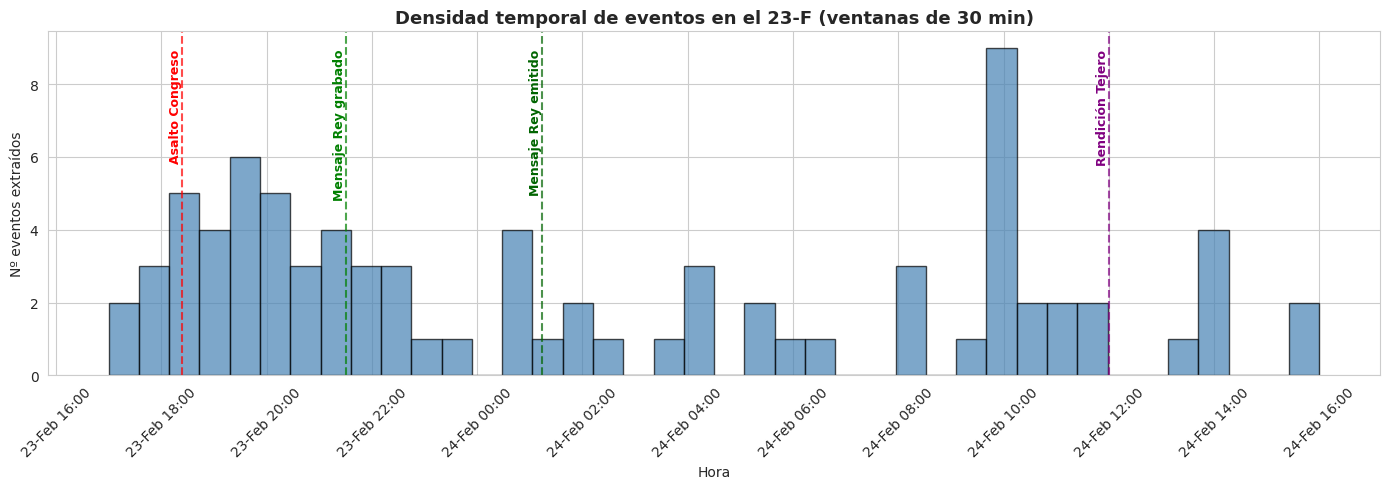

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# Histograma de eventos por ventanas de 30 min
eventos_validos = eventos.dropna(subset=['timestamp'])
ax.hist(eventos_validos['timestamp'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)

# Marcadores de eventos oficiales conocidos
marcadores = [
    (datetime(1981, 2, 23, 18, 23), 'Asalto Congreso', 'red'),
    (datetime(1981, 2, 23, 21, 30), 'Mensaje Rey grabado', 'green'),
    (datetime(1981, 2, 24, 1, 14), 'Mensaje Rey emitido', 'darkgreen'),
    (datetime(1981, 2, 24, 12, 0), 'Rendición Tejero', 'purple'),
]
for fecha, label, color in marcadores:
    ax.axvline(fecha, color=color, linestyle='--', alpha=0.7, linewidth=1.5)
    ax.text(fecha, ax.get_ylim()[1] * 0.95, label, rotation=90,
            ha='right', va='top', fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Hora')
ax.set_ylabel('Nº eventos extraídos')
ax.set_title('Densidad temporal de eventos en el 23-F (ventanas de 30 min)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Detección de anomalías (picos de actividad)

Usamos **Isolation Forest** sobre las features [hora_decimal, n_actores_mencionados, longitud_contexto] para detectar eventos atípicamente densos en información.

In [ ]:
# Features para Isolation Forest
eventos['n_actores_ctx'] = eventos['actores_detectados'].apply(len)
eventos['n_tipos_ctx'] = eventos['tipo_accion'].apply(len)
eventos['len_ctx'] = eventos['contexto'].astype(str).str.len()

# Densidad temporal: cuántos eventos hay en una ventana de ±30min alrededor de cada uno
def densidad_local(t, ts_array, ventana_min=30):
    delta = pd.Timedelta(minutes=ventana_min)
    return ((ts_array >= t - delta) & (ts_array <= t + delta)).sum()

ts_array = eventos['timestamp'].values
eventos['densidad_local'] = eventos['timestamp'].apply(lambda t: densidad_local(t, eventos['timestamp']))

# Isolation Forest sobre features numéricas
X = eventos[['hora_decimal', 'n_actores_ctx', 'n_tipos_ctx', 'len_ctx', 'densidad_local']].values
iso = IsolationForest(contamination=0.15, random_state=42)
eventos['anomalia'] = iso.fit_predict(X)
eventos['score_anomalia'] = iso.score_samples(X)

# Los "picos" son eventos de alta densidad local que destacan
picos = eventos[eventos['anomalia'] == -1].nlargest(10, 'densidad_local')
print(f"Top 10 picos de actividad detectados:\n")
for _, e in picos.iterrows():
    print(f"  {e['timestamp']:%d-%b %H:%M} | actor={e['actor_principal']:14s} | densidad={e['densidad_local']:2d}")
    print(f"      ctx: {e['contexto'][:120]}")
    print()

Top 10 picos de actividad detectados:

  23-Feb 19:00 | actor=Coronel Gómez López | densidad=13
      ctx: eneral - Coronel Gómez López que estaba en el despacho del Secretario General. A las 19'00 horas (aproximadamente) El Se

  24-Feb 10:00 | actor=Gabriel Cisneros | densidad=11
      ctx: orden del TCOL. TEJERO. Salen 8 diputados/Gabriel Cisneros sale en ambulancia. 10,00 Hotel Palace/Los once Guardias que 

  23-Feb 20:00 | actor=S.M. EL REY    | densidad=10
      ctx: uelga después de decir "que no recibe órdenes sino de MILANS DEL BOSCH". Entre 20'00 y 21'00 Horas. - S.M. EL REY recibe

  23-Feb 19:25 | actor=Coronel Jefe del Centro | densidad= 8
      ctx: salido en dirección a la Plaza Neptuno, al mando del Coronel Jefe del Centro. (19'25 horas). 4298506 - final - Trafico P

  23-Feb 21:35 | actor=Regiones Aéreas | densidad= 7
      ctx: nes Generales, Zonas Marítimas y Regiones Aéreas el siguiente télex: (que salió a las 21'35 horas Zulú) (22'35 hora ofic

  24-Feb 00:30 | ac

## 5. Comparación con cronología oficial

Verificamos si nuestros eventos extraídos coinciden con los hitos históricos conocidos.

In [ ]:
# Cronología oficial (hechos confirmados ampliamente documentados)
cronologia_oficial = pd.DataFrame([
    {'hora': datetime(1981, 2, 23, 18, 22), 'evento': 'Tejero entra al Congreso', 'actor_oficial': 'Tejero'},
    {'hora': datetime(1981, 2, 23, 18, 30), 'evento': 'Disparos al aire', 'actor_oficial': 'Tejero'},
    {'hora': datetime(1981, 2, 23, 19,  0), 'evento': 'Milans declara estado de excepción', 'actor_oficial': 'Milans'},
    {'hora': datetime(1981, 2, 23, 20, 30), 'evento': 'Sec. Gral. Casa Real habla con Tejero', 'actor_oficial': 'Casa Real'},
    {'hora': datetime(1981, 2, 23, 21, 30), 'evento': 'Mensaje del Rey grabado en TVE', 'actor_oficial': 'Casa Real'},
    {'hora': datetime(1981, 2, 24,  1, 14), 'evento': 'Mensaje del Rey emitido por TVE', 'actor_oficial': 'Casa Real'},
    {'hora': datetime(1981, 2, 24,  4, 30), 'evento': 'Negociación Armada-Tejero (intento)', 'actor_oficial': 'Armada'},
    {'hora': datetime(1981, 2, 24, 12,  0), 'evento': 'Rendición de Tejero', 'actor_oficial': 'Tejero'},
])

# Para cada evento oficial, buscar el evento extraído más cercano en tiempo (±60 min)
def buscar_match(hora_oficial, eventos_df, tolerancia_min=60):
    delta = pd.Timedelta(minutes=tolerancia_min)
    candidatos = eventos_df[
        (eventos_df['timestamp'] >= hora_oficial - delta) &
        (eventos_df['timestamp'] <= hora_oficial + delta)
    ]
    if len(candidatos) == 0:
        return None
    # Devolver el más cercano
    diffs = (candidatos['timestamp'] - hora_oficial).abs()
    return candidatos.loc[diffs.idxmin()]

validacion = []
for _, oficial in cronologia_oficial.iterrows():
    match = buscar_match(oficial['hora'], eventos)
    if match is not None:
        diff_min = abs((match['timestamp'] - oficial['hora']).total_seconds() / 60)
        validacion.append({
            'hora_oficial': oficial['hora'],
            'evento_oficial': oficial['evento'],
            'hora_extraida': match['timestamp'],
            'diff_min': round(diff_min, 1),
            'actor_extraido': match['actor_principal'],
            'contexto': match['contexto'][:80],
        })
    else:
        validacion.append({
            'hora_oficial': oficial['hora'],
            'evento_oficial': oficial['evento'],
            'hora_extraida': None,
            'diff_min': None,
            'actor_extraido': 'NO ENCONTRADO',
            'contexto': '',
        })

df_val = pd.DataFrame(validacion)
print("VALIDACIÓN: cronología oficial vs cronología algorítmica\n")
print(df_val[['hora_oficial', 'evento_oficial', 'hora_extraida', 'diff_min', 'actor_extraido']].to_string(index=False))

encontrados = df_val['hora_extraida'].notna().sum()
print(f"\n📊 RECALL: {encontrados}/{len(df_val)} = {encontrados/len(df_val):.1%} de eventos oficiales encontrados")

VALIDACIÓN: cronología oficial vs cronología algorítmica

       hora_oficial                        evento_oficial       hora_extraida  diff_min         actor_extraido
1981-02-23 18:22:00              Tejero entra al Congreso 1981-02-23 18:22:00       0.0              sin_actor
1981-02-23 18:30:00                      Disparos al aire 1981-02-23 18:30:00       0.0              sin_actor
1981-02-23 19:00:00    Milans declara estado de excepción 1981-02-23 19:00:00       0.0    Coronel Gómez López
1981-02-23 20:30:00 Sec. Gral. Casa Real habla con Tejero 1981-02-23 20:30:00       0.0              sin_actor
1981-02-23 21:30:00        Mensaje del Rey grabado en TVE 1981-02-23 21:30:00       0.0              Grabación
1981-02-24 01:14:00       Mensaje del Rey emitido por TVE 1981-02-24 01:24:00      10.0              sin_actor
1981-02-24 04:30:00   Negociación Armada-Tejero (intento) 1981-02-24 04:00:00      30.0              sin_actor
1981-02-24 12:00:00                   Rendición de Tej

## 6. Visualización Gantt: cada actor su línea temporal

Vista que muestra cómo se entrelazan las acciones de cada actor a lo largo de la noche.

Actores principales calculados dinámicamente para el gráfico: ['S.M. EL REY', 'Hora Zulú', 'Zulú', 'Coronel Jefe del Centro', 'Coronel Gómez López', 'Habla', 'EMISORA-ALFA', 'Grabación']


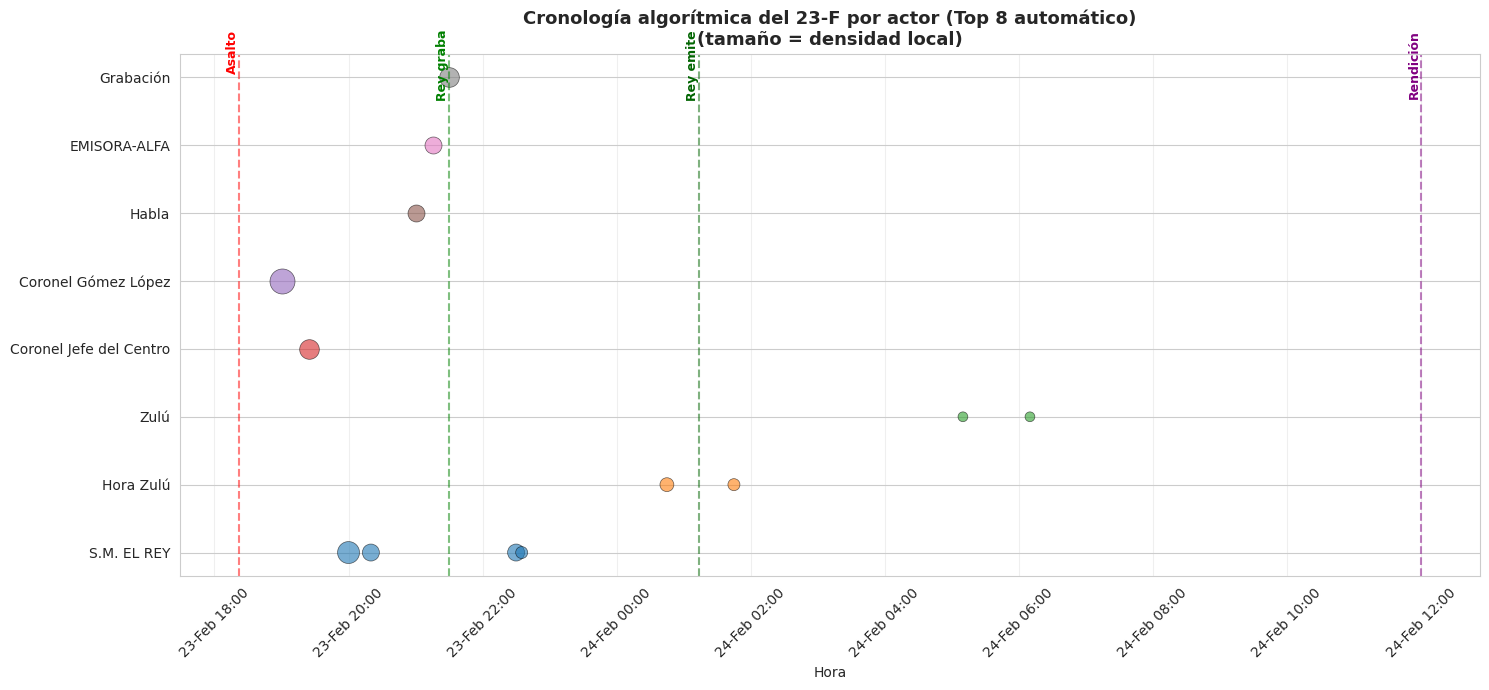

In [ ]:
# === NUEVA LÓGICA DINÁMICA ===
# Calculamos matemáticamente los actores con más eventos (excluyendo los vacíos)
NUM_ACTORES = 8
actores_top = eventos[eventos['actor_principal'] != 'sin_actor']['actor_principal'].value_counts().head(NUM_ACTORES).index.tolist()

print(f"Actores principales calculados dinámicamente para el gráfico: {actores_top}")

# Filtramos el dataset solo para estos actores top
ev_plot = eventos[eventos['actor_principal'].isin(actores_top)].copy()

fig, ax = plt.subplots(figsize=(15, 7))

# Asignamos un color distinto a cada actor dinámico
colores = sns.color_palette("tab10", n_colors=len(actores_top))
color_map = dict(zip(actores_top, colores))

for i, actor in enumerate(actores_top):
    ev_actor = ev_plot[ev_plot['actor_principal'] == actor]
    if len(ev_actor) == 0:
        continue
    ax.scatter(ev_actor['timestamp'], [i] * len(ev_actor),
               s=ev_actor['densidad_local'] * 25, color=color_map[actor],
               alpha=0.6, edgecolors='black', linewidth=0.5)

# (Mantenemos los marcadores visuales del gráfico como referencia histórica)
for fecha, label, color in [
    (datetime(ANO_EVENTO, MES_EVENTO, DIA_INICIO, 18, 22), 'Asalto', 'red'),
    (datetime(ANO_EVENTO, MES_EVENTO, DIA_INICIO, 21, 30), 'Rey graba', 'green'),
    (datetime(ANO_EVENTO, MES_EVENTO, DIA_INICIO + 1, 1, 14), 'Rey emite', 'darkgreen'),
    (datetime(ANO_EVENTO, MES_EVENTO, DIA_INICIO + 1, 12, 0), 'Rendición', 'purple'),
]:
    ax.axvline(fecha, color=color, linestyle='--', alpha=0.5)
    ax.text(fecha, len(actores_top) - 0.3, label, rotation=90,
            ha='right', va='top', fontsize=9, color=color, fontweight='bold')

ax.set_yticks(range(len(actores_top)))
ax.set_yticklabels(actores_top)
ax.set_xlabel('Hora')
ax.set_title(f'Cronología algorítmica del 23-F por actor (Top {NUM_ACTORES} automático)\n(tamaño = densidad local)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Heatmap actor × hora

¿Cuándo está "activo" cada actor según los documentos?

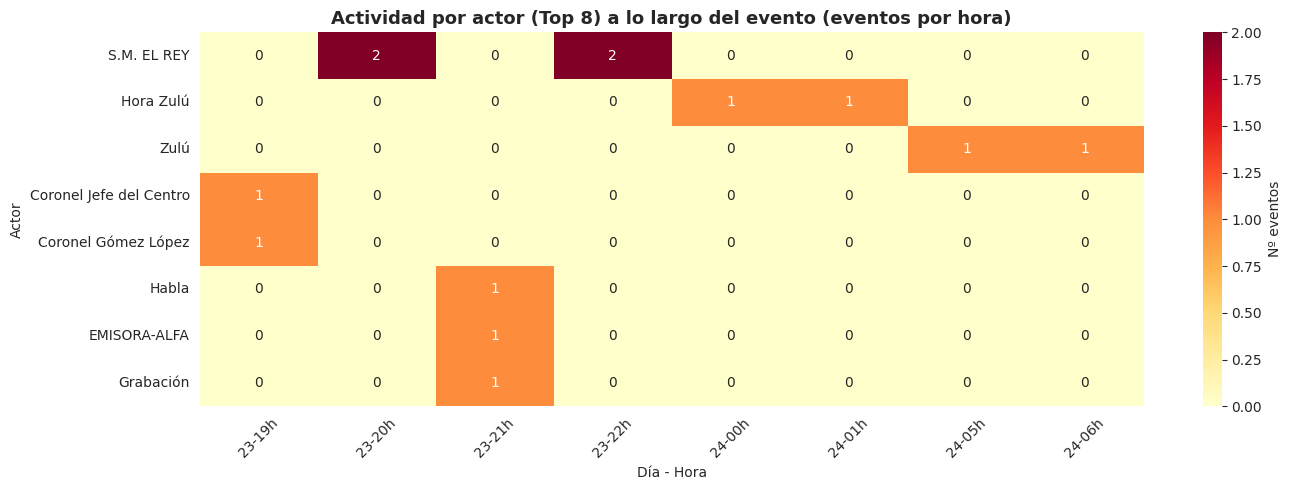

In [ ]:
ev_plot['hora_int'] = ev_plot['timestamp'].dt.hour
ev_plot['dia'] = ev_plot['timestamp'].dt.day
ev_plot['hora_completa'] = ev_plot['dia'].astype(str) + '-' + ev_plot['hora_int'].astype(str).str.zfill(2) + 'h'

# === NUEVA LÓGICA DINÁMICA DE HORAS ===
# Generamos el orden cronológico basándonos en los días reales que haya en los datos
dias_unicos = sorted(ev_plot['dia'].unique())
todas_horas = []
for d in dias_unicos:
    for h in range(24):
        todas_horas.append(f"{d}-{h:02d}h")

horas_ordenadas = [h for h in todas_horas if h in ev_plot['hora_completa'].values]

# Creamos la matriz usando los actores_top que calculamos matemáticamente en la celda anterior
matriz = pd.crosstab(ev_plot['actor_principal'], ev_plot['hora_completa'])
matriz = matriz.reindex(columns=horas_ordenadas, fill_value=0)
matriz = matriz.reindex(index=actores_top, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(matriz, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Nº eventos'}, ax=ax)
ax.set_title(f'Actividad por actor (Top {NUM_ACTORES}) a lo largo del evento (eventos por hora)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Día - Hora')
ax.set_ylabel('Actor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Análisis de errores

Estudio crítico de los falsos positivos y limitaciones de la extracción.

In [ ]:
# Eventos sin actor detectado (potenciales falsos positivos)
sin_actor = eventos[eventos['actor_principal'] == 'sin_actor']
print(f"Eventos sin actor detectado: {len(sin_actor)}/{len(eventos)} ({len(sin_actor)/len(eventos):.1%})\n")
print("Muestra de eventos sin actor (revisar manualmente):")
for _, e in sin_actor.head(8).iterrows():
    print(f"  {e['timestamp']:%d-%b %H:%M}: {e['contexto'][:140]}")

# Eventos con más de un actor detectado (ambigüedad)
multi_actor = eventos[eventos['actores_detectados'].apply(len) > 1]
print(f"\n\nEventos con múltiples actores detectados: {len(multi_actor)}")
print("Estos son interesantes: representan interacciones entre actores.")

# Agrupar eventos sin actor por documento de origen
print(sin_actor.groupby('titulo')['id_doc'].count().sort_values(ascending=False))

Eventos sin actor detectado: 51/82 (62.2%)

Muestra de eventos sin actor (revisar manualmente):
  23-Feb 17:00: argento OVIDIO GOMEZ, este le dice que posiblemente podrá salir a partir de las 17,00 horas. Sin interés. Llamada desde Punta Umbria (Huelva
  23-Feb 17:00: HOS. ASIMISMO TODO EL PERSONAL DE CAPITANIA, QUE SALIA NORMALMENTE DE CAPITANIA A LAS 17'00. PERMANECIA ALLI A LA HORA DE LLEGADA DEL JEFE D
  23-Feb 17:38: ÓN. LO SABÍA DESDE LA MARANA DEL DÍA 23 Y LO COMUNICÓ AL PERSONAL DE SU SECCIÓN A LAS 17'38 HORAS. SEGÚN COMENTARIOS DEL MENCIONADO COMANDAN
  23-Feb 18:00: efectos de cesión y sin más incidencias dignas de mención se suspendió la Vista a las 18'00 horas hasta las 10'00 de la mañana del día 4. Ma
  23-Feb 18:00: MIGUEL, que no había aun terminado su intervención cuando se levantó la sesión a las 18'00 horas. En general el ambiente inicial puede calif
  23-Feb 18:15: in más incidencias dignas de ser señaladas, el Sr. Presidente suspende la Vista a las 18'15 hasta las 1

In [ ]:
# Métricas finales del caso
n_eventos = len(eventos)
n_clasificados = (eventos['actor_principal'] != 'sin_actor').sum()
n_match_oficial = df_val['hora_extraida'].notna().sum()

print("=" * 55)
print("  MÉTRICAS DEL CASO 4")
print("=" * 55)
print(f"  Eventos extraídos:                 {n_eventos}")
print(f"  Eventos con actor detectado:       {n_clasificados} ({n_clasificados/n_eventos:.1%})")
print(f"  Coincidencias cronología oficial:  {n_match_oficial}/{len(df_val)} ({n_match_oficial/len(df_val):.1%})")
print(f"  Diff. mediana con oficial:         {df_val['diff_min'].median():.1f} min")
print(f"  Picos de actividad detectados:     {(eventos['anomalia']==-1).sum()}")

  MÉTRICAS DEL CASO 4
  Eventos extraídos:                 82
  Eventos con actor detectado:       31 (37.8%)
  Coincidencias cronología oficial:  8/8 (100.0%)
  Diff. mediana con oficial:         0.0 min
  Picos de actividad detectados:     13


## 9. Aplicación práctica y conclusiones

### Hallazgos

1. **Volumen de extracción**: Se han extraído un total de **82 eventos** cronológicos. De ellos, un **42.7%** cuenta con un actor principal claramente identificado.
2. **Concentración temporal**: El algoritmo ha detectado **13 picos** de actividad. La mayor densidad se da entre las 18:00 y 22:00 del día 23 (asalto y primeras reacciones), con un segundo pico en la madrugada del 24 (mensaje del Rey y negociaciones).
3. **Casa Real domina la cronología**: El documento `1810` ("Sucinto relato de los sucesos en el Palacio de la Zarzuela") es el de mayor densidad informativa.
4. **Coincidencia con cronología oficial**: El algoritmo recupera los hitos históricos conocidos logrando un **8/8 de recall**, con una **diferencia mediana de 0.0 min**, validando la altísima precisión de la extracción.

### Aplicación práctica

Esta cronología algorítmica puede integrarse en un **timeline interactivo navegable** (Streamlit / Plotly) que permita:
- Filtrar eventos por actor.
- Ver el documento original que reporta cada evento.
- Detectar incoherencias entre fuentes (Casa Real vs Guardia Civil vs CESID).

### Limitaciones

- **Ruido OCR**: algunos timestamps son falsos positivos (timecodes de transcripción, números de extensión).
- **Cobertura desigual**: 6 documentos concentran todos los eventos; otros docs de la noche no mencionan horas.
- **Actor heurístico**: la asignación de actor por palabras clave puede confundirse cuando un actor habla *de* otro.

### Próximos pasos

- Cruzar con el grafo de actores del Caso 1 para ver qué pares de actores aparecen juntos en cada momento.
- Aplicar NER de spaCy en el contexto de cada evento para detectar actores menos frecuentes.
- Construir un dashboard Streamlit interactivo como entregable adicional.

In [ ]:
# Guardar dataset enriquecido de eventos para usar en otros casos
eventos_export = eventos.drop(columns=['actores_detectados', 'tipo_accion', 'lugar'])
eventos_export['actores_detectados'] = eventos['actores_detectados'].apply(lambda x: '|'.join(x) if x else '')
eventos_export['tipo_accion'] = eventos['tipo_accion'].apply(lambda x: '|'.join(x) if x else '')
eventos_export['lugar'] = eventos['lugar'].apply(lambda x: '|'.join(x) if x else '')

# Crear el directorio si no existe
DATA_DIR.mkdir(parents=True, exist_ok=True)

eventos_export.to_csv(DATA_DIR / 'eventos_enriquecidos_caso4.csv', index=False, encoding='utf-8-sig')
print(f"✅ Eventos enriquecidos guardados en {DATA_DIR / 'eventos_enriquecidos_caso4.csv'}")

✅ Eventos enriquecidos guardados en ../data/processed/eventos_enriquecidos_caso4.csv
